# Ball Make Characteristics (Make/Miss Surfaces)

**Goal:** Model shot success (`Made`) using ball flight and depth/left-right location variables, then plot probability heatmaps.

This notebook builds a **non-linear classifier** for make/miss using:
- `left_right` (x-axis location)
- `Ball_Depth` (y-axis location)
- `Ball_Velocity`
- `Ball_to_Rim_Angle`

Main visualization:
- Surface heatmaps of **predicted make probability** over `left_right` (x-axis) vs `Ball_Depth` (y-axis)
- Faceted by low/medium/high levels of `Ball_Velocity` and `Ball_to_Rim_Angle`

## Section 1: Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import itertools
import math
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, brier_score_loss
from sklearn.model_selection import train_test_split

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

## Section 2: Load Data and Feature Engineering

In [2]:
DATA_PATH = '../capstone2026v2.csv'

# Candidate depth/location columns; first match in each list is used.
DEPTH_CANDIDATES = ['Ball_Depth', 'ball_depth', 'Depth', 'depth', 'Shot.Y.Pos', 'y', 'Y']
LEFT_RIGHT_COL = 'left_right'

df = pd.read_csv(DATA_PATH)

DEPTH_COL = next((c for c in DEPTH_CANDIDATES if c in df.columns), None)
if DEPTH_COL is None:
    raise ValueError('Could not find a depth column. Tried: ' + str(DEPTH_CANDIDATES))

required_base = [LEFT_RIGHT_COL, DEPTH_COL, 'Ball_to_Rim_Angle', 'Ball_Velocity', 'Made']
missing = [c for c in required_base if c not in df.columns]
if missing:
    raise ValueError('Missing required columns: ' + str(missing))

df_model = df[required_base].copy()
df_model['Made'] = df_model['Made'].astype(int)
df_model = df_model.rename(columns={DEPTH_COL: 'Ball_Depth'})

feature_cols = [
    'left_right',
    'Ball_Depth',
    'Ball_to_Rim_Angle',
    'Ball_Velocity',
]

df_model = df_model.dropna(subset=feature_cols + ['Made']).copy()

print('Using depth column:', DEPTH_COL)
print('Rows for modeling:', len(df_model))
print('Make rate:', round(df_model['Made'].mean(), 3))
df_model[feature_cols + ['Made']].describe().T

Using depth column: Ball_Depth
Rows for modeling: 25868
Make rate: 0.654


,count,mean,std,min,25%,50%,75%,max
left_right,25868.0,0.038211,3.780164,-88.02,-2.21000,0.140000,2.330000,32.300000
Ball_Depth,25868.0,8.935411,4.855157,-43.67,6.01373,9.020000,11.970000,78.360000
Ball_to_Rim_Angle,25868.0,45.192212,3.350256,0.00,43.33000,45.130000,47.010000,81.600000
Ball_Velocity,25868.0,4.175790,1.712000,0.00,1.76649,5.053005,5.532232,6.795946
Made,25868.0,0.653549,0.475848,0.00,0.00000,1.000000,1.000000,1.000000


## Section 3: Fit Non-Linear Make/Miss Model

In [3]:
X = df_model[feature_cols]
y = df_model['Made']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

clf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1,
)
clf.fit(X_train, y_train)

p_test = clf.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, p_test)
brier = brier_score_loss(y_test, p_test)

print('Test AUC  :', round(auc, 4))
print('Test Brier:', round(brier, 4))

fi = pd.Series(clf.feature_importances_, index=feature_cols).sort_values(ascending=False)
print('\nFeature importance:')
print(fi.round(4).to_string())

Test AUC  : 0.9607
Test Brier: 0.0725

Feature importance:
Ball_Depth           0.5304
left_right           0.3431
Ball_Velocity        0.0937
Ball_to_Rim_Angle    0.0328


## Section 4: Empirical Heatmap (Observed Make Rate)

Observed make rate in bins of `left_right` (x-axis) and `Ball_Depth` (y-axis), using all shots.

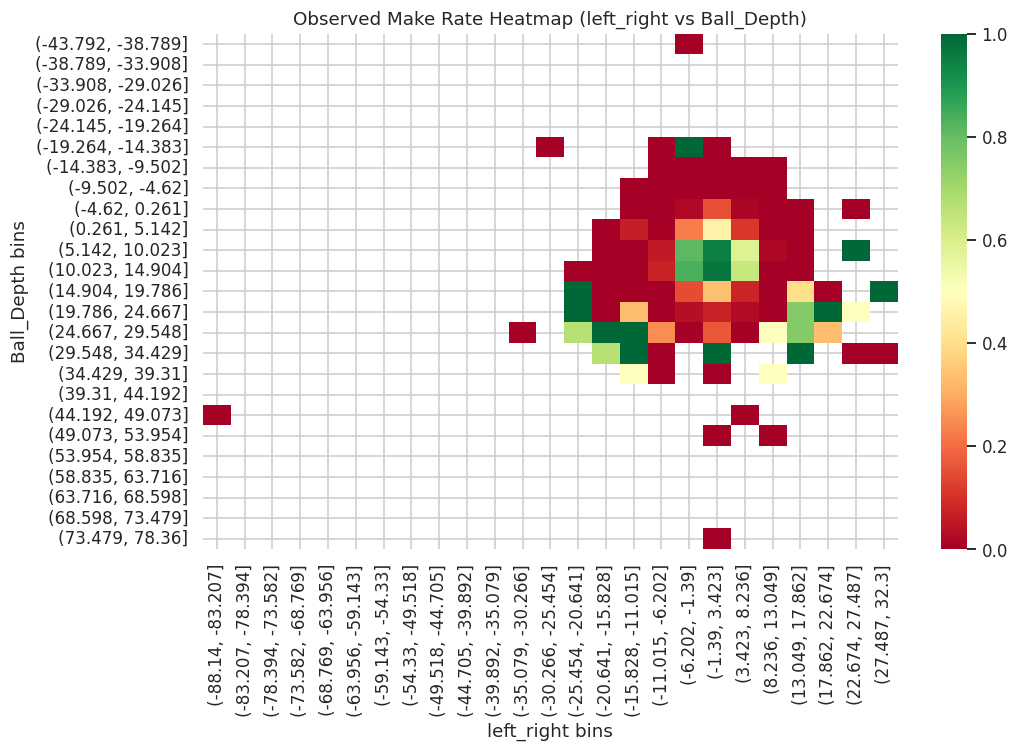

In [4]:
N_BINS = 25
tmp = df_model.copy()
tmp['lr_bin'] = pd.cut(tmp['left_right'], bins=N_BINS)
tmp['depth_bin'] = pd.cut(tmp['Ball_Depth'], bins=N_BINS)

emp = (tmp.groupby(['depth_bin', 'lr_bin'], observed=False)['Made']
         .mean()
         .unstack())

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(emp, cmap='RdYlGn', vmin=0, vmax=1, ax=ax)
ax.set_title('Observed Make Rate Heatmap (left_right vs Ball_Depth)')
ax.set_xlabel('left_right bins')
ax.set_ylabel('Ball_Depth bins')
plt.tight_layout()
plt.show()

## Section 5: Model-Based Surface Heatmaps

Surface heatmaps for predicted make probability over:
- x-axis: `left_right`
- y-axis: `Ball_Depth`

Conditioning variables are binned into low/medium/high:
- `Ball_Velocity`
- `Ball_to_Rim_Angle`

This yields 9 panels (3x3 grid: angle levels by velocity levels).

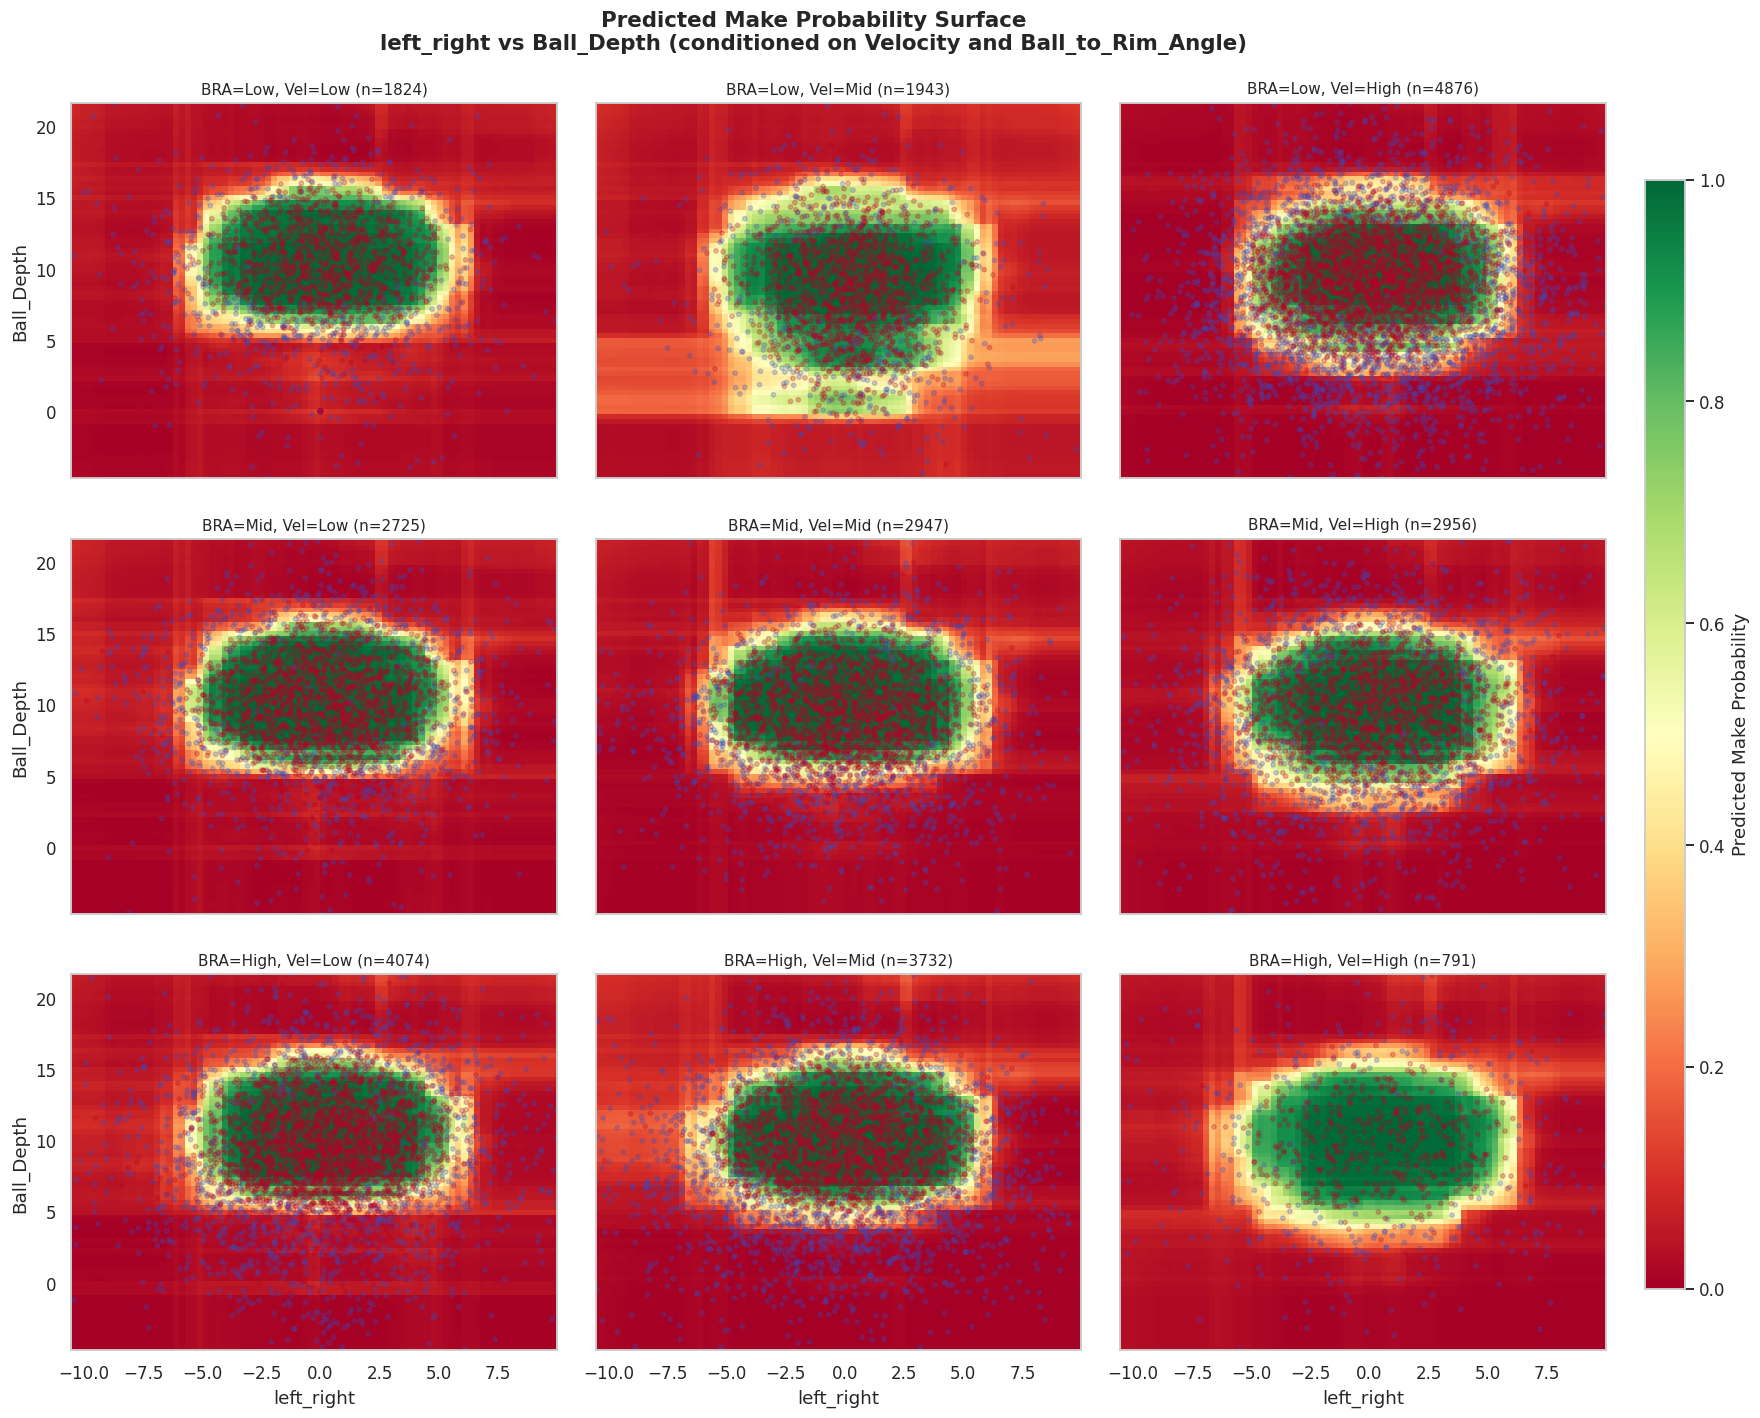

In [5]:
def tercile_cut(series, labels=('Low', 'Mid', 'High')):
    # qcut can fail if too many duplicate values; rank fallback makes bins robust.
    try:
        return pd.qcut(series, q=3, labels=labels, duplicates='drop')
    except ValueError:
        return pd.qcut(series.rank(method='first'), q=3, labels=labels, duplicates='drop')

plot_df = df_model.copy()
plot_df['vel_bin'] = tercile_cut(plot_df['Ball_Velocity'])
plot_df['bra_bin'] = tercile_cut(plot_df['Ball_to_Rim_Angle'])

vel_levels = ['Low', 'Mid', 'High']
bra_levels = ['Low', 'Mid', 'High']

# Tighten ranges to dense region for stable surfaces.
x_lo, x_hi = plot_df['left_right'].quantile([0.01, 0.99])
y_lo, y_hi = plot_df['Ball_Depth'].quantile([0.01, 0.99])
x_pad = max((x_hi - x_lo) * 0.06, 0.5)
y_pad = max((y_hi - y_lo) * 0.06, 0.5)
x_min, x_max = x_lo - x_pad, x_hi + x_pad
y_min, y_max = y_lo - y_pad, y_hi + y_pad

lr_grid = np.linspace(x_min, x_max, 80)
depth_grid = np.linspace(y_min, y_max, 80)
xx, yy = np.meshgrid(lr_grid, depth_grid)

fig, axes = plt.subplots(3, 3, figsize=(18, 14), sharex=True, sharey=True)
fig.suptitle(
    'Predicted Make Probability Surface\nleft_right vs Ball_Depth (conditioned on Velocity and Ball_to_Rim_Angle)',
    fontsize=14, fontweight='bold'
 )
fig.subplots_adjust(top=0.92, right=0.90, wspace=0.08, hspace=0.16)

pcm = None
for i, bra_level in enumerate(bra_levels):
    for j, vel_level in enumerate(vel_levels):
        ax = axes[i, j]
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)

        sub = plot_df[
            (plot_df['vel_bin'].astype(str) == vel_level)
            & (plot_df['bra_bin'].astype(str) == bra_level)
        ]

        if len(sub) < 30:
            ax.text(0.5, 0.5, 'n too small', ha='center', va='center', transform=ax.transAxes)
            ax.set_title('BRA=' + bra_level + ', Vel=' + vel_level + ' (n=' + str(len(sub)) + ')')
            continue

        cond_vals = {
            'Ball_to_Rim_Angle': sub['Ball_to_Rim_Angle'].median(),
            'Ball_Velocity': sub['Ball_Velocity'].median(),
        }

        grid_df = pd.DataFrame({
            'left_right': xx.ravel(),
            'Ball_Depth': yy.ravel(),
            'Ball_to_Rim_Angle': cond_vals['Ball_to_Rim_Angle'],
            'Ball_Velocity': cond_vals['Ball_Velocity'],
        })

        z = clf.predict_proba(grid_df[feature_cols])[:, 1].reshape(xx.shape)

        pcm = ax.pcolormesh(xx, yy, z, cmap='RdYlGn', vmin=0, vmax=1, shading='auto')
        ax.scatter(
            sub['left_right'],
            sub['Ball_Depth'],
            c=sub['Made'],
            cmap='coolwarm',
            s=8,
            alpha=0.25,
            vmin=0,
            vmax=1,
        )
        ax.set_title('BRA=' + bra_level + ', Vel=' + vel_level + ' (n=' + str(len(sub)) + ')', fontsize=10)

for ax in axes[-1, :]:
    ax.set_xlabel('left_right')
for ax in axes[:, 0]:
    ax.set_ylabel('Ball_Depth')

if pcm is not None:
    # Put the legend in its own axis so it never overlays any panel.
    cax = fig.add_axes([0.92, 0.15, 0.02, 0.72])
    cbar = fig.colorbar(pcm, cax=cax)
    cbar.set_label('Predicted Make Probability')

plt.show()

## Section 6: Optional Export of Modeled Surfaces

In [6]:
# Example export template if you want to store modeled surfaces for downstream analysis.
# Uncomment to use.

# surface_records = []
# for locang_level, dist_level, vel_level in itertools.product(locang_levels, dist_levels, vel_levels):
#     sub = plot_df[(plot_df['vel_bin'].astype(str) == vel_level)
#                   & (plot_df['dist_bin'].astype(str) == dist_level)
#                   & (plot_df['locang_bin'].astype(str) == locang_level)]
#     if len(sub) < 30:
#         continue
#
#     cond_vals = {
#         'Ball_Velocity': sub['Ball_Velocity'].median(),
#         'Shot_Distance_to_Rim': sub['Shot_Distance_to_Rim'].median(),
#         'Shot_Loc_Angle_to_Rim': sub['Shot_Loc_Angle_to_Rim'].median(),
#     }
#
#     grid_df = pd.DataFrame({
#         'Ball_to_Rim_Angle': yy.ravel(),
#         'Ball_Velocity': cond_vals['Ball_Velocity'],
#         'left_right': xx.ravel(),
#         'Shot_Loc_Angle_to_Rim': cond_vals['Shot_Loc_Angle_to_Rim'],
#         'Shot_Distance_to_Rim': cond_vals['Shot_Distance_to_Rim'],
#     })
#     grid_df['p_make'] = clf.predict_proba(grid_df[feature_cols])[:, 1]
#     grid_df['locang_bin'] = locang_level
#     grid_df['dist_bin'] = dist_level
#     grid_df['vel_bin'] = vel_level
#     surface_records.append(grid_df)
#
# surface_df = pd.concat(surface_records, ignore_index=True)
# surface_df.to_csv('ballflight_to_outcome/make_surface_grid_predictions.csv', index=False)
# print('Saved make_surface_grid_predictions.csv with', len(surface_df), 'rows')

In [7]:
# Diagnostic: calibration and high-probability miss rates on held-out test data.
calib = pd.DataFrame({'p_pred': p_test, 'Made': y_test.values})
calib['p_bin'] = pd.cut(calib['p_pred'], bins=np.linspace(0, 1, 11), include_lowest=True)

calib_summary = (
    calib.groupby('p_bin', observed=False)
    .agg(n=('Made', 'size'), pred_mean=('p_pred', 'mean'), obs_make_rate=('Made', 'mean'))
    .reset_index()
    .sort_values('pred_mean')
)

high_bins = calib[calib['p_pred'] >= 0.8]
very_high_bins = calib[calib['p_pred'] >= 0.9]

print('Calibration by predicted-probability bin (test set):')
print(calib_summary.to_string(index=False))
print()
print('For p_pred >= 0.8: n =', len(high_bins), ', observed make rate =', round(high_bins['Made'].mean(), 3))
print('For p_pred >= 0.9: n =', len(very_high_bins), ', observed make rate =', round(very_high_bins['Made'].mean(), 3))

Calibration by predicted-probability bin (test set):
        p_bin    n  pred_mean  obs_make_rate
(-0.001, 0.1]  987   0.037316       0.027356
   (0.1, 0.2]  243   0.141672       0.119342
   (0.2, 0.3]  169   0.250524       0.224852
   (0.3, 0.4]  180   0.354432       0.355556
   (0.4, 0.5]  186   0.447515       0.467742
   (0.5, 0.6]  157   0.548759       0.535032
   (0.6, 0.7]  212   0.650853       0.731132
   (0.7, 0.8]  236   0.752280       0.779661
   (0.8, 0.9]  422   0.857700       0.881517
   (0.9, 1.0] 2382   0.979170       0.982788

For p_pred >= 0.8: n = 2804 , observed make rate = 0.968
For p_pred >= 0.9: n = 2382 , observed make rate = 0.983


## Section 7: Player Catch-and-Shoot Initial Velocity vs Distance

For one player on catch-and-shoot attempts, visualize how initial ball velocity changes with shot distance using:
- Total initial ball velocity
- Horizontal initial ball velocity component
- Vertical initial ball velocity component

Definitions:
- Total: `Initial.Ball.Velocity`
- Horizontal: `Initial.Ball.Velocity * cos(Initial.Ball.Angle)`
- Vertical: `Initial.Ball.Velocity * sin(Initial.Ball.Angle)`

Player: Player 1
Filter: Catch and Shoot
Rows: 26
Columns used -> player: Name | shot_type: Shot.Type | distance: Shot.Distance | angle: Initial.Ball.Angle | initial_velocity: Initial.Ball.Velocity

Initial velocity trends vs distance:
  Total slope      : 0.0859 | corr: 0.8024
  Horizontal slope : 0.13398 | corr: 0.8558
  Vertical slope   : -0.00688 | corr: -0.0822


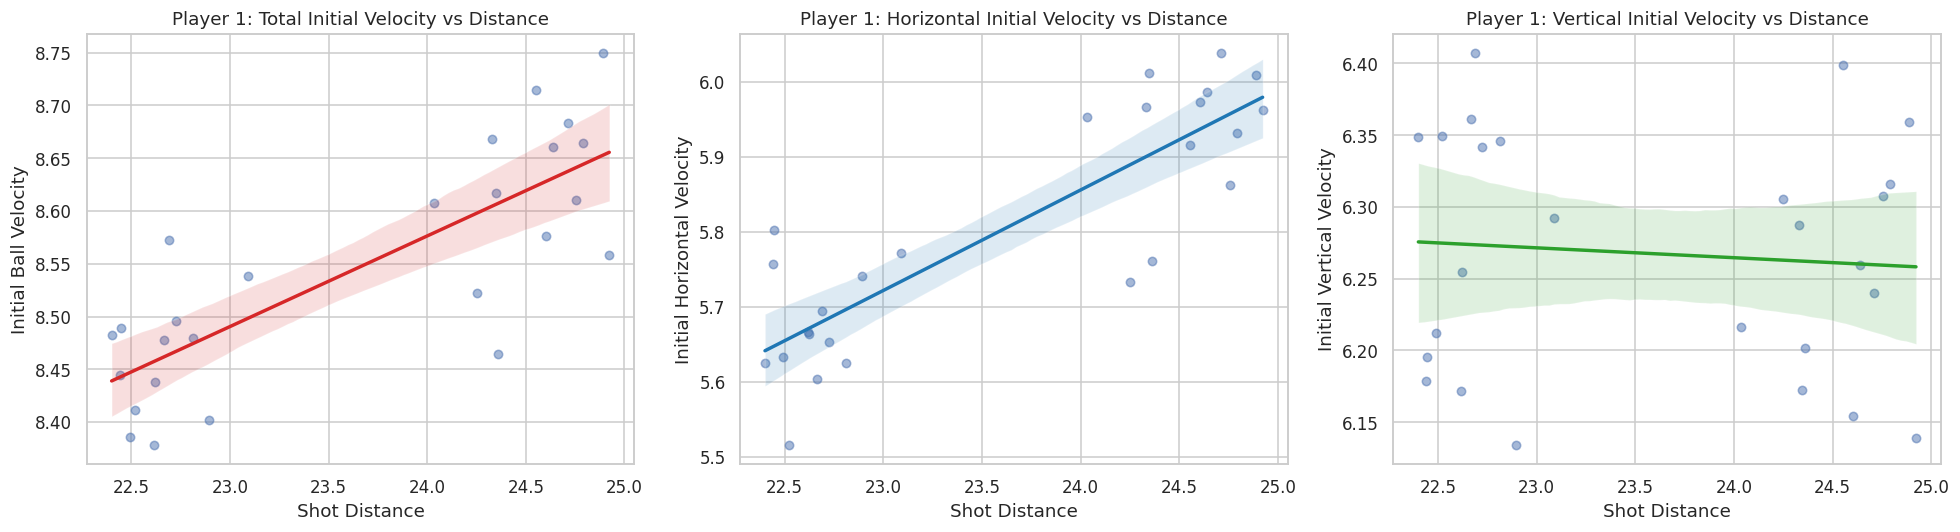

In [8]:
# -----------------------------
# Player-level catch-and-shoot initial velocity vs distance
# -----------------------------

PLAYER_NAME = 'Player 1'   # Change to any player in the Name column
CATCH_LABEL = 'Catch and Shoot'

PLAYER_COL_CANDIDATES = ['Name', 'Player', 'player', 'PlayerName']
SHOT_TYPE_COL_CANDIDATES = ['Shot.Type', 'Shot Type', 'ShotType']
DIST_COL_CANDIDATES = ['Shot.Distance', 'Shot Distance', 'Shot_Distance']
ANGLE_COL_CANDIDATES = ['Initial.Ball.Angle', 'Initial Ball Angle', 'Launch.Angle']
TOTAL_VEL_COL = 'Initial.Ball.Velocity'

def pick_col(candidates, columns):
    return next((c for c in candidates if c in columns), None)

player_col = pick_col(PLAYER_COL_CANDIDATES, df.columns)
shot_type_col = pick_col(SHOT_TYPE_COL_CANDIDATES, df.columns)
dist_col = pick_col(DIST_COL_CANDIDATES, df.columns)
angle_col = pick_col(ANGLE_COL_CANDIDATES, df.columns)
total_vel_col = TOTAL_VEL_COL if TOTAL_VEL_COL in df.columns else None

required_cols = [player_col, shot_type_col, dist_col, angle_col, total_vel_col]
if any(c is None for c in required_cols):
    raise ValueError(
        'Missing required columns for this analysis. Found: ' + str(required_cols)
        + '. Required groups: player, shot type, distance, initial angle, initial velocity.'
    )

cs = df[required_cols + ['Made']].copy()
cs = cs[(cs[player_col] == PLAYER_NAME) & (cs[shot_type_col] == CATCH_LABEL)].copy()
cs = cs.dropna(subset=[dist_col, angle_col, total_vel_col])

if len(cs) < 25:
    raise ValueError(
        f'Only {len(cs)} rows found for {PLAYER_NAME} with {CATCH_LABEL}. '
        + 'Choose another player or broaden filter.'
    )

theta = np.deg2rad(cs[angle_col].astype(float))
cs['v_init_total'] = cs[total_vel_col].astype(float)
cs['v_init_horiz'] = cs['v_init_total'] * np.cos(theta)
cs['v_init_vert'] = cs['v_init_total'] * np.sin(theta)

slope_total, _ = np.polyfit(cs[dist_col], cs['v_init_total'], 1)
slope_horiz, _ = np.polyfit(cs[dist_col], cs['v_init_horiz'], 1)
slope_vert, _ = np.polyfit(cs[dist_col], cs['v_init_vert'], 1)

corr_total = cs[[dist_col, 'v_init_total']].corr().iloc[0, 1]
corr_horiz = cs[[dist_col, 'v_init_horiz']].corr().iloc[0, 1]
corr_vert = cs[[dist_col, 'v_init_vert']].corr().iloc[0, 1]

print('Player:', PLAYER_NAME)
print('Filter:', CATCH_LABEL)
print('Rows:', len(cs))
print('Columns used ->',
      'player:', player_col, '| shot_type:', shot_type_col,
      '| distance:', dist_col, '| angle:', angle_col, '| initial_velocity:', total_vel_col)
print()
print('Initial velocity trends vs distance:')
print('  Total slope      :', round(float(slope_total), 5), '| corr:', round(float(corr_total), 4))
print('  Horizontal slope :', round(float(slope_horiz), 5), '| corr:', round(float(corr_horiz), 4))
print('  Vertical slope   :', round(float(slope_vert), 5), '| corr:', round(float(corr_vert), 4))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.regplot(
    data=cs,
    x=dist_col,
    y='v_init_total',
    scatter_kws={'alpha': 0.5, 's': 30},
    line_kws={'color': 'tab:red'},
    ax=axes[0],
)
axes[0].set_title(f'{PLAYER_NAME}: Total Initial Velocity vs Distance')
axes[0].set_xlabel('Shot Distance')
axes[0].set_ylabel('Initial Ball Velocity')

sns.regplot(
    data=cs,
    x=dist_col,
    y='v_init_horiz',
    scatter_kws={'alpha': 0.5, 's': 30},
    line_kws={'color': 'tab:blue'},
    ax=axes[1],
)
axes[1].set_title(f'{PLAYER_NAME}: Horizontal Initial Velocity vs Distance')
axes[1].set_xlabel('Shot Distance')
axes[1].set_ylabel('Initial Horizontal Velocity')

sns.regplot(
    data=cs,
    x=dist_col,
    y='v_init_vert',
    scatter_kws={'alpha': 0.5, 's': 30},
    line_kws={'color': 'tab:green'},
    ax=axes[2],
)
axes[2].set_title(f'{PLAYER_NAME}: Vertical Initial Velocity vs Distance')
axes[2].set_xlabel('Shot Distance')
axes[2].set_ylabel('Initial Vertical Velocity')

plt.tight_layout()
plt.show()

## Section 8: All-Players Initial Velocity Comparison Table

Build a one-row-per-player comparison for catch-and-shoot attempts, aligned with Section 7 and based on initial velocity only.

Per-player metrics include:
- Sample size and mean distance
- Total initial velocity slope vs distance and correlation
- Horizontal initial velocity slope vs distance and correlation
- Vertical initial velocity slope vs distance and correlation
- Catch-and-shoot make rate

This uses only players with at least `MIN_SHOTS_PER_PLAYER` valid catch-and-shoot attempts.

All-player catch-and-shoot initial-velocity comparison (1 row per player):
Minimum shots per player: 20
Row-level filters -> min initial velocity: 1.0
Columns used -> player: Name | shot_type: Shot.Type | distance: Shot.Distance | angle: Initial.Ball.Angle | initial_velocity: Initial.Ball.Velocity

Cross-player trend summary:
  corr(total slope, make rate)           = 0.047
  corr(horizontal slope, vertical slope) = -0.2344
  pct players with positive horiz slope  = 100.0 %
  pct players with positive vert slope   = 86.0 %
  DBSCAN outliers (slope-space)          = 12

DBSCAN outlier players:
    player  n_catch_shots  make_rate  horiz_slope_vs_distance  vert_slope_vs_distance
Player 139             76     0.5395                   0.0661                  0.0775
 Player 76             43     0.3488                   0.0664                  0.1219
 Player 52            105     0.6095                   0.0699                  0.0807
 Player 26             43     0.5349                   0

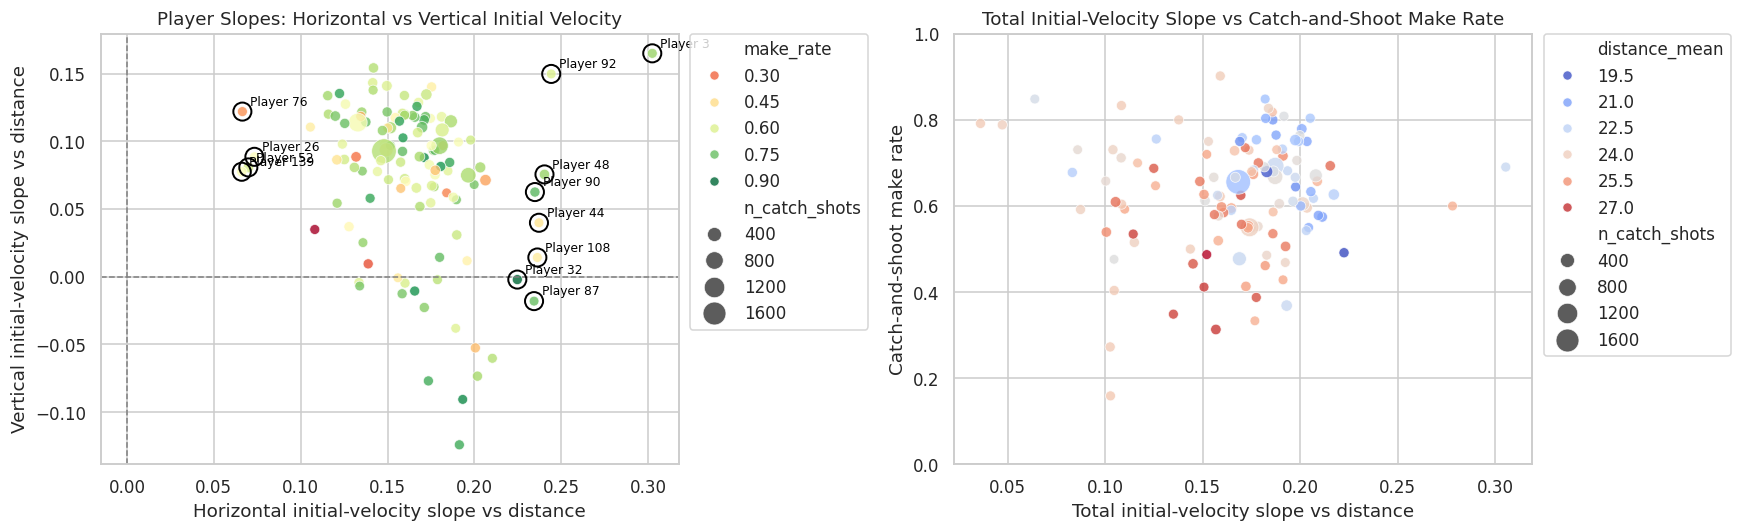

In [9]:
# -----------------------------
# All-players initial velocity comparison (aligned to Section 9)
# -----------------------------

from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

MIN_SHOTS_PER_PLAYER = 20
MIN_INIT_SPEED = 1.0
CATCH_LABEL_ALL = 'Catch and Shoot'

# DBSCAN parameters on standardized slope space.
DBSCAN_EPS = 0.75
DBSCAN_MIN_SAMPLES = 5

PLAYER_COL_CANDIDATES = ['Name', 'Player', 'player', 'PlayerName']
SHOT_TYPE_COL_CANDIDATES = ['Shot.Type', 'Shot Type', 'ShotType']
DIST_COL_CANDIDATES = ['Shot.Distance', 'Shot Distance', 'Shot_Distance']
ANGLE_COL_CANDIDATES = ['Initial.Ball.Angle', 'Initial Ball Angle', 'Launch.Angle']
TOTAL_VEL_COL = 'Initial.Ball.Velocity'

def pick_col(candidates, columns):
    return next((c for c in candidates if c in columns), None)

player_col_all = pick_col(PLAYER_COL_CANDIDATES, df.columns)
shot_type_col_all = pick_col(SHOT_TYPE_COL_CANDIDATES, df.columns)
dist_col_all = pick_col(DIST_COL_CANDIDATES, df.columns)
angle_col_all = pick_col(ANGLE_COL_CANDIDATES, df.columns)
total_vel_col_all = TOTAL_VEL_COL if TOTAL_VEL_COL in df.columns else None

required_cols_all = [
    player_col_all, shot_type_col_all, dist_col_all, angle_col_all, total_vel_col_all, 'Made'
 ]
if any(c is None for c in required_cols_all):
    raise ValueError(
        'Missing required columns for all-player initial-velocity comparison. Found: ' + str(required_cols_all)
    )

cs_all = df[required_cols_all].copy()
cs_all = cs_all[cs_all[shot_type_col_all] == CATCH_LABEL_ALL].copy()
cs_all = cs_all.dropna(subset=[dist_col_all, angle_col_all, total_vel_col_all, player_col_all, 'Made'])
cs_all = cs_all[cs_all[total_vel_col_all].astype(float) >= MIN_INIT_SPEED].copy()

theta_all = np.deg2rad(cs_all[angle_col_all].astype(float))
cs_all['v_init_total'] = cs_all[total_vel_col_all].astype(float)
cs_all['v_init_horiz'] = cs_all['v_init_total'] * np.cos(theta_all)
cs_all['v_init_vert'] = cs_all['v_init_total'] * np.sin(theta_all)

player_rows = []
for player_name, g in cs_all.groupby(player_col_all, observed=False):
    if len(g) < MIN_SHOTS_PER_PLAYER:
        continue

    slope_total, _ = np.polyfit(g[dist_col_all], g['v_init_total'], 1)
    slope_horiz, _ = np.polyfit(g[dist_col_all], g['v_init_horiz'], 1)
    slope_vert, _ = np.polyfit(g[dist_col_all], g['v_init_vert'], 1)

    corr_total = float(g[[dist_col_all, 'v_init_total']].corr().iloc[0, 1])
    corr_horiz = float(g[[dist_col_all, 'v_init_horiz']].corr().iloc[0, 1])
    corr_vert = float(g[[dist_col_all, 'v_init_vert']].corr().iloc[0, 1])

    player_rows.append({
        'player': player_name,
        'n_catch_shots': int(len(g)),
        'distance_mean': float(g[dist_col_all].mean()),
        'total_slope_vs_distance': float(slope_total),
        'total_corr': corr_total,
        'horiz_slope_vs_distance': float(slope_horiz),
        'horiz_corr': corr_horiz,
        'vert_slope_vs_distance': float(slope_vert),
        'vert_corr': corr_vert,
        'make_rate': float(g['Made'].mean()),
    })

player_compare = pd.DataFrame(player_rows)
if player_compare.empty:
    raise ValueError(
        f'No players have at least {MIN_SHOTS_PER_PLAYER} valid catch-and-shoot shots after filters.'
    )

player_compare = player_compare.sort_values(
    ['total_slope_vs_distance', 'horiz_slope_vs_distance', 'n_catch_shots'],
    ascending=[False, False, False]
).reset_index(drop=True)

# DBSCAN on horizontal/vertical slope space.
slope_xy = player_compare[['horiz_slope_vs_distance', 'vert_slope_vs_distance']].values
slope_xy_z = StandardScaler().fit_transform(slope_xy)
db = DBSCAN(eps=DBSCAN_EPS, min_samples=DBSCAN_MIN_SAMPLES)
player_compare['dbscan_label'] = db.fit_predict(slope_xy_z)
player_compare['is_dbscan_outlier'] = player_compare['dbscan_label'] == -1

print('All-player catch-and-shoot initial-velocity comparison (1 row per player):')
print('Minimum shots per player:', MIN_SHOTS_PER_PLAYER)
print('Row-level filters -> min initial velocity:', MIN_INIT_SPEED)
print('Columns used ->',
      'player:', player_col_all, '| shot_type:', shot_type_col_all,
      '| distance:', dist_col_all, '| angle:', angle_col_all,
      '| initial_velocity:', total_vel_col_all)
print()

# Compact trend summary to interpret scatter patterns.
corr_total_make = float(player_compare[['total_slope_vs_distance', 'make_rate']].corr().iloc[0, 1])
corr_horiz_vert = float(player_compare[['horiz_slope_vs_distance', 'vert_slope_vs_distance']].corr().iloc[0, 1])
pct_horiz_pos = float((player_compare['horiz_slope_vs_distance'] > 0).mean())
pct_vert_pos = float((player_compare['vert_slope_vs_distance'] > 0).mean())
n_outliers = int(player_compare['is_dbscan_outlier'].sum())

print('Cross-player trend summary:')
print('  corr(total slope, make rate)           =', round(corr_total_make, 4))
print('  corr(horizontal slope, vertical slope) =', round(corr_horiz_vert, 4))
print('  pct players with positive horiz slope  =', round(pct_horiz_pos * 100, 1), '%')
print('  pct players with positive vert slope   =', round(pct_vert_pos * 100, 1), '%')
print('  DBSCAN outliers (slope-space)          =', n_outliers)

if n_outliers > 0:
    print()
    print('DBSCAN outlier players:')
    print(
        player_compare[player_compare['is_dbscan_outlier']][
            ['player', 'n_catch_shots', 'make_rate', 'horiz_slope_vs_distance', 'vert_slope_vs_distance']
        ]
        .sort_values(['horiz_slope_vs_distance', 'vert_slope_vs_distance'])
        .round(4)
        .to_string(index=False)
    )

display_cols = [
    'player', 'n_catch_shots', 'make_rate',
    'total_slope_vs_distance', 'horiz_slope_vs_distance', 'vert_slope_vs_distance',
    'total_corr', 'horiz_corr', 'vert_corr'
 ]

top_n = min(10, len(player_compare))
print()
print('Top players by total_slope_vs_distance:')
print(player_compare[display_cols].head(top_n).round(4).to_string(index=False))

print()
print('Bottom players by total_slope_vs_distance:')
print(player_compare[display_cols].tail(top_n).round(4).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.scatterplot(
    data=player_compare,
    x='horiz_slope_vs_distance',
    y='vert_slope_vs_distance',
    size='n_catch_shots',
    hue='make_rate',
    palette='RdYlGn',
    sizes=(40, 260),
    alpha=0.8,
    ax=axes[0],
)
axes[0].axvline(0, linestyle='--', linewidth=1, color='gray')
axes[0].axhline(0, linestyle='--', linewidth=1, color='gray')
axes[0].set_title('Player Slopes: Horizontal vs Vertical Initial Velocity')
axes[0].set_xlabel('Horizontal initial-velocity slope vs distance')
axes[0].set_ylabel('Vertical initial-velocity slope vs distance')

# Highlight and label DBSCAN outliers.
outliers = player_compare[player_compare['is_dbscan_outlier']].copy()
if len(outliers) > 0:
    axes[0].scatter(
        outliers['horiz_slope_vs_distance'],
        outliers['vert_slope_vs_distance'],
        s=140,
        facecolors='none',
        edgecolors='black',
        linewidths=1.3,
        zorder=5,
    )
    for _, r in outliers.iterrows():
        axes[0].annotate(
            r['player'],
            (r['horiz_slope_vs_distance'], r['vert_slope_vs_distance']),
            textcoords='offset points',
            xytext=(5, 4),
            fontsize=8,
            color='black',
        )
sns.move_legend(axes[0], 'upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)

sns.scatterplot(
    data=player_compare,
    x='total_slope_vs_distance',
    y='make_rate',
    size='n_catch_shots',
    hue='distance_mean',
    palette='coolwarm',
    sizes=(40, 260),
    alpha=0.8,
    ax=axes[1],
)
axes[1].set_title('Total Initial-Velocity Slope vs Catch-and-Shoot Make Rate')
axes[1].set_xlabel('Total initial-velocity slope vs distance')
axes[1].set_ylabel('Catch-and-shoot make rate')
axes[1].set_ylim(0, 1)
sns.move_legend(axes[1], 'upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)

plt.tight_layout()
plt.show()

In [10]:
# DBSCAN cluster count summary (from Section 10 results).
if 'player_compare' not in globals() or 'dbscan_label' not in player_compare.columns:
    raise ValueError('Run Section 10 first to populate player_compare with dbscan_label.')

cluster_labels = sorted([c for c in player_compare['dbscan_label'].unique() if c != -1])
n_clusters = len(cluster_labels)
n_outliers = int((player_compare['dbscan_label'] == -1).sum())

print('DBSCAN clusters identified (excluding outliers):', n_clusters)
print('DBSCAN outliers:', n_outliers)

if n_clusters > 0:
    cluster_sizes = (
        player_compare[player_compare['dbscan_label'] != -1]
        .groupby('dbscan_label')
        .size()
        .sort_values(ascending=False)
    )
    print('\nCluster sizes:')
    print(cluster_sizes.to_string())

DBSCAN clusters identified (excluding outliers): 1
DBSCAN outliers: 12

Cluster sizes:
dbscan_label
0    109


DBSCAN tuning table (prioritizing negative-vertical-tail capture):
 eps  min_samples  n_clusters  n_outliers  outlier_rate  neg_tail_outliers  neg_tail_capture_rate
0.55            7           1          32        0.2645                 17                 1.0000
0.50            7           1          34        0.2810                 17                 1.0000
0.45            7           1          35        0.2893                 17                 1.0000
0.55            6           2          24        0.1983                 11                 0.6471
0.50            5           2          28        0.2314                 11                 0.6471
0.50            6           2          28        0.2314                 11                 0.6471
0.45            5           2          29        0.2397                 11                 0.6471
0.45            6           2          29        0.2397                 11                 0.6471
0.60            7           2          22        0.

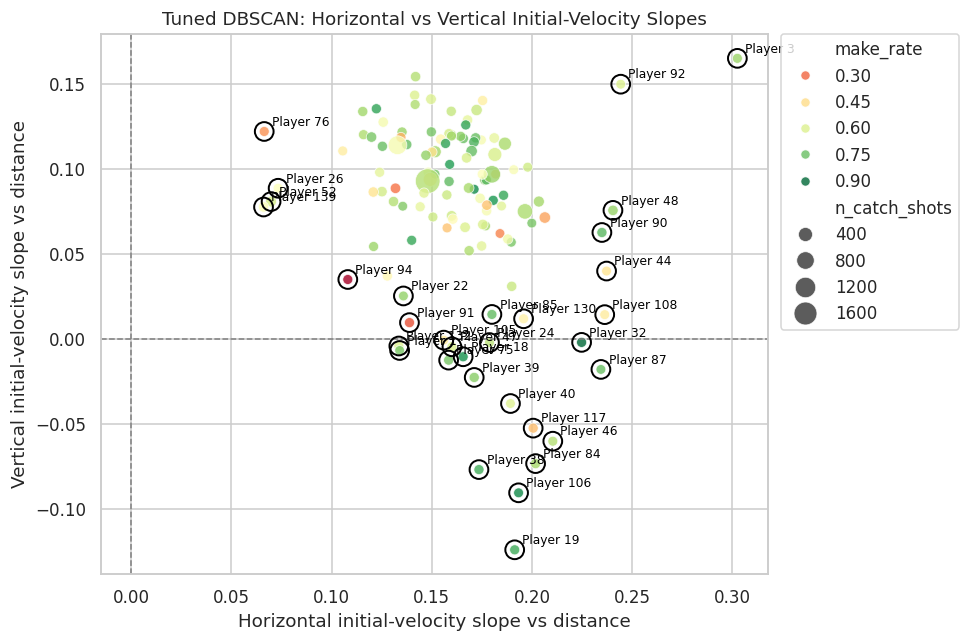

In [11]:
# DBSCAN parameter tuning to better capture the negative-vertical tail as outliers.
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

if 'player_compare' not in globals():
    raise ValueError('Run Section 10 first to build player_compare.')

work = player_compare.copy()
X = work[['horiz_slope_vs_distance', 'vert_slope_vs_distance']].values
Xz = StandardScaler().fit_transform(X)

neg_tail_mask = work['vert_slope_vs_distance'] < 0
n_neg_tail = int(neg_tail_mask.sum())

eps_grid = [0.45, 0.50, 0.55, 0.60, 0.65, 0.70]
min_samples_grid = [4, 5, 6, 7]

rows = []
for eps in eps_grid:
    for ms in min_samples_grid:
        labels = DBSCAN(eps=eps, min_samples=ms).fit_predict(Xz)
        outlier_mask = labels == -1
        n_out = int(outlier_mask.sum())
        n_clusters = len(set(labels) - {-1})
        n_neg_tail_out = int((outlier_mask & neg_tail_mask).sum())
        neg_tail_capture = (n_neg_tail_out / n_neg_tail) if n_neg_tail > 0 else np.nan
        outlier_rate = n_out / len(work)
        rows.append({
            'eps': eps,
            'min_samples': ms,
            'n_clusters': n_clusters,
            'n_outliers': n_out,
            'outlier_rate': outlier_rate,
            'neg_tail_outliers': n_neg_tail_out,
            'neg_tail_capture_rate': neg_tail_capture,
        })

tune = pd.DataFrame(rows).sort_values(
    ['neg_tail_capture_rate', 'n_outliers', 'eps'],
    ascending=[False, True, True]
).reset_index(drop=True)

print('DBSCAN tuning table (prioritizing negative-vertical-tail capture):')
print(tune.round(4).to_string(index=False))

# Pick a balanced candidate: high tail capture, but avoid excessive total outliers.
candidate = tune[(tune['neg_tail_capture_rate'] >= 0.70) & (tune['outlier_rate'] <= 0.35)]
if candidate.empty:
    candidate = tune.head(1)
else:
    candidate = candidate.head(1)

eps_best = float(candidate.iloc[0]['eps'])
ms_best = int(candidate.iloc[0]['min_samples'])
labels_best = DBSCAN(eps=eps_best, min_samples=ms_best).fit_predict(Xz)

work['dbscan_label_tuned'] = labels_best
work['is_dbscan_outlier_tuned'] = work['dbscan_label_tuned'] == -1

print()
print('Selected tuning -> eps =', eps_best, ', min_samples =', ms_best)
print('Clusters (excluding outliers):', len(set(labels_best) - {-1}))
print('Outliers:', int(work['is_dbscan_outlier_tuned'].sum()))
print('Negative-vertical outliers:', int((work['is_dbscan_outlier_tuned'] & neg_tail_mask).sum()), 'of', n_neg_tail)

if work['is_dbscan_outlier_tuned'].any():
    print()
    print('Tuned outlier players:')
    print(
        work[work['is_dbscan_outlier_tuned']][
            ['player', 'n_catch_shots', 'make_rate', 'horiz_slope_vs_distance', 'vert_slope_vs_distance']
        ]
        .sort_values(['vert_slope_vs_distance', 'horiz_slope_vs_distance'])
        .round(4)
        .to_string(index=False)
    )

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=work,
    x='horiz_slope_vs_distance',
    y='vert_slope_vs_distance',
    hue='make_rate',
    size='n_catch_shots',
    palette='RdYlGn',
    sizes=(40, 260),
    alpha=0.8,
 )
plt.axvline(0, linestyle='--', linewidth=1, color='gray')
plt.axhline(0, linestyle='--', linewidth=1, color='gray')
plt.title('Tuned DBSCAN: Horizontal vs Vertical Initial-Velocity Slopes')
plt.xlabel('Horizontal initial-velocity slope vs distance')
plt.ylabel('Vertical initial-velocity slope vs distance')

outliers_tuned = work[work['is_dbscan_outlier_tuned']]
if len(outliers_tuned) > 0:
    plt.scatter(
        outliers_tuned['horiz_slope_vs_distance'],
        outliers_tuned['vert_slope_vs_distance'],
        s=150,
        facecolors='none',
        edgecolors='black',
        linewidths=1.3,
        zorder=6,
    )
    for _, r in outliers_tuned.iterrows():
        plt.annotate(
            r['player'],
            (r['horiz_slope_vs_distance'], r['vert_slope_vs_distance']),
            textcoords='offset points',
            xytext=(5, 4),
            fontsize=8,
            color='black',
        )

ax = plt.gca()
sns.move_legend(ax, 'upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)
plt.tight_layout()
plt.show()

## Section 9: Player Off-the-Dribble Initial Velocity vs Distance

For one player on off-the-dribble attempts, visualize how initial ball velocity changes with shot distance using:
- Total initial ball velocity
- Horizontal initial ball velocity component
- Vertical initial ball velocity component

Definitions:
- Total: `Initial.Ball.Velocity`
- Horizontal: `Initial.Ball.Velocity * cos(Initial.Ball.Angle)`
- Vertical: `Initial.Ball.Velocity * sin(Initial.Ball.Angle)`

Player: Player 1
Filter: Off the Dribble
Rows: 51
Columns used -> player: Name | shot_type: Shot.Type | distance: Shot.Distance | angle: Initial.Ball.Angle | initial_velocity: Initial.Ball.Velocity

Initial velocity trends vs distance (Off the Dribble):
  Total slope      : 0.22063 | corr: 0.9969
  Horizontal slope : 0.17825 | corr: 0.9895
  Vertical slope   : 0.13571 | corr: 0.9836


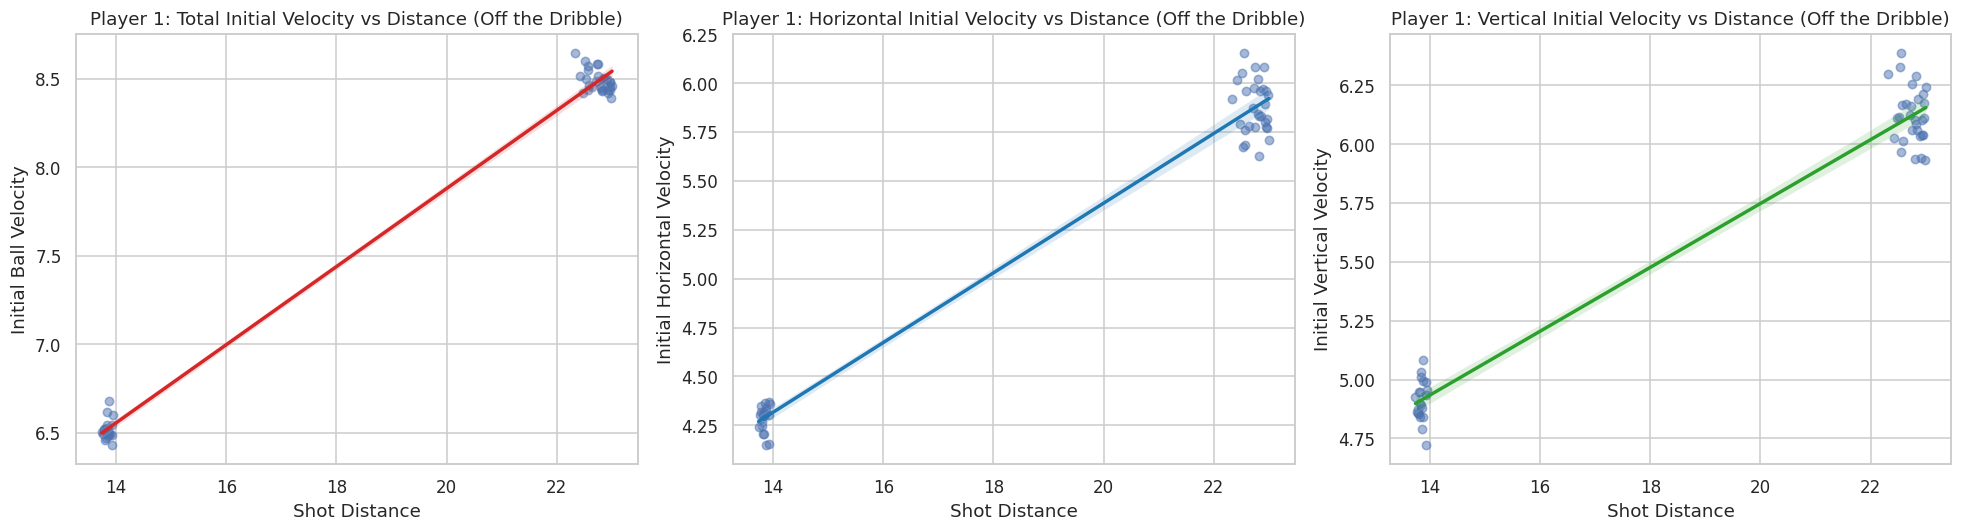

In [12]:
# -----------------------------
# Player-level off-the-dribble initial velocity vs distance
# -----------------------------

PLAYER_NAME_OTD = 'Player 1'   # Change to any player in the Name column
OFF_DRIBBLE_LABEL = 'Off the Dribble'

PLAYER_COL_CANDIDATES = ['Name', 'Player', 'player', 'PlayerName']
SHOT_TYPE_COL_CANDIDATES = ['Shot.Type', 'Shot Type', 'ShotType']
DIST_COL_CANDIDATES = ['Shot.Distance', 'Shot Distance', 'Shot_Distance']
ANGLE_COL_CANDIDATES = ['Initial.Ball.Angle', 'Initial Ball Angle', 'Launch.Angle']
TOTAL_VEL_COL = 'Initial.Ball.Velocity'

def pick_col(candidates, columns):
    return next((c for c in candidates if c in columns), None)

player_col = pick_col(PLAYER_COL_CANDIDATES, df.columns)
shot_type_col = pick_col(SHOT_TYPE_COL_CANDIDATES, df.columns)
dist_col = pick_col(DIST_COL_CANDIDATES, df.columns)
angle_col = pick_col(ANGLE_COL_CANDIDATES, df.columns)
total_vel_col = TOTAL_VEL_COL if TOTAL_VEL_COL in df.columns else None

required_cols = [player_col, shot_type_col, dist_col, angle_col, total_vel_col]
if any(c is None for c in required_cols):
    raise ValueError(
        'Missing required columns for this analysis. Found: ' + str(required_cols)
        + '. Required groups: player, shot type, distance, initial angle, initial velocity.'
    )

otd = df[required_cols + ['Made']].copy()
otd = otd[(otd[player_col] == PLAYER_NAME_OTD) & (otd[shot_type_col] == OFF_DRIBBLE_LABEL)].copy()
otd = otd.dropna(subset=[dist_col, angle_col, total_vel_col])

if len(otd) < 25:
    raise ValueError(
        f'Only {len(otd)} rows found for {PLAYER_NAME_OTD} with {OFF_DRIBBLE_LABEL}. '
        + 'Choose another player or broaden filter.'
    )

theta = np.deg2rad(otd[angle_col].astype(float))
otd['v_init_total'] = otd[total_vel_col].astype(float)
otd['v_init_horiz'] = otd['v_init_total'] * np.cos(theta)
otd['v_init_vert'] = otd['v_init_total'] * np.sin(theta)

slope_total, _ = np.polyfit(otd[dist_col], otd['v_init_total'], 1)
slope_horiz, _ = np.polyfit(otd[dist_col], otd['v_init_horiz'], 1)
slope_vert, _ = np.polyfit(otd[dist_col], otd['v_init_vert'], 1)

corr_total = otd[[dist_col, 'v_init_total']].corr().iloc[0, 1]
corr_horiz = otd[[dist_col, 'v_init_horiz']].corr().iloc[0, 1]
corr_vert = otd[[dist_col, 'v_init_vert']].corr().iloc[0, 1]

print('Player:', PLAYER_NAME_OTD)
print('Filter:', OFF_DRIBBLE_LABEL)
print('Rows:', len(otd))
print('Columns used ->',
      'player:', player_col, '| shot_type:', shot_type_col,
      '| distance:', dist_col, '| angle:', angle_col, '| initial_velocity:', total_vel_col)
print()
print('Initial velocity trends vs distance (Off the Dribble):')
print('  Total slope      :', round(float(slope_total), 5), '| corr:', round(float(corr_total), 4))
print('  Horizontal slope :', round(float(slope_horiz), 5), '| corr:', round(float(corr_horiz), 4))
print('  Vertical slope   :', round(float(slope_vert), 5), '| corr:', round(float(corr_vert), 4))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.regplot(
    data=otd,
    x=dist_col,
    y='v_init_total',
    scatter_kws={'alpha': 0.5, 's': 30},
    line_kws={'color': 'tab:red'},
    ax=axes[0],
)
axes[0].set_title(f'{PLAYER_NAME_OTD}: Total Initial Velocity vs Distance (Off the Dribble)')
axes[0].set_xlabel('Shot Distance')
axes[0].set_ylabel('Initial Ball Velocity')

sns.regplot(
    data=otd,
    x=dist_col,
    y='v_init_horiz',
    scatter_kws={'alpha': 0.5, 's': 30},
    line_kws={'color': 'tab:blue'},
    ax=axes[1],
)
axes[1].set_title(f'{PLAYER_NAME_OTD}: Horizontal Initial Velocity vs Distance (Off the Dribble)')
axes[1].set_xlabel('Shot Distance')
axes[1].set_ylabel('Initial Horizontal Velocity')

sns.regplot(
    data=otd,
    x=dist_col,
    y='v_init_vert',
    scatter_kws={'alpha': 0.5, 's': 30},
    line_kws={'color': 'tab:green'},
    ax=axes[2],
)
axes[2].set_title(f'{PLAYER_NAME_OTD}: Vertical Initial Velocity vs Distance (Off the Dribble)')
axes[2].set_xlabel('Shot Distance')
axes[2].set_ylabel('Initial Vertical Velocity')

plt.tight_layout()
plt.show()

## Section 10: All-Players Off-the-Dribble Initial Velocity Comparison Table

Build a one-row-per-player comparison for off-the-dribble attempts, parallel to the catch-and-shoot all-players section.

Per-player metrics include:
- Sample size and mean distance
- Total initial velocity slope vs distance and correlation
- Horizontal initial velocity slope vs distance and correlation
- Vertical initial velocity slope vs distance and correlation
- Off-the-dribble make rate

This uses only players with at least `MIN_SHOTS_PER_PLAYER_OTD` valid off-the-dribble attempts.

All-player off-the-dribble initial-velocity comparison (1 row per player):
Minimum shots per player: 20
Row-level filters -> min initial velocity: 1.0
Columns used -> player: Name | shot_type: Shot.Type | distance: Shot.Distance | angle: Initial.Ball.Angle | initial_velocity: Initial.Ball.Velocity

Cross-player trend summary:
  corr(total slope, make rate)           = 0.2228
  corr(horizontal slope, vertical slope) = -0.1745
  pct players with positive horiz slope  = 96.4 %
  pct players with positive vert slope   = 96.4 %
  DBSCAN outliers (slope-space)          = 11

DBSCAN outlier players:
    player  n_off_dribble_shots  make_rate  horiz_slope_vs_distance  vert_slope_vs_distance
 Player 44                   29     0.6552                  -0.3781                  0.3303
Player 155                   32     0.7500                  -0.3083                  0.2237
 Player 85                   21     0.7619                  -0.1608                  0.2438
 Player 96                   31 

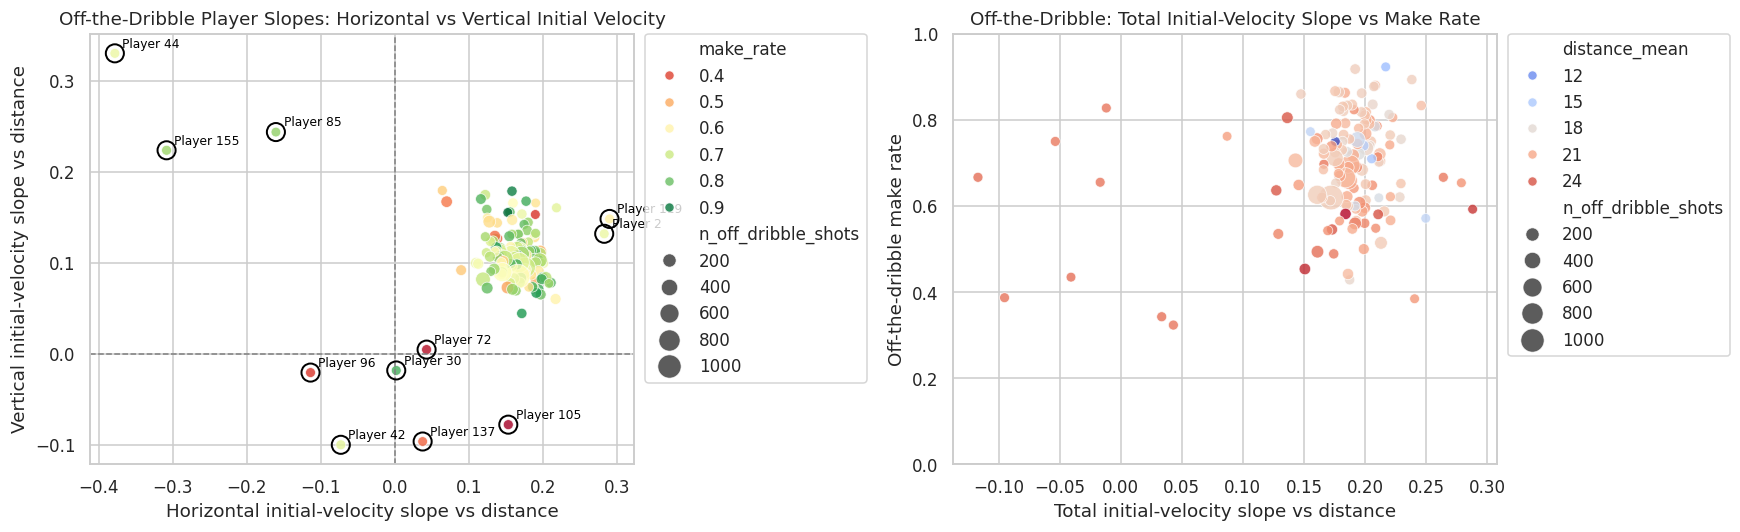

In [13]:
# -----------------------------
# All-players off-the-dribble initial velocity comparison
# -----------------------------

from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

MIN_SHOTS_PER_PLAYER_OTD = 20
MIN_INIT_SPEED_OTD = 1.0
OFF_DRIBBLE_LABEL_ALL = 'Off the Dribble'

# DBSCAN parameters on standardized slope space.
DBSCAN_EPS_OTD = 0.75
DBSCAN_MIN_SAMPLES_OTD = 5

PLAYER_COL_CANDIDATES = ['Name', 'Player', 'player', 'PlayerName']
SHOT_TYPE_COL_CANDIDATES = ['Shot.Type', 'Shot Type', 'ShotType']
DIST_COL_CANDIDATES = ['Shot.Distance', 'Shot Distance', 'Shot_Distance']
ANGLE_COL_CANDIDATES = ['Initial.Ball.Angle', 'Initial Ball Angle', 'Launch.Angle']
TOTAL_VEL_COL = 'Initial.Ball.Velocity'

def pick_col(candidates, columns):
    return next((c for c in candidates if c in columns), None)

player_col_otd_all = pick_col(PLAYER_COL_CANDIDATES, df.columns)
shot_type_col_otd_all = pick_col(SHOT_TYPE_COL_CANDIDATES, df.columns)
dist_col_otd_all = pick_col(DIST_COL_CANDIDATES, df.columns)
angle_col_otd_all = pick_col(ANGLE_COL_CANDIDATES, df.columns)
total_vel_col_otd_all = TOTAL_VEL_COL if TOTAL_VEL_COL in df.columns else None

required_cols_otd_all = [
    player_col_otd_all, shot_type_col_otd_all, dist_col_otd_all, angle_col_otd_all, total_vel_col_otd_all, 'Made'
]
if any(c is None for c in required_cols_otd_all):
    raise ValueError(
        'Missing required columns for all-player off-the-dribble comparison. Found: ' + str(required_cols_otd_all)
    )

otd_all = df[required_cols_otd_all].copy()
otd_all = otd_all[otd_all[shot_type_col_otd_all] == OFF_DRIBBLE_LABEL_ALL].copy()
otd_all = otd_all.dropna(subset=[dist_col_otd_all, angle_col_otd_all, total_vel_col_otd_all, player_col_otd_all, 'Made'])
otd_all = otd_all[otd_all[total_vel_col_otd_all].astype(float) >= MIN_INIT_SPEED_OTD].copy()

theta_otd_all = np.deg2rad(otd_all[angle_col_otd_all].astype(float))
otd_all['v_init_total'] = otd_all[total_vel_col_otd_all].astype(float)
otd_all['v_init_horiz'] = otd_all['v_init_total'] * np.cos(theta_otd_all)
otd_all['v_init_vert'] = otd_all['v_init_total'] * np.sin(theta_otd_all)

player_rows_otd = []
for player_name, g in otd_all.groupby(player_col_otd_all, observed=False):
    if len(g) < MIN_SHOTS_PER_PLAYER_OTD:
        continue

    slope_total, _ = np.polyfit(g[dist_col_otd_all], g['v_init_total'], 1)
    slope_horiz, _ = np.polyfit(g[dist_col_otd_all], g['v_init_horiz'], 1)
    slope_vert, _ = np.polyfit(g[dist_col_otd_all], g['v_init_vert'], 1)

    corr_total = float(g[[dist_col_otd_all, 'v_init_total']].corr().iloc[0, 1])
    corr_horiz = float(g[[dist_col_otd_all, 'v_init_horiz']].corr().iloc[0, 1])
    corr_vert = float(g[[dist_col_otd_all, 'v_init_vert']].corr().iloc[0, 1])

    player_rows_otd.append({
        'player': player_name,
        'n_off_dribble_shots': int(len(g)),
        'distance_mean': float(g[dist_col_otd_all].mean()),
        'total_slope_vs_distance': float(slope_total),
        'total_corr': corr_total,
        'horiz_slope_vs_distance': float(slope_horiz),
        'horiz_corr': corr_horiz,
        'vert_slope_vs_distance': float(slope_vert),
        'vert_corr': corr_vert,
        'make_rate': float(g['Made'].mean()),
    })

player_compare_otd = pd.DataFrame(player_rows_otd)
if player_compare_otd.empty:
    raise ValueError(
        f'No players have at least {MIN_SHOTS_PER_PLAYER_OTD} valid off-the-dribble shots after filters.'
    )

player_compare_otd = player_compare_otd.sort_values(
    ['total_slope_vs_distance', 'horiz_slope_vs_distance', 'n_off_dribble_shots'],
    ascending=[False, False, False]
).reset_index(drop=True)

# DBSCAN on horizontal/vertical slope space.
slope_xy_otd = player_compare_otd[['horiz_slope_vs_distance', 'vert_slope_vs_distance']].values
slope_xy_otd_z = StandardScaler().fit_transform(slope_xy_otd)
db_otd = DBSCAN(eps=DBSCAN_EPS_OTD, min_samples=DBSCAN_MIN_SAMPLES_OTD)
player_compare_otd['dbscan_label'] = db_otd.fit_predict(slope_xy_otd_z)
player_compare_otd['is_dbscan_outlier'] = player_compare_otd['dbscan_label'] == -1

print('All-player off-the-dribble initial-velocity comparison (1 row per player):')
print('Minimum shots per player:', MIN_SHOTS_PER_PLAYER_OTD)
print('Row-level filters -> min initial velocity:', MIN_INIT_SPEED_OTD)
print('Columns used ->',
      'player:', player_col_otd_all, '| shot_type:', shot_type_col_otd_all,
      '| distance:', dist_col_otd_all, '| angle:', angle_col_otd_all,
      '| initial_velocity:', total_vel_col_otd_all)
print()

corr_total_make_otd = float(player_compare_otd[['total_slope_vs_distance', 'make_rate']].corr().iloc[0, 1])
corr_horiz_vert_otd = float(player_compare_otd[['horiz_slope_vs_distance', 'vert_slope_vs_distance']].corr().iloc[0, 1])
pct_horiz_pos_otd = float((player_compare_otd['horiz_slope_vs_distance'] > 0).mean())
pct_vert_pos_otd = float((player_compare_otd['vert_slope_vs_distance'] > 0).mean())
n_outliers_otd = int(player_compare_otd['is_dbscan_outlier'].sum())

print('Cross-player trend summary:')
print('  corr(total slope, make rate)           =', round(corr_total_make_otd, 4))
print('  corr(horizontal slope, vertical slope) =', round(corr_horiz_vert_otd, 4))
print('  pct players with positive horiz slope  =', round(pct_horiz_pos_otd * 100, 1), '%')
print('  pct players with positive vert slope   =', round(pct_vert_pos_otd * 100, 1), '%')
print('  DBSCAN outliers (slope-space)          =', n_outliers_otd)

if n_outliers_otd > 0:
    print()
    print('DBSCAN outlier players:')
    print(
        player_compare_otd[player_compare_otd['is_dbscan_outlier']][
            ['player', 'n_off_dribble_shots', 'make_rate', 'horiz_slope_vs_distance', 'vert_slope_vs_distance']
        ]
        .sort_values(['horiz_slope_vs_distance', 'vert_slope_vs_distance'])
        .round(4)
        .to_string(index=False)
    )

display_cols_otd = [
    'player', 'n_off_dribble_shots', 'make_rate',
    'total_slope_vs_distance', 'horiz_slope_vs_distance', 'vert_slope_vs_distance',
    'total_corr', 'horiz_corr', 'vert_corr'
]

top_n_otd = min(10, len(player_compare_otd))
print()
print('Top players by total_slope_vs_distance:')
print(player_compare_otd[display_cols_otd].head(top_n_otd).round(4).to_string(index=False))

print()
print('Bottom players by total_slope_vs_distance:')
print(player_compare_otd[display_cols_otd].tail(top_n_otd).round(4).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.scatterplot(
    data=player_compare_otd,
    x='horiz_slope_vs_distance',
    y='vert_slope_vs_distance',
    size='n_off_dribble_shots',
    hue='make_rate',
    palette='RdYlGn',
    sizes=(40, 260),
    alpha=0.8,
    ax=axes[0],
)
axes[0].axvline(0, linestyle='--', linewidth=1, color='gray')
axes[0].axhline(0, linestyle='--', linewidth=1, color='gray')
axes[0].set_title('Off-the-Dribble Player Slopes: Horizontal vs Vertical Initial Velocity')
axes[0].set_xlabel('Horizontal initial-velocity slope vs distance')
axes[0].set_ylabel('Vertical initial-velocity slope vs distance')

outliers_otd = player_compare_otd[player_compare_otd['is_dbscan_outlier']].copy()
if len(outliers_otd) > 0:
    axes[0].scatter(
        outliers_otd['horiz_slope_vs_distance'],
        outliers_otd['vert_slope_vs_distance'],
        s=140,
        facecolors='none',
        edgecolors='black',
        linewidths=1.3,
        zorder=5,
    )
    for _, r in outliers_otd.iterrows():
        axes[0].annotate(
            r['player'],
            (r['horiz_slope_vs_distance'], r['vert_slope_vs_distance']),
            textcoords='offset points',
            xytext=(5, 4),
            fontsize=8,
            color='black',
        )
sns.move_legend(axes[0], 'upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)

sns.scatterplot(
    data=player_compare_otd,
    x='total_slope_vs_distance',
    y='make_rate',
    size='n_off_dribble_shots',
    hue='distance_mean',
    palette='coolwarm',
    sizes=(40, 260),
    alpha=0.8,
    ax=axes[1],
)
axes[1].set_title('Off-the-Dribble: Total Initial-Velocity Slope vs Make Rate')
axes[1].set_xlabel('Total initial-velocity slope vs distance')
axes[1].set_ylabel('Off-the-dribble make rate')
axes[1].set_ylim(0, 1)
sns.move_legend(axes[1], 'upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)

plt.tight_layout()
plt.show()

## Section 11: Within-Player Movement in Player Slope Space

For each player, map their slope position in 2D space:
- x-axis: horizontal initial-velocity slope vs distance
- y-axis: vertical initial-velocity slope vs distance

Then draw an arrow from the player's catch-and-shoot slope point to their off-the-dribble slope point to show within-player movement in slope space.

Players are included only if they have at least `MIN_SHOTS_PER_TYPE_WITHIN` shots in each shot type.

Within-player slope-space movement summary (Catch and Shoot -> Off the Dribble)
Players meeting threshold: 121
Min shots per type: 15
Columns used -> player: Name | shot_type: Shot.Type | distance: Shot.Distance | angle: Initial.Ball.Angle | initial_velocity: Initial.Ball.Velocity

Largest movers in player slope space:
    player  n_catch  n_off  horiz_slope_catch  vert_slope_catch  horiz_slope_off  vert_slope_off  delta_horiz_slope  delta_vert_slope  arrow_mag  delta_total_slope  delta_make
 Player 44       32     29             0.2372            0.0398          -0.3781          0.3303            -0.6153            0.2904     0.6804            -0.2093      0.1864
 Player 85       45     21             0.1800            0.0143          -0.1608          0.2438            -0.3408            0.2294     0.4108            -0.0392      0.0063
 Player 19       48     37             0.1914           -0.1241           0.1878          0.1314            -0.0035            0.2555     0.2555       

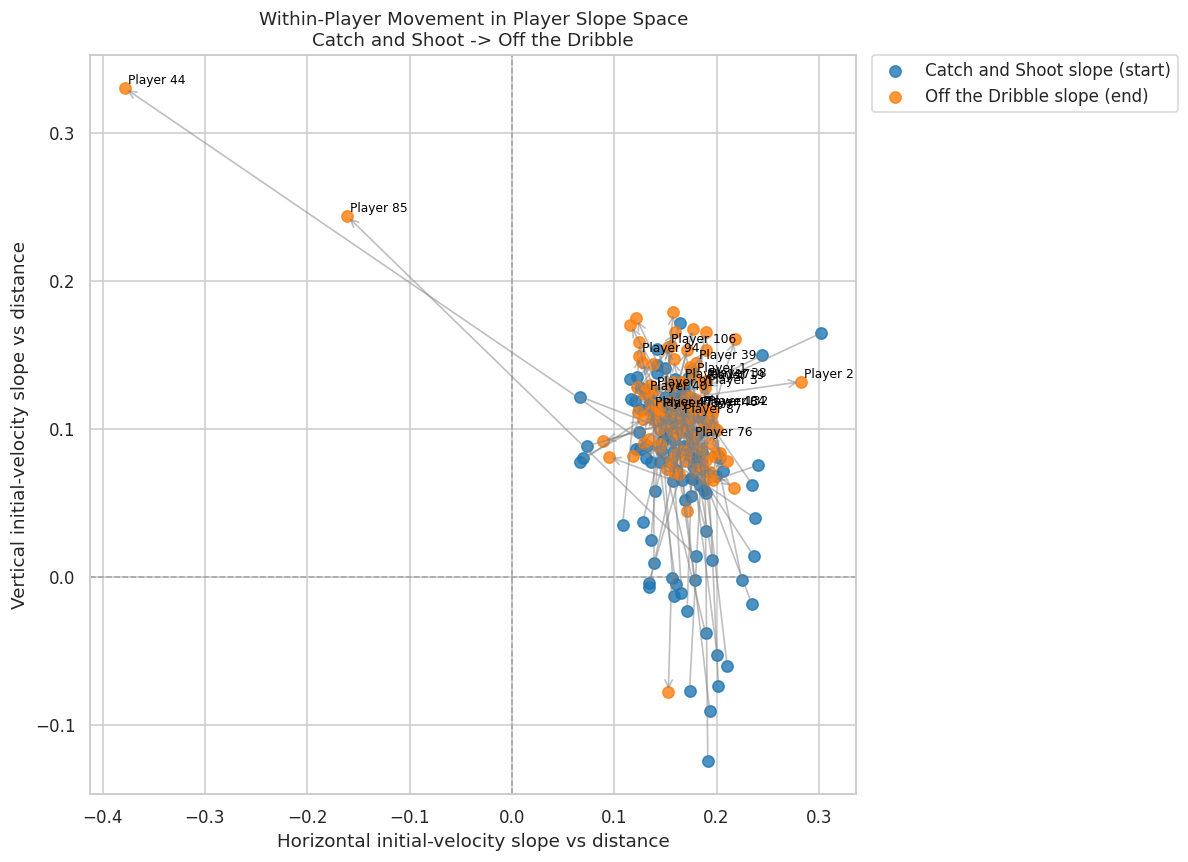

In [14]:
# -----------------------------
# Within-player movement: Catch-and-Shoot -> Off-the-Dribble (slope space)
# -----------------------------

MIN_SHOTS_PER_TYPE_WITHIN = 15
CATCH_LABEL_WITHIN = 'Catch and Shoot'
OFF_LABEL_WITHIN = 'Off the Dribble'
N_LABEL_PLAYERS = 20  # Label the largest movers to keep the figure readable.

PLAYER_COL_CANDIDATES = ['Name', 'Player', 'player', 'PlayerName']
SHOT_TYPE_COL_CANDIDATES = ['Shot.Type', 'Shot Type', 'ShotType']
DIST_COL_CANDIDATES = ['Shot.Distance', 'Shot Distance', 'Shot_Distance']
ANGLE_COL_CANDIDATES = ['Initial.Ball.Angle', 'Initial Ball Angle', 'Launch.Angle']
TOTAL_VEL_COL = 'Initial.Ball.Velocity'

def pick_col(candidates, columns):
    return next((c for c in candidates if c in columns), None)

player_col_within = pick_col(PLAYER_COL_CANDIDATES, df.columns)
shot_type_col_within = pick_col(SHOT_TYPE_COL_CANDIDATES, df.columns)
dist_col_within = pick_col(DIST_COL_CANDIDATES, df.columns)
angle_col_within = pick_col(ANGLE_COL_CANDIDATES, df.columns)
total_vel_col_within = TOTAL_VEL_COL if TOTAL_VEL_COL in df.columns else None

required_cols_within = [
    player_col_within, shot_type_col_within, dist_col_within, angle_col_within, total_vel_col_within, 'Made'
]
if any(c is None for c in required_cols_within):
    raise ValueError(
        'Missing required columns for within-player slope movement analysis. Found: ' + str(required_cols_within)
    )

within = df[required_cols_within].copy()
within = within[within[shot_type_col_within].isin([CATCH_LABEL_WITHIN, OFF_LABEL_WITHIN])].copy()
within = within.dropna(subset=[player_col_within, dist_col_within, angle_col_within, total_vel_col_within, 'Made'])

theta_within = np.deg2rad(within[angle_col_within].astype(float))
within['v_init_total'] = within[total_vel_col_within].astype(float)
within['v_init_horiz'] = within['v_init_total'] * np.cos(theta_within)
within['v_init_vert'] = within['v_init_total'] * np.sin(theta_within)

rows = []
for (player_name, shot_type), g in within.groupby([player_col_within, shot_type_col_within], observed=False):
    if shot_type not in [CATCH_LABEL_WITHIN, OFF_LABEL_WITHIN]:
        continue
    if len(g) < MIN_SHOTS_PER_TYPE_WITHIN:
        continue
    if float(g[dist_col_within].std()) < 1e-8:
        continue

    slope_h, _ = np.polyfit(g[dist_col_within], g['v_init_horiz'], 1)
    slope_v, _ = np.polyfit(g[dist_col_within], g['v_init_vert'], 1)
    slope_t, _ = np.polyfit(g[dist_col_within], g['v_init_total'], 1)

    rows.append({
        'player': player_name,
        'shot_type': shot_type,
        'n_shots': int(len(g)),
        'horiz_slope': float(slope_h),
        'vert_slope': float(slope_v),
        'total_slope': float(slope_t),
        'mean_distance': float(g[dist_col_within].mean()),
        'make_rate': float(g['Made'].mean()),
    })

slope_df = pd.DataFrame(rows)
if slope_df.empty:
    raise ValueError('No valid player/shot-type groups found after filtering.')

wide = slope_df.pivot(index='player', columns='shot_type')
needed_shot_types = [CATCH_LABEL_WITHIN, OFF_LABEL_WITHIN]
for st in needed_shot_types:
    if st not in wide.columns.get_level_values(1):
        raise ValueError(f'Shot type {st} not present after filtering.')

required_pairs = [
    ('n_shots', CATCH_LABEL_WITHIN), ('n_shots', OFF_LABEL_WITHIN),
    ('horiz_slope', CATCH_LABEL_WITHIN), ('horiz_slope', OFF_LABEL_WITHIN),
    ('vert_slope', CATCH_LABEL_WITHIN), ('vert_slope', OFF_LABEL_WITHIN),
    ('total_slope', CATCH_LABEL_WITHIN), ('total_slope', OFF_LABEL_WITHIN),
]
wide = wide.dropna(subset=required_pairs).copy()
if wide.empty:
    raise ValueError('No players have valid slope points for both shot types.')

move = pd.DataFrame({
    'player': wide.index,
    'n_catch': wide[('n_shots', CATCH_LABEL_WITHIN)].values,
    'n_off': wide[('n_shots', OFF_LABEL_WITHIN)].values,
    'horiz_slope_catch': wide[('horiz_slope', CATCH_LABEL_WITHIN)].values,
    'vert_slope_catch': wide[('vert_slope', CATCH_LABEL_WITHIN)].values,
    'horiz_slope_off': wide[('horiz_slope', OFF_LABEL_WITHIN)].values,
    'vert_slope_off': wide[('vert_slope', OFF_LABEL_WITHIN)].values,
    'total_slope_catch': wide[('total_slope', CATCH_LABEL_WITHIN)].values,
    'total_slope_off': wide[('total_slope', OFF_LABEL_WITHIN)].values,
    'make_catch': wide[('make_rate', CATCH_LABEL_WITHIN)].values,
    'make_off': wide[('make_rate', OFF_LABEL_WITHIN)].values,
    'dist_catch': wide[('mean_distance', CATCH_LABEL_WITHIN)].values,
    'dist_off': wide[('mean_distance', OFF_LABEL_WITHIN)].values,
})

move['n_catch'] = move['n_catch'].astype(int)
move['n_off'] = move['n_off'].astype(int)
move['delta_horiz_slope'] = move['horiz_slope_off'] - move['horiz_slope_catch']
move['delta_vert_slope'] = move['vert_slope_off'] - move['vert_slope_catch']
move['delta_total_slope'] = move['total_slope_off'] - move['total_slope_catch']
move['delta_make'] = move['make_off'] - move['make_catch']
move['arrow_mag'] = np.sqrt(move['delta_horiz_slope'] ** 2 + move['delta_vert_slope'] ** 2)

move = move.sort_values('arrow_mag', ascending=False).reset_index(drop=True)

print('Within-player slope-space movement summary (Catch and Shoot -> Off the Dribble)')
print('Players meeting threshold:', len(move))
print('Min shots per type:', MIN_SHOTS_PER_TYPE_WITHIN)
print('Columns used ->',
      'player:', player_col_within, '| shot_type:', shot_type_col_within,
      '| distance:', dist_col_within, '| angle:', angle_col_within,
      '| initial_velocity:', total_vel_col_within)
print()
print('Largest movers in player slope space:')
show_cols = [
    'player', 'n_catch', 'n_off',
    'horiz_slope_catch', 'vert_slope_catch', 'horiz_slope_off', 'vert_slope_off',
    'delta_horiz_slope', 'delta_vert_slope', 'arrow_mag', 'delta_total_slope', 'delta_make'
]
print(move[show_cols].head(12).round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 8))

# Start and end points in slope space.
ax.scatter(
    move['horiz_slope_catch'], move['vert_slope_catch'],
    s=55, c='tab:blue', alpha=0.8, label='Catch and Shoot slope (start)'
)
ax.scatter(
    move['horiz_slope_off'], move['vert_slope_off'],
    s=55, c='tab:orange', alpha=0.8, label='Off the Dribble slope (end)'
)

for _, r in move.iterrows():
    ax.annotate(
        '',
        xy=(r['horiz_slope_off'], r['vert_slope_off']),
        xytext=(r['horiz_slope_catch'], r['vert_slope_catch']),
        arrowprops={'arrowstyle': '->', 'color': 'gray', 'alpha': 0.5, 'lw': 1.1},
    )

to_label = move.head(min(N_LABEL_PLAYERS, len(move)))
for _, r in to_label.iterrows():
    ax.text(
        r['horiz_slope_off'] + 0.003,
        r['vert_slope_off'] + 0.003,
        str(r['player']),
        fontsize=8,
        color='black',
    )

ax.axvline(0, linestyle='--', linewidth=1, color='gray', alpha=0.6)
ax.axhline(0, linestyle='--', linewidth=1, color='gray', alpha=0.6)
ax.set_title('Within-Player Movement in Player Slope Space\nCatch and Shoot -> Off the Dribble')
ax.set_xlabel('Horizontal initial-velocity slope vs distance')
ax.set_ylabel('Vertical initial-velocity slope vs distance')
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)
plt.tight_layout()
plt.show()

# Keep this table available for follow-up analysis.
within_player_slope_movement = move.copy()

## Section 12: Cluster Players by Movement Angle and Magnitude

Cluster players using their within-player movement vectors from Section 11, based on:
- Movement angle in slope space
- Movement magnitude

Feature construction:
- `angle_deg`: movement angle from `arctan2(delta_vert_slope, delta_horiz_slope)`
- `mag`: movement magnitude (`arrow_mag`)

The section auto-selects the number of KMeans clusters using silhouette score.

Movement-angle clustering results
Players clustered: 121
Best k by silhouette: 3
Silhouette scores by k:
  k = 2 -> 0.4391
  k = 3 -> 0.488
  k = 4 -> 0.4603
  k = 5 -> 0.4372
  k = 6 -> 0.4129
  k = 7 -> 0.4357
  k = 8 -> 0.4488

Cluster summary:
 movement_cluster  n_players  mean_mag  med_mag  mean_dx  mean_dy  mean_angle_deg
                2          2    0.5456   0.5456  -0.4781   0.2599        150.3911
                1         80    0.0701   0.0521  -0.0016   0.0588         92.2304
                0         39    0.0426   0.0382   0.0056  -0.0224        -71.2549

Sample players per cluster (top 8 by magnitude):

Cluster 0:
    player  n_catch  n_off  angle_deg  delta_horiz_slope  delta_vert_slope  arrow_mag  delta_make
  Player 3       42     60  -162.0891            -0.1142           -0.0369     0.1201     -0.1238
 Player 76       43    119   -14.8757             0.1095           -0.0291     0.1133      0.2730
 Player 92       30     68  -161.3508            -0.1007           -

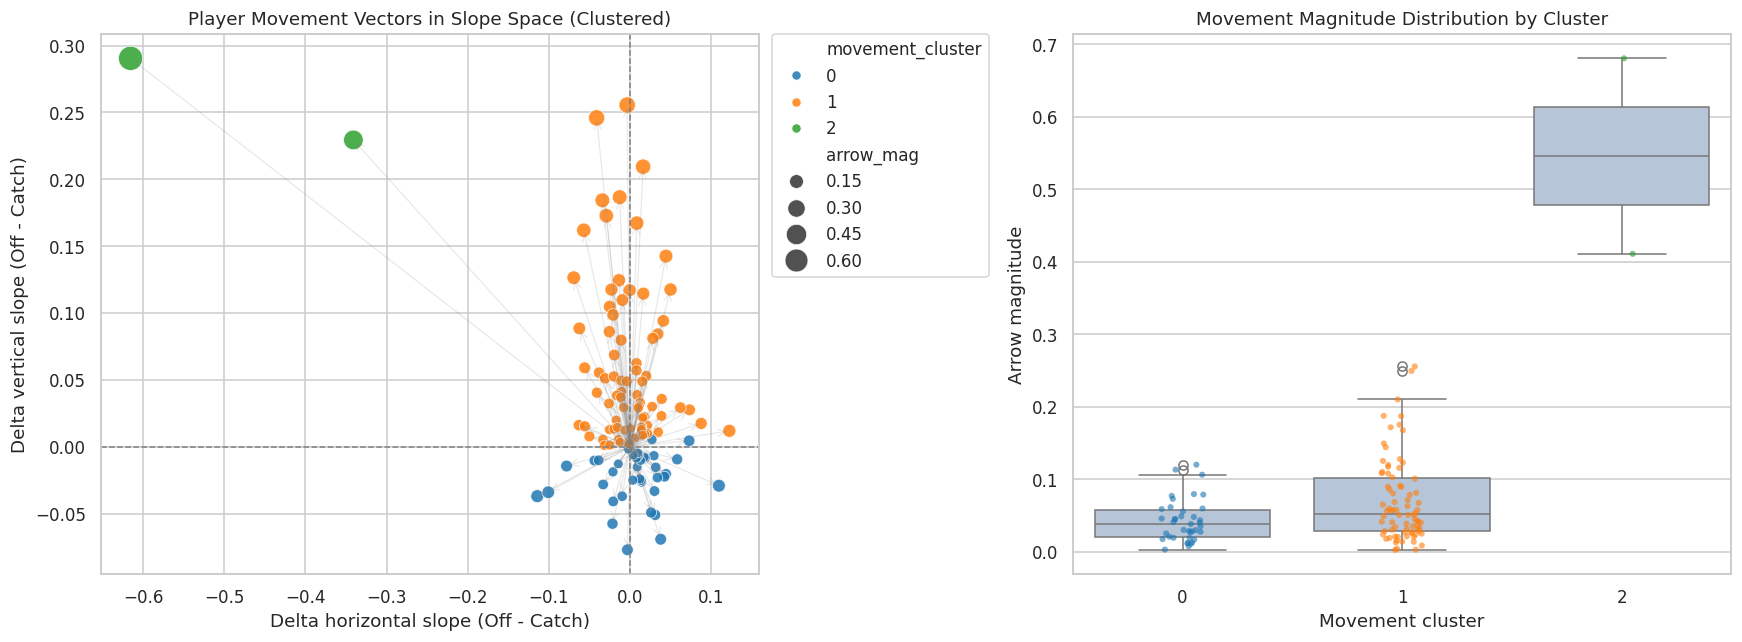

In [15]:
# -----------------------------
# Cluster players by movement angle + magnitude
# -----------------------------

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

if 'within_player_slope_movement' not in globals():
    raise ValueError('Run Section 11 first to create within_player_slope_movement.')

cluster_src = within_player_slope_movement.copy()
if cluster_src.empty:
    raise ValueError('within_player_slope_movement is empty.')

# Movement components in slope space.
dx = cluster_src['delta_horiz_slope'].astype(float).values
dy = cluster_src['delta_vert_slope'].astype(float).values
mag = cluster_src['arrow_mag'].astype(float).values
angle_deg = np.degrees(np.arctan2(dy, dx))

# Feature space uses angle + magnitude directly.
feat = pd.DataFrame({
    'angle_deg': angle_deg,
    'mag': mag,
})

X_feat = StandardScaler().fit_transform(feat[['angle_deg', 'mag']])
n_players = len(feat)

if n_players < 4:
    raise ValueError('Need at least 4 players to run stable clustering.')

k_candidates = list(range(2, min(8, n_players - 1) + 1))
sil_map = {}
for k in k_candidates:
    km_try = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels_try = km_try.fit_predict(X_feat)
    sil_map[k] = silhouette_score(X_feat, labels_try)

best_k = max(sil_map, key=sil_map.get)
km = KMeans(n_clusters=best_k, random_state=42, n_init=20)
cluster_src['movement_cluster'] = km.fit_predict(X_feat)
cluster_src['angle_deg'] = angle_deg

cluster_summary = (
    cluster_src.groupby('movement_cluster', observed=False)
    .agg(
        n_players=('player', 'size'),
        mean_mag=('arrow_mag', 'mean'),
        med_mag=('arrow_mag', 'median'),
        mean_dx=('delta_horiz_slope', 'mean'),
        mean_dy=('delta_vert_slope', 'mean'),
        mean_angle_deg=('angle_deg', 'mean'),
    )
    .sort_values('mean_mag', ascending=False)
    .reset_index()
 )

print('Movement-angle clustering results')
print('Players clustered:', n_players)
print('Best k by silhouette:', best_k)
print('Silhouette scores by k:')
for k in sorted(sil_map):
    print('  k =', k, '->', round(float(sil_map[k]), 4))
print()
print('Cluster summary:')
print(cluster_summary.round(4).to_string(index=False))

print()
print('Sample players per cluster (top 8 by magnitude):')
for c in sorted(cluster_src['movement_cluster'].unique()):
    sub = cluster_src[cluster_src['movement_cluster'] == c].copy()
    sub = sub.sort_values('arrow_mag', ascending=False)
    print()
    print(f'Cluster {c}:')
    print(
        sub[['player', 'n_catch', 'n_off', 'angle_deg', 'delta_horiz_slope', 'delta_vert_slope', 'arrow_mag', 'delta_make']]
        .head(8)
        .round(4)
        .to_string(index=False)
    )

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(
    data=cluster_src,
    x='delta_horiz_slope',
    y='delta_vert_slope',
    hue='movement_cluster',
    size='arrow_mag',
    sizes=(35, 250),
    palette='tab10',
    alpha=0.85,
    ax=axes[0],
)
axes[0].axvline(0, linestyle='--', linewidth=1, color='gray')
axes[0].axhline(0, linestyle='--', linewidth=1, color='gray')
axes[0].set_title('Player Movement Vectors in Slope Space (Clustered)')
axes[0].set_xlabel('Delta horizontal slope (Off - Catch)')
axes[0].set_ylabel('Delta vertical slope (Off - Catch)')

for _, r in cluster_src.iterrows():
    axes[0].annotate(
        '',
        xy=(r['delta_horiz_slope'], r['delta_vert_slope']),
        xytext=(0, 0),
        arrowprops={'arrowstyle': '->', 'alpha': 0.18, 'lw': 0.8, 'color': 'gray'},
    )

sns.boxplot(
    data=cluster_src,
    x='movement_cluster',
    y='arrow_mag',
    color='lightsteelblue',
    ax=axes[1],
)
sns.stripplot(
    data=cluster_src,
    x='movement_cluster',
    y='arrow_mag',
    hue='movement_cluster',
    palette='tab10',
    dodge=False,
    alpha=0.6,
    size=4,
    ax=axes[1],
)
axes[1].set_title('Movement Magnitude Distribution by Cluster')
axes[1].set_xlabel('Movement cluster')
axes[1].set_ylabel('Arrow magnitude')
if axes[1].legend_ is not None:
    axes[1].legend_.remove()

sns.move_legend(axes[0], 'upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)
plt.tight_layout()
plt.show()

movement_clustered_players = cluster_src.copy()
movement_cluster_summary = cluster_summary.copy()
movement_cluster_silhouette = sil_map.copy()

## Section 13: General Trend from Catch-and-Shoot to Off-the-Dribble

Summarize the overall cross-player trend in slope-space movement from catch-and-shoot to off-the-dribble.

Key outputs:
- Mean and median shift in horizontal, vertical, and total slope
- Weighted and unweighted trend estimates
- Bootstrap 95% confidence intervals for mean shifts
- Directional breakdown of player movements
- Relationship between slope shift and make-rate shift

General trend summary across players
Players included: 121

Central tendency and uncertainty:
                              metric  mean_unweighted  mean_weighted_by_shots  median  pct_positive  boot95_lo  boot95_hi
Horizontal slope shift (Off - Catch)          -0.0072                 -0.0011  0.0006          51.2    -0.0215     0.0044
  Vertical slope shift (Off - Catch)           0.0359                  0.0149  0.0145          69.4     0.0242     0.0490
     Total slope shift (Off - Catch)           0.0216                  0.0100  0.0155          69.4     0.0119     0.0310
       Make-rate shift (Off - Catch)           0.0730                  0.0582  0.0647          76.9     0.0498     0.0945

Directional breakdown (delta_horiz_slope, delta_vert_slope):
  (+,+): 38 | (-,+): 46 | (-,-): 13 | (+,-): 24

Trend relationships:
  corr(arrow magnitude, make-rate shift) = 0.0621
  corr(total slope shift, make-rate shift) = 0.078

Largest slope-space movers (top 10 by arrow magnitude):
    pl

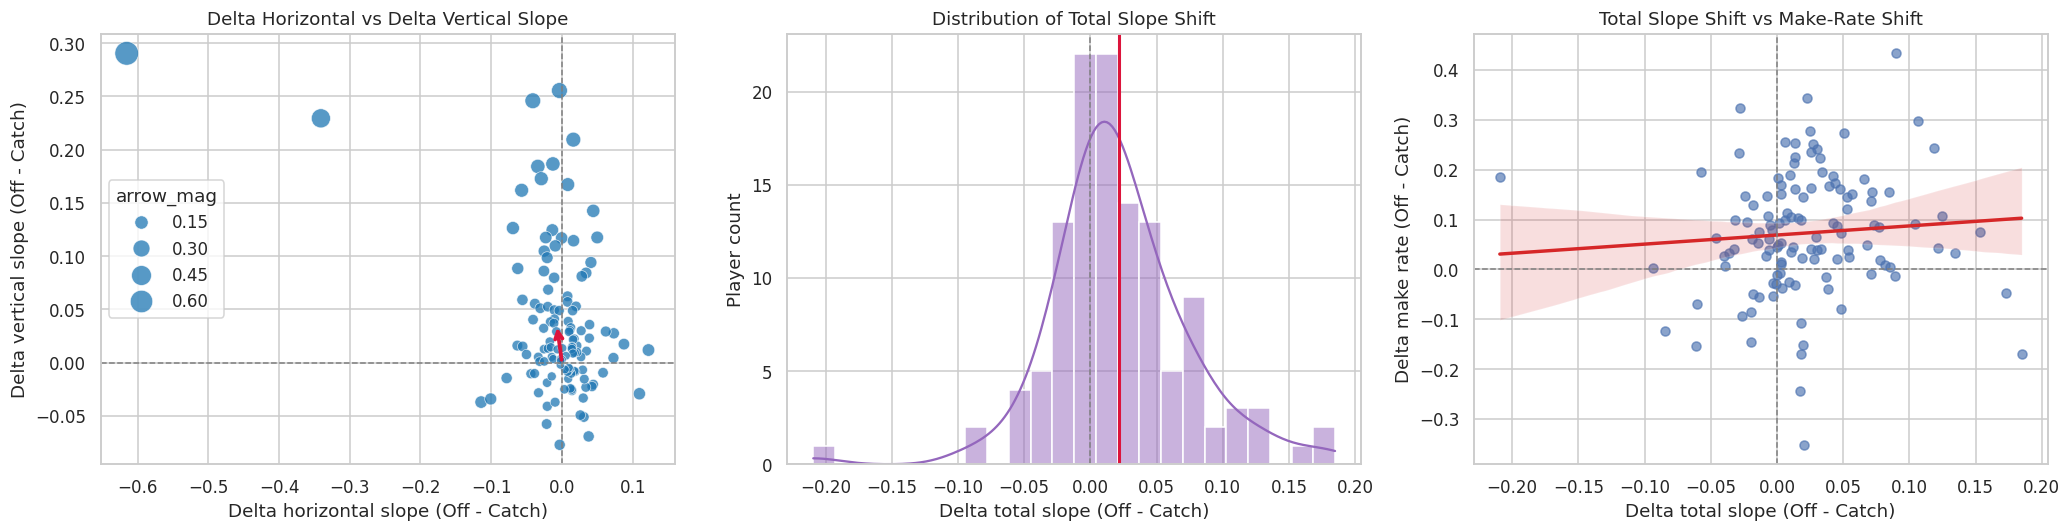

In [16]:
# -----------------------------
# General trend summary: Catch-and-Shoot -> Off-the-Dribble
# -----------------------------

if 'within_player_slope_movement' not in globals():
    raise ValueError('Run Section 11 first to create within_player_slope_movement.')

trend = within_player_slope_movement.copy()
if trend.empty:
    raise ValueError('within_player_slope_movement is empty.')

# Optional shot-volume weights.
trend['w_shots'] = trend['n_catch'].astype(float) + trend['n_off'].astype(float)

def bootstrap_ci_mean(values, n_boot=3000, alpha=0.05, seed=42):
    rng = np.random.default_rng(seed)
    vals = np.asarray(values, dtype=float)
    boots = []
    n = len(vals)
    for _ in range(n_boot):
        samp = rng.choice(vals, size=n, replace=True)
        boots.append(np.mean(samp))
    lo = np.quantile(boots, alpha / 2)
    hi = np.quantile(boots, 1 - alpha / 2)
    return float(lo), float(hi)

metrics = [
    ('delta_horiz_slope', 'Horizontal slope shift (Off - Catch)'),
    ('delta_vert_slope', 'Vertical slope shift (Off - Catch)'),
    ('delta_total_slope', 'Total slope shift (Off - Catch)'),
    ('delta_make', 'Make-rate shift (Off - Catch)'),
]

print('General trend summary across players')
print('Players included:', len(trend))
print()

summary_rows = []
for col, label in metrics:
    vals = trend[col].astype(float).values
    mean_u = float(np.mean(vals))
    med = float(np.median(vals))
    mean_w = float(np.average(vals, weights=trend['w_shots']))
    pct_pos = float((vals > 0).mean())
    ci_lo, ci_hi = bootstrap_ci_mean(vals)
    summary_rows.append({
        'metric': label,
        'mean_unweighted': mean_u,
        'mean_weighted_by_shots': mean_w,
        'median': med,
        'pct_positive': pct_pos,
        'boot95_lo': ci_lo,
        'boot95_hi': ci_hi,
    })

trend_summary = pd.DataFrame(summary_rows)
print('Central tendency and uncertainty:')
print(
    trend_summary.assign(
        pct_positive=lambda d: (100 * d['pct_positive']).round(1)
    )
    .round(4)
    .to_string(index=False)
 )

# Directional movement breakdown in slope-space deltas.
q1 = ((trend['delta_horiz_slope'] >= 0) & (trend['delta_vert_slope'] >= 0)).sum()
q2 = ((trend['delta_horiz_slope'] < 0) & (trend['delta_vert_slope'] >= 0)).sum()
q3 = ((trend['delta_horiz_slope'] < 0) & (trend['delta_vert_slope'] < 0)).sum()
q4 = ((trend['delta_horiz_slope'] >= 0) & (trend['delta_vert_slope'] < 0)).sum()

print()
print('Directional breakdown (delta_horiz_slope, delta_vert_slope):')
print('  (+,+):', int(q1), '| (-,+):', int(q2), '| (-,-):', int(q3), '| (+,-):', int(q4))

# Relationship between slope-shift magnitude and make-rate change.
corr_mag_make = float(trend[['arrow_mag', 'delta_make']].corr().iloc[0, 1])
corr_total_make = float(trend[['delta_total_slope', 'delta_make']].corr().iloc[0, 1])
print()
print('Trend relationships:')
print('  corr(arrow magnitude, make-rate shift) =', round(corr_mag_make, 4))
print('  corr(total slope shift, make-rate shift) =', round(corr_total_make, 4))

# Largest directional movers.
print()
print('Largest slope-space movers (top 10 by arrow magnitude):')
print(
    trend[['player', 'n_catch', 'n_off', 'delta_horiz_slope', 'delta_vert_slope', 'delta_total_slope', 'delta_make', 'arrow_mag']]
    .sort_values('arrow_mag', ascending=False)
    .head(10)
    .round(4)
    .to_string(index=False)
 )

fig, axes = plt.subplots(1, 3, figsize=(19, 5))

# 1) Delta horizontal vs delta vertical with mean vector.
sns.scatterplot(
    data=trend,
    x='delta_horiz_slope',
    y='delta_vert_slope',
    size='arrow_mag',
    sizes=(30, 240),
    alpha=0.75,
    color='tab:blue',
    ax=axes[0],
)
axes[0].axvline(0, linestyle='--', linewidth=1, color='gray')
axes[0].axhline(0, linestyle='--', linewidth=1, color='gray')
mean_dx = float(trend['delta_horiz_slope'].mean())
mean_dy = float(trend['delta_vert_slope'].mean())
axes[0].annotate(
    '',
    xy=(mean_dx, mean_dy),
    xytext=(0, 0),
    arrowprops={'arrowstyle': '->', 'color': 'crimson', 'lw': 2.5},
)
axes[0].set_title('Delta Horizontal vs Delta Vertical Slope')
axes[0].set_xlabel('Delta horizontal slope (Off - Catch)')
axes[0].set_ylabel('Delta vertical slope (Off - Catch)')

# 2) Total slope shift distribution.
sns.histplot(trend['delta_total_slope'], bins=24, kde=True, color='tab:purple', ax=axes[1])
axes[1].axvline(0, linestyle='--', linewidth=1, color='gray')
axes[1].axvline(trend['delta_total_slope'].mean(), linestyle='-', linewidth=2, color='crimson')
axes[1].set_title('Distribution of Total Slope Shift')
axes[1].set_xlabel('Delta total slope (Off - Catch)')
axes[1].set_ylabel('Player count')

# 3) Total slope shift vs make-rate shift.
sns.regplot(
    data=trend,
    x='delta_total_slope',
    y='delta_make',
    scatter_kws={'alpha': 0.65, 's': 35},
    line_kws={'color': 'tab:red'},
    ax=axes[2],
)
axes[2].axvline(0, linestyle='--', linewidth=1, color='gray')
axes[2].axhline(0, linestyle='--', linewidth=1, color='gray')
axes[2].set_title('Total Slope Shift vs Make-Rate Shift')
axes[2].set_xlabel('Delta total slope (Off - Catch)')
axes[2].set_ylabel('Delta make rate (Off - Catch)')

plt.tight_layout()
plt.show()

general_trend_summary = trend_summary.copy()

## Section 14: Does Movement Magnitude Relate to Make-Rate Disparity?

Test whether players with larger slope-space movement magnitude (`arrow_mag`) also show larger make-rate differences between catch-and-shoot and off-the-dribble.

This section evaluates association with:
- Signed make-rate difference: `delta_make = make_off - make_catch`
- Absolute make-rate disparity: `abs_delta_make = |delta_make|`

Association between movement (magnitude + direction) and make-rate gap
Players: 121

Magnitude-only relationships:
Signed gap: delta_make = make_off - make_catch
  Pearson corr : 0.0621
  Spearman corr: 0.1335
  OLS slope    : 0.0932 (delta_make per 1.0 arrow_mag)

Absolute disparity: abs_delta_make = |make_off - make_catch|
  Pearson corr : 0.0469
  Spearman corr: 0.0858
  OLS slope    : 0.0504 (abs_delta_make per 1.0 arrow_mag)

Direction-only component correlations (Pearson):
  corr(dir_x, delta_make)      = 0.1155
  corr(dir_y, delta_make)      = 0.0802
  corr(dir_x, abs_delta_make)  = 0.1659
  corr(dir_y, abs_delta_make)  = 0.0564

Combined linear model: target ~ arrow_mag + dir_x + dir_y
  Signed target R^2  = 0.0277
  Coefs [intercept, mag, dir_x, dir_y] = [0.0594, 0.1051, 0.0268, 0.0153]
  Absolute target R^2= 0.0387
  Coefs [intercept, mag, dir_x, dir_y] = [0.1033, 0.0734, 0.0256, 0.0089]

Quartile trend by movement magnitude:
mag_quartile  n_players  mean_arrow_mag  mean_delt

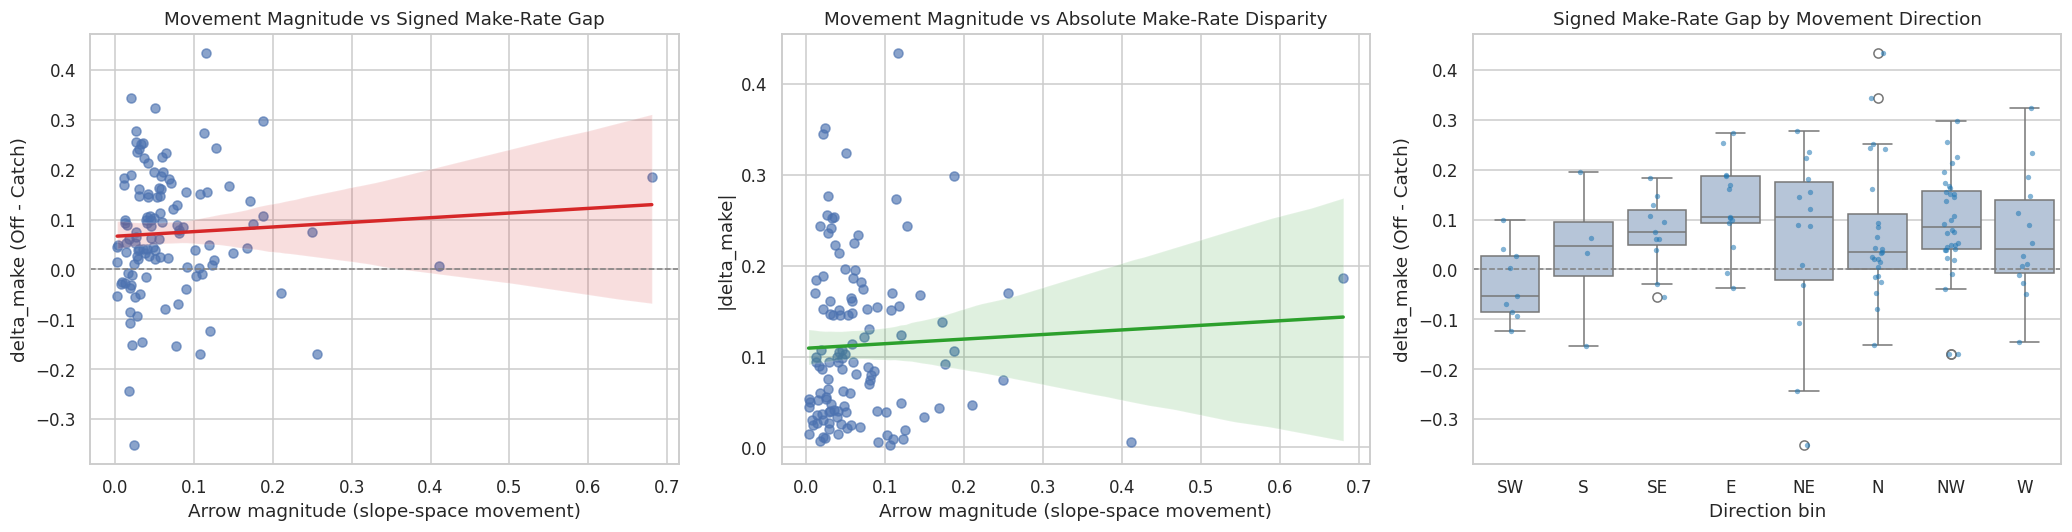

In [17]:
# -----------------------------
# Magnitude + direction vs make-rate disparity
# -----------------------------

if 'within_player_slope_movement' not in globals():
    raise ValueError('Run Section 11 first to create within_player_slope_movement.')

disp = within_player_slope_movement.copy()
if disp.empty:
    raise ValueError('within_player_slope_movement is empty.')

disp['abs_delta_make'] = disp['delta_make'].abs()
disp['angle_deg'] = np.degrees(np.arctan2(disp['delta_vert_slope'], disp['delta_horiz_slope']))
disp['angle_rad'] = np.radians(disp['angle_deg'])
disp['dir_x'] = np.cos(disp['angle_rad'])
disp['dir_y'] = np.sin(disp['angle_rad'])

# Direction bins for interpretability.
dir_edges = [-180, -135, -90, -45, 0, 45, 90, 135, 180]
dir_labels = ['SW', 'S', 'SE', 'E', 'NE', 'N', 'NW', 'W']
disp['direction_bin'] = pd.cut(
    disp['angle_deg'], bins=dir_edges, labels=dir_labels, include_lowest=True
)

pearson_signed = float(disp[['arrow_mag', 'delta_make']].corr(method='pearson').iloc[0, 1])
spearman_signed = float(disp[['arrow_mag', 'delta_make']].corr(method='spearman').iloc[0, 1])
pearson_abs = float(disp[['arrow_mag', 'abs_delta_make']].corr(method='pearson').iloc[0, 1])
spearman_abs = float(disp[['arrow_mag', 'abs_delta_make']].corr(method='spearman').iloc[0, 1])

# Directional component association with make-rate gap.
corr_dirx_signed = float(disp[['dir_x', 'delta_make']].corr(method='pearson').iloc[0, 1])
corr_diry_signed = float(disp[['dir_y', 'delta_make']].corr(method='pearson').iloc[0, 1])
corr_dirx_abs = float(disp[['dir_x', 'abs_delta_make']].corr(method='pearson').iloc[0, 1])
corr_diry_abs = float(disp[['dir_y', 'abs_delta_make']].corr(method='pearson').iloc[0, 1])

# Simple slope estimates for interpretation (magnitude-only).
beta_signed, _ = np.polyfit(disp['arrow_mag'], disp['delta_make'], 1)
beta_abs, _ = np.polyfit(disp['arrow_mag'], disp['abs_delta_make'], 1)

# Multivariate linear fit: target ~ magnitude + direction components.
X = np.column_stack([np.ones(len(disp)), disp['arrow_mag'].values, disp['dir_x'].values, disp['dir_y'].values])
y_signed = disp['delta_make'].values
y_abs = disp['abs_delta_make'].values
coef_signed = np.linalg.lstsq(X, y_signed, rcond=None)[0]
coef_abs = np.linalg.lstsq(X, y_abs, rcond=None)[0]
pred_signed = X @ coef_signed
pred_abs = X @ coef_abs
r2_signed = 1 - np.sum((y_signed - pred_signed) ** 2) / np.sum((y_signed - y_signed.mean()) ** 2)
r2_abs = 1 - np.sum((y_abs - pred_abs) ** 2) / np.sum((y_abs - y_abs.mean()) ** 2)

print('Association between movement (magnitude + direction) and make-rate gap')
print('Players:', len(disp))
print()
print('Magnitude-only relationships:')
print('Signed gap: delta_make = make_off - make_catch')
print('  Pearson corr :', round(pearson_signed, 4))
print('  Spearman corr:', round(spearman_signed, 4))
print('  OLS slope    :', round(float(beta_signed), 4), '(delta_make per 1.0 arrow_mag)')
print()
print('Absolute disparity: abs_delta_make = |make_off - make_catch|')
print('  Pearson corr :', round(pearson_abs, 4))
print('  Spearman corr:', round(spearman_abs, 4))
print('  OLS slope    :', round(float(beta_abs), 4), '(abs_delta_make per 1.0 arrow_mag)')
print()
print('Direction-only component correlations (Pearson):')
print('  corr(dir_x, delta_make)      =', round(corr_dirx_signed, 4))
print('  corr(dir_y, delta_make)      =', round(corr_diry_signed, 4))
print('  corr(dir_x, abs_delta_make)  =', round(corr_dirx_abs, 4))
print('  corr(dir_y, abs_delta_make)  =', round(corr_diry_abs, 4))
print()
print('Combined linear model: target ~ arrow_mag + dir_x + dir_y')
print('  Signed target R^2  =', round(float(r2_signed), 4))
print('  Coefs [intercept, mag, dir_x, dir_y] =', np.round(coef_signed, 4).tolist())
print('  Absolute target R^2=', round(float(r2_abs), 4))
print('  Coefs [intercept, mag, dir_x, dir_y] =', np.round(coef_abs, 4).tolist())

# Quartile trend for an intuitive monotonic check.
disp['mag_quartile'] = pd.qcut(disp['arrow_mag'], q=4, labels=['Q1_small', 'Q2', 'Q3', 'Q4_large'])
quart = (
    disp.groupby('mag_quartile', observed=False)
    .agg(
        n_players=('player', 'size'),
        mean_arrow_mag=('arrow_mag', 'mean'),
        mean_delta_make=('delta_make', 'mean'),
        mean_abs_delta_make=('abs_delta_make', 'mean'),
    )
    .reset_index()
)

# Direction-bin summary.
direction_summary = (
    disp.groupby('direction_bin', observed=False)
    .agg(
        n_players=('player', 'size'),
        mean_arrow_mag=('arrow_mag', 'mean'),
        mean_delta_make=('delta_make', 'mean'),
        mean_abs_delta_make=('abs_delta_make', 'mean'),
    )
    .reset_index()
)

print()
print('Quartile trend by movement magnitude:')
print(quart.round(4).to_string(index=False))
print()
print('Direction-bin trend:')
print(direction_summary.round(4).to_string(index=False))

# Player examples within each bin for interpretation.
EXAMPLES_PER_BIN = 5
example_cols = [
    'player', 'arrow_mag', 'delta_make', 'abs_delta_make',
    'delta_horiz_slope', 'delta_vert_slope', 'angle_deg', 'direction_bin'
]

print()
print(f'Example players by magnitude quartile (top {EXAMPLES_PER_BIN} by abs_delta_make):')
for q in ['Q1_small', 'Q2', 'Q3', 'Q4_large']:
    sub_q = disp[disp['mag_quartile'] == q].copy()
    if sub_q.empty:
        continue
    sub_q = sub_q.sort_values(['abs_delta_make', 'arrow_mag'], ascending=[False, False]).head(EXAMPLES_PER_BIN)
    print()
    print(f'{q}:')
    print(sub_q[example_cols].round(4).to_string(index=False))

print()
print(f'Example players by direction bin (top {EXAMPLES_PER_BIN} by abs_delta_make):')
for d in dir_labels:
    sub_d = disp[disp['direction_bin'] == d].copy()
    if sub_d.empty:
        continue
    sub_d = sub_d.sort_values(['abs_delta_make', 'arrow_mag'], ascending=[False, False]).head(EXAMPLES_PER_BIN)
    print()
    print(f'{d}:')
    print(sub_d[example_cols].round(4).to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(19, 5))

sns.regplot(
    data=disp,
    x='arrow_mag',
    y='delta_make',
    scatter_kws={'alpha': 0.65, 's': 35},
    line_kws={'color': 'tab:red'},
    ax=axes[0],
)
axes[0].axhline(0, linestyle='--', linewidth=1, color='gray')
axes[0].set_title('Movement Magnitude vs Signed Make-Rate Gap')
axes[0].set_xlabel('Arrow magnitude (slope-space movement)')
axes[0].set_ylabel('delta_make (Off - Catch)')

sns.regplot(
    data=disp,
    x='arrow_mag',
    y='abs_delta_make',
    scatter_kws={'alpha': 0.65, 's': 35},
    line_kws={'color': 'tab:green'},
    ax=axes[1],
)
axes[1].set_title('Movement Magnitude vs Absolute Make-Rate Disparity')
axes[1].set_xlabel('Arrow magnitude (slope-space movement)')
axes[1].set_ylabel('|delta_make|')

sns.boxplot(data=disp, x='direction_bin', y='delta_make', color='lightsteelblue', ax=axes[2])
sns.stripplot(
    data=disp, x='direction_bin', y='delta_make',
    color='tab:blue', alpha=0.55, size=3.5, ax=axes[2]
)
axes[2].axhline(0, linestyle='--', linewidth=1, color='gray')
axes[2].set_title('Signed Make-Rate Gap by Movement Direction')
axes[2].set_xlabel('Direction bin')
axes[2].set_ylabel('delta_make (Off - Catch)')

plt.tight_layout()
plt.show()

magnitude_disparity_stats = {
    'pearson_signed': pearson_signed,
    'spearman_signed': spearman_signed,
    'pearson_abs': pearson_abs,
    'spearman_abs': spearman_abs,
    'slope_signed': float(beta_signed),
    'slope_abs': float(beta_abs),
    'corr_dirx_signed': corr_dirx_signed,
    'corr_diry_signed': corr_diry_signed,
    'corr_dirx_abs': corr_dirx_abs,
    'corr_diry_abs': corr_diry_abs,
    'r2_signed_mag_dir_model': float(r2_signed),
    'r2_abs_mag_dir_model': float(r2_abs),
}
magnitude_disparity_quartiles = quart.copy()
magnitude_disparity_direction_summary = direction_summary.copy()

### Interpreting Direction of Movement in Velocity-Slope Terms

When we talk about **direction of movement**, we are tracking the 2D vector:
- `delta_horiz_slope = horiz_slope_off - horiz_slope_catch`
- `delta_vert_slope = vert_slope_off - vert_slope_catch`

So each player's movement direction describes how their **velocity-vs-distance tuning** changes from Catch-and-Shoot to Off-the-Dribble.

Direction-bin interpretation where bins are defined (with concrete examples):
- `E` (east): higher horizontal slope, little vertical change. Example players in this bin: Player 76, Player 135, Player 127.
- `W` (west): lower horizontal slope, little vertical change. Example players in this bin: Player 161, Player 10, Player 44.
- `N` (north): higher vertical slope, little horizontal change. Example players in this bin: Player 94, Player 101, Player 51.
- `S` (south): lower vertical slope, little horizontal change. Example players in this bin: Player 63, Player 105, Player 20.
- `NE`: both horizontal and vertical slopes increase. Example players in this bin: Player 93, Player 116, Player 115.
- `NW`: horizontal slope decreases while vertical slope increases. Example players in this bin: Player 117, Player 54, Player 53.
- `SE`: horizontal slope increases while vertical slope decreases. Example players in this bin: Player 58, Player 73, Player 49.
- `SW`: both slopes decrease. Example players in this bin: Player 3, Player 48, Player 81.

Basketball interpretation of slope changes:
- Higher horizontal slope means a player's horizontal launch-speed component ramps up more per extra foot of distance.
- Higher vertical slope means a player's vertical launch-speed component ramps up more per extra foot of distance.
- Therefore, direction is a compact summary of *how* a player reallocates velocity components as shot distance grows in Off-the-Dribble compared with Catch-and-Shoot.

How this relates to Section 14 findings:
- Magnitude alone has a weak relationship with make-rate disparity.
- Direction adds some signal, but effect sizes remain modest overall.
- In this dataset, the stronger global trend is positive vertical-slope shift, while horizontal shifts are more mixed across players.

Examples included in Section 14 output:
- For each magnitude quartile (`Q1_small`, `Q2`, `Q3`, `Q4_large`), we show example players (top by absolute make-rate disparity).
- For each direction bin (`SW`, `S`, `SE`, `E`, `NE`, `N`, `NW`, `W`), we also show example players (top by absolute make-rate disparity).
- These examples make it easier to connect the aggregate bin summaries to concrete player-level movement profiles.

## Section 15: Does Launch Angle Increase Off the Dribble?

Directly test whether launch angle is generally higher for off-the-dribble shots, while accounting for shot distance.

This section includes:
- A pooled distance-controlled model: `launch_angle ~ shot_type + distance + shot_type*distance`
- A within-player distance-controlled comparison
- Visual diagnostics for launch-angle differences

Launch-angle comparison: Off-the-Dribble vs Catch-and-Shoot
Rows used (pooled): 25868
Players used (within-player): 121
Columns used -> player: Name | shot_type: Shot.Type | distance: Shot.Distance | launch_angle: Initial.Ball.Angle

Pooled distance-controlled model
  launch_angle = b0 + b1*is_off + b2*distance_c + b3*(is_off*distance_c)
  b1 (Off minus Catch at mean distance): -0.5137 degrees
  95% CI for b1: (-0.611, -0.4165)
  b3 (difference in angle-vs-distance slope): -0.1043 deg per foot
  Model R^2: 0.1931

Mixed-effects model with player random intercept
  Fixed effect is_off (Off minus Catch): -0.6963 degrees
  95% CI: (-0.7865, -0.6062)
  Random-intercept variance (player): 6.3713
  Converged: True

Raw means (not distance controlled)
  Catch mean angle: 46.1323
  Off mean angle  : 46.8247
  Raw Off-Catch   : 0.6924 degrees

Within-player distance-controlled summary (at global mean distance)
  Mean Off-Catch delta : -1.1271 degrees
  Median Off-Catch delta: -0.8044 degrees
  

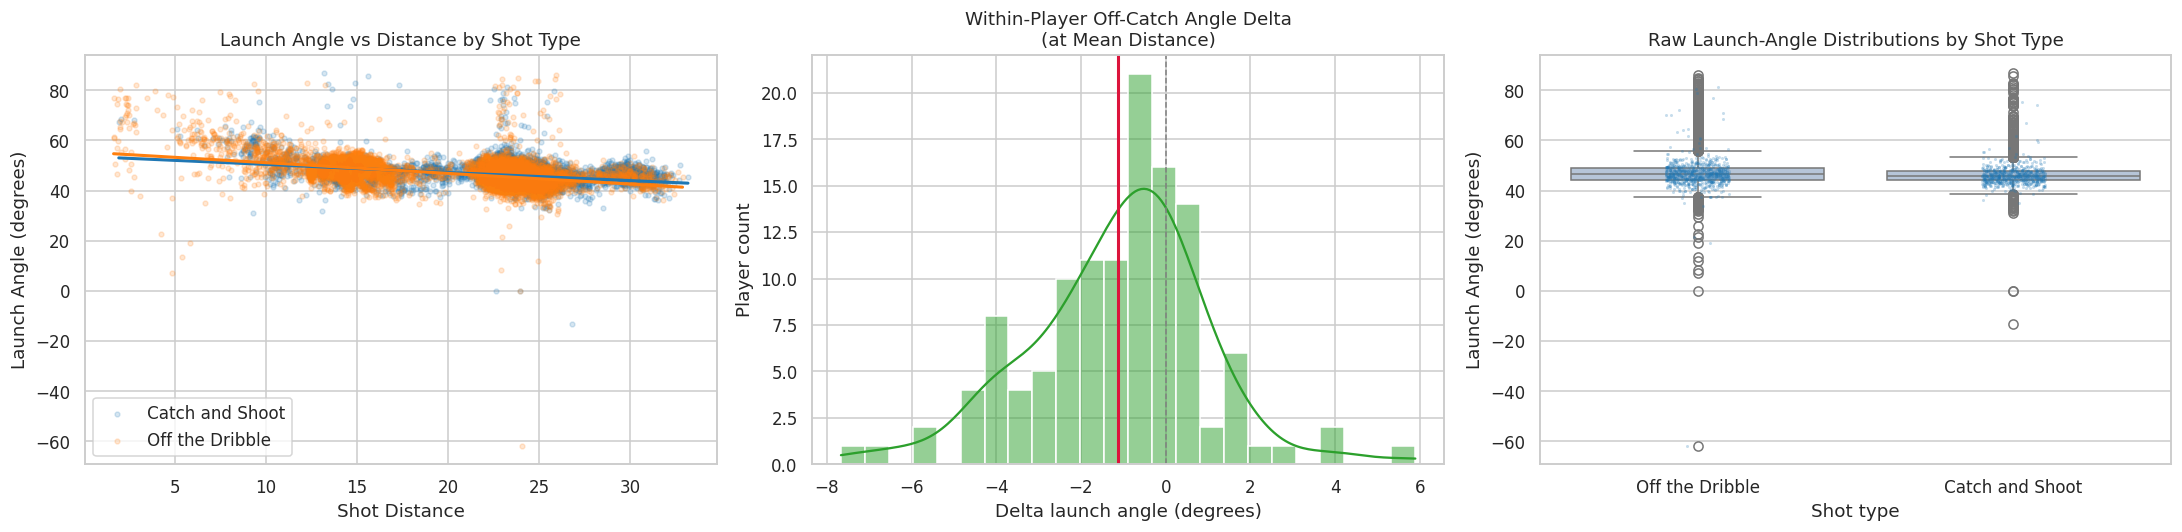

In [18]:
# -----------------------------
# Launch-angle test: Off-the-Dribble vs Catch-and-Shoot (distance-controlled)
# -----------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Make this section robust if run in a fresh kernel.
if 'df' not in globals():
    data_path_fallback = '../capstone2026v2.csv'
    data_path_use = DATA_PATH if 'DATA_PATH' in globals() else data_path_fallback
    df = pd.read_csv(data_path_use)

MIN_SHOTS_PER_TYPE_ANGLE = 15
CATCH_LABEL_ANGLE = 'Catch and Shoot'
OFF_LABEL_ANGLE = 'Off the Dribble'

PLAYER_COL_CANDIDATES = ['Name', 'Player', 'player', 'PlayerName']
SHOT_TYPE_COL_CANDIDATES = ['Shot.Type', 'Shot Type', 'ShotType']
DIST_COL_CANDIDATES = ['Shot.Distance', 'Shot Distance', 'Shot_Distance']
ANGLE_COL_CANDIDATES = ['Initial.Ball.Angle', 'Initial Ball Angle', 'Launch.Angle']

def pick_col(candidates, columns):
    return next((c for c in candidates if c in columns), None)

player_col_ang = pick_col(PLAYER_COL_CANDIDATES, df.columns)
shot_type_col_ang = pick_col(SHOT_TYPE_COL_CANDIDATES, df.columns)
dist_col_ang = pick_col(DIST_COL_CANDIDATES, df.columns)
angle_col_ang = pick_col(ANGLE_COL_CANDIDATES, df.columns)

required_cols_ang = [player_col_ang, shot_type_col_ang, dist_col_ang, angle_col_ang]
if any(c is None for c in required_cols_ang):
    raise ValueError(
        'Missing required columns for launch-angle analysis. Found: ' + str(required_cols_ang)
    )

ang = df[required_cols_ang].copy()
ang = ang[ang[shot_type_col_ang].isin([CATCH_LABEL_ANGLE, OFF_LABEL_ANGLE])].copy()
ang = ang.dropna(subset=[player_col_ang, shot_type_col_ang, dist_col_ang, angle_col_ang]).copy()
ang['distance'] = ang[dist_col_ang].astype(float)
ang['launch_angle'] = ang[angle_col_ang].astype(float)
ang['is_off'] = (ang[shot_type_col_ang] == OFF_LABEL_ANGLE).astype(int)

# Center distance so the shot-type coefficient is interpretable at mean distance.
dist_mean_all = float(ang['distance'].mean())
ang['distance_c'] = ang['distance'] - dist_mean_all
ang['off_x_distance_c'] = ang['is_off'] * ang['distance_c']

# Pooled OLS: launch_angle ~ intercept + is_off + distance_c + is_off*distance_c
X_pool = np.column_stack([
    np.ones(len(ang)),
    ang['is_off'].values,
    ang['distance_c'].values,
    ang['off_x_distance_c'].values,
])
y_pool = ang['launch_angle'].values
coef_pool = np.linalg.lstsq(X_pool, y_pool, rcond=None)[0]
pred_pool = X_pool @ coef_pool
rss_pool = float(np.sum((y_pool - pred_pool) ** 2))
tss_pool = float(np.sum((y_pool - y_pool.mean()) ** 2))
r2_pool = 1 - rss_pool / tss_pool if tss_pool > 0 else np.nan

intercept_pool, beta_off, beta_dist, beta_off_dist = coef_pool

# Approximate standard errors from OLS normal equations.
n_pool = len(ang)
p_pool = X_pool.shape[1]
sigma2 = rss_pool / max(n_pool - p_pool, 1)
xtx_inv = np.linalg.pinv(X_pool.T @ X_pool)
se = np.sqrt(np.diag(sigma2 * xtx_inv))
se_off = float(se[1])
ci_off_lo = float(beta_off - 1.96 * se_off)
ci_off_hi = float(beta_off + 1.96 * se_off)

# Mixed-effects model with player random intercept.
beta_off_mixed = np.nan
ci_off_mixed_lo = np.nan
ci_off_mixed_hi = np.nan
mixed_re_var = np.nan
mixed_converged = False
mixed_error = None
try:
    import statsmodels.formula.api as smf
    ang['player_group'] = ang[player_col_ang].astype(str)
    mixed_model = smf.mixedlm(
        'launch_angle ~ is_off + distance_c + off_x_distance_c',
        data=ang,
        groups=ang['player_group'],
    )
    mixed_res = mixed_model.fit(reml=False, method='lbfgs', maxiter=300, disp=False)
    beta_off_mixed = float(mixed_res.params['is_off'])
    ci_off_mixed_lo = float(mixed_res.conf_int().loc['is_off', 0])
    ci_off_mixed_hi = float(mixed_res.conf_int().loc['is_off', 1])
    mixed_re_var = float(mixed_res.cov_re.iloc[0, 0])
    mixed_converged = bool(mixed_res.converged)
except Exception as e:
    mixed_error = str(e)

# Raw (uncontrolled) difference for context.
raw_means = ang.groupby('is_off', observed=False)['launch_angle'].mean()
mean_catch_raw = float(raw_means.get(0, np.nan))
mean_off_raw = float(raw_means.get(1, np.nan))
raw_diff = mean_off_raw - mean_catch_raw

# Within-player distance-controlled comparison.
rows = []
for player_name, g in ang.groupby(player_col_ang, observed=False):
    g_c = g[g['is_off'] == 0].copy()
    g_o = g[g['is_off'] == 1].copy()
    if len(g_c) < MIN_SHOTS_PER_TYPE_ANGLE or len(g_o) < MIN_SHOTS_PER_TYPE_ANGLE:
        continue
    if float(g_c['distance'].std()) < 1e-8 or float(g_o['distance'].std()) < 1e-8:
        continue

    slope_c, intercept_c = np.polyfit(g_c['distance'], g_c['launch_angle'], 1)
    slope_o, intercept_o = np.polyfit(g_o['distance'], g_o['launch_angle'], 1)

    # Compare each player's predicted launch angle at the global mean distance.
    angle_c_at_mean = intercept_c + slope_c * dist_mean_all
    angle_o_at_mean = intercept_o + slope_o * dist_mean_all

    rows.append({
        'player': player_name,
        'n_catch': int(len(g_c)),
        'n_off': int(len(g_o)),
        'slope_catch': float(slope_c),
        'slope_off': float(slope_o),
        'delta_slope_off_minus_catch': float(slope_o - slope_c),
        'angle_catch_at_mean_dist': float(angle_c_at_mean),
        'angle_off_at_mean_dist': float(angle_o_at_mean),
        'delta_angle_at_mean_dist': float(angle_o_at_mean - angle_c_at_mean),
        'raw_mean_angle_catch': float(g_c['launch_angle'].mean()),
        'raw_mean_angle_off': float(g_o['launch_angle'].mean()),
        'raw_delta_angle': float(g_o['launch_angle'].mean() - g_c['launch_angle'].mean()),
    })

within_angle = pd.DataFrame(rows)
if within_angle.empty:
    raise ValueError(
        f'No players meet minimum per-type shot threshold ({MIN_SHOTS_PER_TYPE_ANGLE}) for launch-angle comparison.'
    )

mean_delta_at_mean = float(within_angle['delta_angle_at_mean_dist'].mean())
med_delta_at_mean = float(within_angle['delta_angle_at_mean_dist'].median())
pct_players_higher_off = float((within_angle['delta_angle_at_mean_dist'] > 0).mean())

w = (within_angle['n_catch'] + within_angle['n_off']).astype(float).values
weighted_delta_at_mean = float(np.average(within_angle['delta_angle_at_mean_dist'], weights=w))

print('Launch-angle comparison: Off-the-Dribble vs Catch-and-Shoot')
print('Rows used (pooled):', len(ang))
print('Players used (within-player):', len(within_angle))
print('Columns used ->',
      'player:', player_col_ang, '| shot_type:', shot_type_col_ang,
      '| distance:', dist_col_ang, '| launch_angle:', angle_col_ang)
print()
print('Pooled distance-controlled model')
print('  launch_angle = b0 + b1*is_off + b2*distance_c + b3*(is_off*distance_c)')
print('  b1 (Off minus Catch at mean distance):', round(float(beta_off), 4), 'degrees')
print('  95% CI for b1:', (round(ci_off_lo, 4), round(ci_off_hi, 4)))
print('  b3 (difference in angle-vs-distance slope):', round(float(beta_off_dist), 4), 'deg per foot')
print('  Model R^2:', round(float(r2_pool), 4))
print()
print('Mixed-effects model with player random intercept')
if np.isfinite(beta_off_mixed):
    print('  Fixed effect is_off (Off minus Catch):', round(float(beta_off_mixed), 4), 'degrees')
    print('  95% CI:', (round(ci_off_mixed_lo, 4), round(ci_off_mixed_hi, 4)))
    print('  Random-intercept variance (player):', round(float(mixed_re_var), 4))
    print('  Converged:', mixed_converged)
else:
    print('  Mixed model unavailable in this run.')
    print('  Reason:', mixed_error)
print()
print('Raw means (not distance controlled)')
print('  Catch mean angle:', round(mean_catch_raw, 4))
print('  Off mean angle  :', round(mean_off_raw, 4))
print('  Raw Off-Catch   :', round(raw_diff, 4), 'degrees')
print()
print('Within-player distance-controlled summary (at global mean distance)')
print('  Mean Off-Catch delta :', round(mean_delta_at_mean, 4), 'degrees')
print('  Median Off-Catch delta:', round(med_delta_at_mean, 4), 'degrees')
print('  Weighted mean delta   :', round(weighted_delta_at_mean, 4), 'degrees')
print('  Pct players with Off > Catch:', round(100 * pct_players_higher_off, 1), '%')

print()
print('Top players with larger Off-the-Dribble launch angle (distance-controlled):')
print(
    within_angle[['player', 'n_catch', 'n_off', 'delta_angle_at_mean_dist', 'delta_slope_off_minus_catch']]
    .sort_values('delta_angle_at_mean_dist', ascending=False)
    .head(10)
    .round(4)
    .to_string(index=False)
)

print()
print('Top players with lower Off-the-Dribble launch angle (distance-controlled):')
print(
    within_angle[['player', 'n_catch', 'n_off', 'delta_angle_at_mean_dist', 'delta_slope_off_minus_catch']]
    .sort_values('delta_angle_at_mean_dist', ascending=True)
    .head(10)
    .round(4)
    .to_string(index=False)
)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1) Pooled scatter + per-type trend lines.
s1 = ang[ang['is_off'] == 0]
s2 = ang[ang['is_off'] == 1]
axes[0].scatter(s1['distance'], s1['launch_angle'], s=10, alpha=0.18, label='Catch and Shoot', color='tab:blue')
axes[0].scatter(s2['distance'], s2['launch_angle'], s=10, alpha=0.18, label='Off the Dribble', color='tab:orange')
sns.regplot(data=s1, x='distance', y='launch_angle', scatter=False, ci=None, line_kws={'color': 'tab:blue', 'lw': 2}, ax=axes[0])
sns.regplot(data=s2, x='distance', y='launch_angle', scatter=False, ci=None, line_kws={'color': 'tab:orange', 'lw': 2}, ax=axes[0])
axes[0].set_title('Launch Angle vs Distance by Shot Type')
axes[0].set_xlabel('Shot Distance')
axes[0].set_ylabel('Launch Angle (degrees)')
axes[0].legend()

# 2) Distribution of within-player distance-controlled differences.
sns.histplot(within_angle['delta_angle_at_mean_dist'], bins=24, kde=True, color='tab:green', ax=axes[1])
axes[1].axvline(0, linestyle='--', linewidth=1, color='gray')
axes[1].axvline(mean_delta_at_mean, linestyle='-', linewidth=2, color='crimson')
axes[1].set_title('Within-Player Off-Catch Angle Delta\n(at Mean Distance)')
axes[1].set_xlabel('Delta launch angle (degrees)')
axes[1].set_ylabel('Player count')

# 3) Boxplot by shot type for raw launch angle context.
tmp_plot = ang.copy()
tmp_plot['shot_type_label'] = np.where(tmp_plot['is_off'] == 1, 'Off the Dribble', 'Catch and Shoot')
sns.boxplot(data=tmp_plot, x='shot_type_label', y='launch_angle', color='lightsteelblue', ax=axes[2])
sns.stripplot(data=tmp_plot.sample(min(1500, len(tmp_plot)), random_state=42),
              x='shot_type_label', y='launch_angle', color='tab:blue', alpha=0.25, size=2, ax=axes[2])
axes[2].set_title('Raw Launch-Angle Distributions by Shot Type')
axes[2].set_xlabel('Shot type')
axes[2].set_ylabel('Launch Angle (degrees)')

plt.tight_layout()
plt.show()

launch_angle_trend_stats = {
    'pooled_off_minus_catch_at_mean_distance': float(beta_off),
    'pooled_off_minus_catch_ci95': (float(ci_off_lo), float(ci_off_hi)),
    'pooled_off_distance_interaction': float(beta_off_dist),
    'pooled_model_r2': float(r2_pool),
    'mixed_off_minus_catch': float(beta_off_mixed) if np.isfinite(beta_off_mixed) else np.nan,
    'mixed_off_minus_catch_ci95': (float(ci_off_mixed_lo), float(ci_off_mixed_hi)) if np.isfinite(beta_off_mixed) else (np.nan, np.nan),
    'mixed_player_random_intercept_var': float(mixed_re_var) if np.isfinite(mixed_re_var) else np.nan,
    'mixed_converged': bool(mixed_converged),
    'raw_off_minus_catch': float(raw_diff),
    'within_player_mean_delta_at_mean_distance': float(mean_delta_at_mean),
    'within_player_median_delta_at_mean_distance': float(med_delta_at_mean),
    'within_player_weighted_mean_delta_at_mean_distance': float(weighted_delta_at_mean),
    'within_player_pct_off_greater': float(pct_players_higher_off),
}
within_player_launch_angle_deltas = within_angle.copy()

## Section 16: Invert the Model to Find High-Probability Release Ranges

Use projectile-motion constraints plus the trained make-probability model to find release parameter ranges that achieve predicted make probability between 80% and 100% for a chosen distance and fixed release height.

Assumptions in this section:
- `left_right = 0` (no lateral deviation)
- Rim height is fixed at `10 ft`
- Input distance is shooter to **middle of rim**
- Depth convention is fixed to rim geometry: front rim = `0`, back rim = `18` (rim center = `9`)
- Release angle and release velocity vary within observed bounds
- Ball must be descending at the rim and must have peaked before reaching the rim
- Ball must be near rim height at rim depth (tolerance-based constraint)

In [19]:
# -----------------------------
# Inverse search for release parameters under projectile constraints
# -----------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# User controls (edit these)
DIST_TO_RIM_CENTER = 15.0   # shooter-to-rim-center distance (physics distance units)
RELEASE_HEIGHT = 8.5        # fixed release height (same vertical units as RIM_HEIGHT)
RIM_HEIGHT = 10.0           # rim height on z-axis (feet per user assumption)
LEFT_RIGHT_FIXED = 0.0
TARGET_PROB_MIN = 0.80
TARGET_PROB_MAX = 1.00

# Depth convention: front rim = 0, back rim = 18, center = 9
RIM_DEPTH_FRONT = 0.0
RIM_DEPTH_BACK = 18.0
RIM_DEPTH_CENTER = 0.5 * (RIM_DEPTH_FRONT + RIM_DEPTH_BACK)

# Convert horizontal physics displacement into Ball_Depth units.
# If physics distance is feet and Ball_Depth is inches, use 12.0.
# If already same units, set to 1.0.
DIST_TO_DEPTH_UNITS = 12.0

# Physics/search controls
G = 32.174                  # ft/s^2
RIM_HEIGHT_TOL = 0.30       # tolerance around rim height at x=distance
N_ANGLE_GRID = 180
N_SPEED_GRID = 180

# Convert physics-derived rim speed units to model Ball_Velocity units.
# If release-speed physics is in ft/s and model Ball_Velocity is m/s, use 0.3048.
# If both are already same units, set to 1.0.
VEL_TO_MODEL_UNITS = 0.3048

PLAYER_COL_CANDIDATES = ['Name', 'Player', 'player', 'PlayerName']
ANGLE_COL_CANDIDATES = ['Initial.Ball.Angle', 'Initial Ball Angle', 'Launch.Angle']
TOTAL_VEL_COL_CANDIDATES = ['Initial.Ball.Velocity', 'Initial Ball Velocity', 'Launch.Velocity']

def pick_col(candidates, columns):
    return next((c for c in candidates if c in columns), None)

# Ensure model exists; if not, rebuild it with the current depth/left_right setup used in Sections 2-3.
if 'clf' not in globals() or 'feature_cols' not in globals():
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import roc_auc_score, brier_score_loss

    data_path_fallback = '../capstone2026v2.csv'
    data_path_use = DATA_PATH if 'DATA_PATH' in globals() else data_path_fallback
    df = pd.read_csv(data_path_use)

    depth_candidates = ['Ball_Depth', 'ball_depth', 'Depth', 'depth', 'Shot.Y.Pos', 'y', 'Y']
    depth_col = next((c for c in depth_candidates if c in df.columns), None)
    if depth_col is None:
        raise ValueError('Could not find depth column for model rebuild.')

    required_base = ['left_right', depth_col, 'Ball_to_Rim_Angle', 'Ball_Velocity', 'Made']
    missing = [c for c in required_base if c not in df.columns]
    if missing:
        raise ValueError('Missing required columns for model rebuild: ' + str(missing))

    df_model = df[required_base].copy().rename(columns={depth_col: 'Ball_Depth'})
    df_model['Made'] = df_model['Made'].astype(int)
    feature_cols = ['left_right', 'Ball_Depth', 'Ball_to_Rim_Angle', 'Ball_Velocity']
    df_model = df_model.dropna(subset=feature_cols + ['Made']).copy()

    X = df_model[feature_cols]
    y = df_model['Made']
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    clf = RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=10,
        random_state=42,
        n_jobs=-1,
    )
    clf.fit(X_train, y_train)
    p_test = clf.predict_proba(X_test)[:, 1]
    print('Rebuilt model in this cell. Test AUC:', round(float(roc_auc_score(y_test, p_test)), 4),
          '| Brier:', round(float(brier_score_loss(y_test, p_test)), 4))

# Ensure base dataset is available for observed bounds.
if 'df' not in globals():
    data_path_fallback = '../capstone2026v2.csv'
    data_path_use = DATA_PATH if 'DATA_PATH' in globals() else data_path_fallback
    df = pd.read_csv(data_path_use)

angle_col = pick_col(ANGLE_COL_CANDIDATES, df.columns)
speed_col = pick_col(TOTAL_VEL_COL_CANDIDATES, df.columns)
if angle_col is None or speed_col is None:
    raise ValueError(
        'Could not find release-angle/release-velocity columns. Found angle=' + str(angle_col)
        + ', speed=' + str(speed_col)
    )

obs = df[[angle_col, speed_col]].dropna().copy()
obs = obs[(obs[speed_col].astype(float) > 0)].copy()
if obs.empty:
    raise ValueError('No valid observed release-angle/velocity rows found.')

angle_min = float(obs[angle_col].min())
angle_max = float(obs[angle_col].max())
speed_min = float(obs[speed_col].min())
speed_max = float(obs[speed_col].max())

# Keep model inputs within training feature support to avoid extreme extrapolation.
if 'df_model' not in globals():
    depth_candidates = ['Ball_Depth', 'ball_depth', 'Depth', 'depth', 'Shot.Y.Pos', 'y', 'Y']
    depth_col_tmp = next((c for c in depth_candidates if c in df.columns), None)
    if depth_col_tmp is None:
        raise ValueError('No depth column found to derive support bounds.')
    df_model = df[['left_right', depth_col_tmp, 'Ball_to_Rim_Angle', 'Ball_Velocity']].copy()
    df_model = df_model.rename(columns={depth_col_tmp: 'Ball_Depth'}).dropna()

bra_min, bra_max = float(df_model['Ball_to_Rim_Angle'].min()), float(df_model['Ball_to_Rim_Angle'].max())
vel_min, vel_max = float(df_model['Ball_Velocity'].min()), float(df_model['Ball_Velocity'].max())
depth_min, depth_max = float(df_model['Ball_Depth'].min()), float(df_model['Ball_Depth'].max())

# Search grids within observed release bounds.
angle_grid = np.linspace(angle_min, angle_max, N_ANGLE_GRID)
speed_grid = np.linspace(speed_min, speed_max, N_SPEED_GRID)

records = []
for ang_deg in angle_grid:
    theta = np.deg2rad(ang_deg)
    c = np.cos(theta)
    s = np.sin(theta)
    if c <= 1e-8:
        continue

    for v0 in speed_grid:
        if v0 <= 0:
            continue

        # Kinematics to rim-center depth DIST_TO_RIM_CENTER.
        t_rim = DIST_TO_RIM_CENTER / (v0 * c)
        if t_rim <= 0:
            continue

        x_peak = (v0 * c) * (v0 * s / G) if G > 0 else np.nan
        z_rim = RELEASE_HEIGHT + v0 * s * t_rim - 0.5 * G * (t_rim ** 2)
        vz_rim = v0 * s - G * t_rim
        vx = v0 * c

        # Must be descending at the rim and have peaked before the rim-center depth.
        descending_at_rim = vz_rim < 0
        peaked_before_rim = np.isfinite(x_peak) and (x_peak > 0) and (x_peak < DIST_TO_RIM_CENTER)
        near_rim_height = abs(z_rim - RIM_HEIGHT) <= RIM_HEIGHT_TOL

        if not (descending_at_rim and peaked_before_rim and near_rim_height):
            continue

        # Convert trajectory state at rim-height crossing to model features.
        ball_to_rim_angle = float(np.degrees(np.arctan2(abs(vz_rim), abs(vx))))
        ball_velocity_rim_raw = float(np.sqrt(vx ** 2 + vz_rim ** 2))
        ball_velocity_rim_model = ball_velocity_rim_raw * VEL_TO_MODEL_UNITS

        # Depth mapping: front=0, center=9, back=18.
        # x displacement relative to rim center (positive = deeper past center).
        depth_from_front = RIM_DEPTH_CENTER + (t_rim * vx - DIST_TO_RIM_CENTER) * DIST_TO_DEPTH_UNITS

        # Guard against strong extrapolation beyond model support.
        in_support = (
            (bra_min <= ball_to_rim_angle <= bra_max)
            and (vel_min <= ball_velocity_rim_model <= vel_max)
            and (depth_min <= depth_from_front <= depth_max)
        )
        if not in_support:
            continue

        model_row = pd.DataFrame({
            'left_right': [LEFT_RIGHT_FIXED],
            'Ball_Depth': [depth_from_front],
            'Ball_to_Rim_Angle': [ball_to_rim_angle],
            'Ball_Velocity': [ball_velocity_rim_model],
        })
        p_make = float(clf.predict_proba(model_row[feature_cols])[:, 1][0])

        if TARGET_PROB_MIN <= p_make <= TARGET_PROB_MAX:
            records.append({
                'release_angle': float(ang_deg),
                'release_velocity': float(v0),
                'time_to_rim_center': float(t_rim),
                'z_at_rim_center': float(z_rim),
                'vz_at_rim_center': float(vz_rim),
                'x_peak': float(x_peak),
                'ball_depth': float(depth_from_front),
                'ball_to_rim_angle_at_rim': ball_to_rim_angle,
                'ball_velocity_at_rim_raw': ball_velocity_rim_raw,
                'ball_velocity_at_rim_model': ball_velocity_rim_model,
                'p_make': p_make,
            })

solutions = pd.DataFrame(records)

print('Inverse search settings:')
print('  Distance to rim center =', DIST_TO_RIM_CENTER)
print('  Fixed release height   =', RELEASE_HEIGHT)
print('  Rim height             =', RIM_HEIGHT)
print('  left_right fixed       =', LEFT_RIGHT_FIXED)
print('  Depth mapping          = front 0, center 9, back 18')
print('  Distance->depth factor =', DIST_TO_DEPTH_UNITS)
print('  Probability target     =', f'[{TARGET_PROB_MIN}, {TARGET_PROB_MAX}]')
print('  Rim-height tolerance   = +/-', RIM_HEIGHT_TOL)
print('  Gravity used           =', G)
print('  Velocity conversion    =', VEL_TO_MODEL_UNITS, '(raw -> model units)')
print()
print('Observed release bounds used for search:')
print('  angle range =', (round(angle_min, 4), round(angle_max, 4)))
print('  speed range =', (round(speed_min, 4), round(speed_max, 4)))
print()

if solutions.empty:
    print('No feasible release-parameter combinations found under current assumptions.')
    print('Try:')
    print('  1) increasing RIM_HEIGHT_TOL')
    print('  2) checking unit consistency for DIST_TO_RIM_CENTER / RELEASE_HEIGHT / G / velocity columns')
    print('  3) adjusting DIST_TO_RIM_CENTER and RELEASE_HEIGHT to realistic observed conditions')
    print('  4) checking DIST_TO_DEPTH_UNITS so depth maps correctly (front=0, back=18)')
else:
    summary = {
        'n_feasible': int(len(solutions)),
        'release_angle_min': float(solutions['release_angle'].min()),
        'release_angle_max': float(solutions['release_angle'].max()),
        'release_velocity_min': float(solutions['release_velocity'].min()),
        'release_velocity_max': float(solutions['release_velocity'].max()),
        'ball_depth_min': float(solutions['ball_depth'].min()),
        'ball_depth_max': float(solutions['ball_depth'].max()),
        'ball_to_rim_angle_min': float(solutions['ball_to_rim_angle_at_rim'].min()),
        'ball_to_rim_angle_max': float(solutions['ball_to_rim_angle_at_rim'].max()),
        'ball_velocity_model_min': float(solutions['ball_velocity_at_rim_model'].min()),
        'ball_velocity_model_max': float(solutions['ball_velocity_at_rim_model'].max()),
        'p_make_min': float(solutions['p_make'].min()),
        'p_make_max': float(solutions['p_make'].max()),
    }
    print('Feasible range summary (all constraints satisfied):')
    for k, v in summary.items():
        print(' ', k, '=', round(v, 4) if isinstance(v, float) else v)

    print()
    print('Top 15 feasible combinations by predicted make probability:')
    print(
        solutions.sort_values('p_make', ascending=False)[
            ['release_angle', 'release_velocity', 'ball_depth', 'ball_to_rim_angle_at_rim', 'ball_velocity_at_rim_model', 'z_at_rim_center', 'p_make']
        ]
        .head(15)
        .round(4)
        .to_string(index=False)
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.scatterplot(
        data=solutions,
        x='release_angle',
        y='release_velocity',
        hue='p_make',
        palette='RdYlGn',
        s=28,
        alpha=0.85,
        ax=axes[0],
    )
    axes[0].set_title('Feasible Release Angle vs Velocity')
    axes[0].set_xlabel('Release angle')
    axes[0].set_ylabel('Release velocity')

    sns.histplot(solutions['release_angle'], bins=25, color='tab:blue', alpha=0.6, ax=axes[1], label='angle')
    ax2 = axes[1].twinx()
    sns.histplot(solutions['release_velocity'], bins=25, color='tab:orange', alpha=0.35, ax=ax2, label='velocity')
    axes[1].set_title('Feasible Parameter Distributions')
    axes[1].set_xlabel('Value')
    axes[1].set_ylabel('Angle count')
    ax2.set_ylabel('Velocity count')

    plt.tight_layout()
    plt.show()

ideal_release_param_ranges = solutions.copy()

Inverse search settings:
  Distance to rim center = 15.0
  Fixed release height   = 8.5
  Rim height             = 10.0
  left_right fixed       = 0.0
  Depth mapping          = front 0, center 9, back 18
  Distance->depth factor = 12.0
  Probability target     = [0.8, 1.0]
  Rim-height tolerance   = +/- 0.3
  Gravity used           = 32.174
  Velocity conversion    = 0.3048 (raw -> model units)

Observed release bounds used for search:
  angle range = (-61.7755, 86.81)
  speed range = (0.1046, 15.4454)

No feasible release-parameter combinations found under current assumptions.
Try:
  1) increasing RIM_HEIGHT_TOL
  2) checking unit consistency for DIST_TO_RIM_CENTER / RELEASE_HEIGHT / G / velocity columns
  3) adjusting DIST_TO_RIM_CENTER and RELEASE_HEIGHT to realistic observed conditions
  4) checking DIST_TO_DEPTH_UNITS so depth maps correctly (front=0, back=18)


In [20]:
# Section 16 helper: choose minimum-total-velocity feasible solution
if 'ideal_release_param_ranges' not in globals():
    raise ValueError('Run Section 16 first to generate ideal_release_param_ranges.')

sol = ideal_release_param_ranges.copy()
if sol.empty:
    print('No feasible 80-100% solutions under current constraints, so no minimum-velocity feasible solution exists yet.')
    print('Try loosening RIM_HEIGHT_TOL, adjusting DIST_TO_RIM/RELEASE_HEIGHT, or validating units.')
    min_total_velocity_solution = pd.DataFrame()
else:
    # "Total velocity" interpreted as release velocity magnitude.
    # Tie-breaker prefers higher predicted make probability when release velocity is equal.
    best = sol.sort_values(['release_velocity', 'p_make'], ascending=[True, False]).head(1).copy()
    min_total_velocity_solution = best.copy()

    print('Minimum-total-velocity feasible solution (subject to all Section 16 constraints):')
    print(best[[
        'release_angle',
        'release_velocity',
        'ball_to_rim_angle_at_rim',
        'ball_velocity_at_rim_model',
        'z_at_rim',
        'time_to_rim',
        'p_make',
    ]].round(4).to_string(index=False))

    print()
    print('Interpretation: this is the lowest release speed that still satisfies')
    print('  - projectile constraints,')
    print('  - downward-at-rim and peak-before-rim constraints, and')
    print('  - model-predicted make probability in [0.80, 1.00].')

No feasible 80-100% solutions under current constraints, so no minimum-velocity feasible solution exists yet.
Try loosening RIM_HEIGHT_TOL, adjusting DIST_TO_RIM/RELEASE_HEIGHT, or validating units.


## Section 17: Metropolis-Hastings Sampling of Release Parameters

Reformulate the inverse problem as MCMC with a Metropolis-Hastings sampler over:
- release angle
- release velocity

For each proposal, map `(release_angle, release_velocity)` to model features at the point where the ball is at rim height (`z = 10 ft`) on the descending branch:
- `Ball_Depth`: depth using rim geometry (`0` front rim, `18` back rim, `9` center)
- `Ball_to_Rim_Angle`: angle between trajectory tangent and rim plane
- `Ball_Velocity`: speed magnitude at that point
- `left_right = 0` fixed

Acceptance probability uses the model score:
- target density proportional to `p_make` from the trained classifier
- MH accept/reject with `min(1, p_new / p_old)`

MH sampling complete.
  steps              = 25000
  burn-in            = 5000
  thin               = 10
  retained samples   = 2000
  accept rate        = 0.0949
  valid proposal rate= 0.1749

Fixed controls:
  release_height = 8.5 | rim_height = 10.0 | dist_to_rim_center = 15.0
  x requirement = 14.25 | z requirement = 1.5
  theta condition: tan(theta) > 2*z/x = 0.210526
  theta range used (deg): (np.float64(11.8887), 86.81)
  initial velocity bounds from formula = (27.1669, 37.6715)
  theta RW sd (deg) = 2.5
  left_right RW sd  = 0.35
  left_right kinetic sd = 0.75
  left_right bounds = (-88.02, 32.3)
  feature-support gating enabled = False
  speed cap = 40.0
  initial state valid = True

Posterior-like sample summary (all retained states):
      release_angle  release_velocity  left_right  kinetic_energy    depth  ball_to_rim_angle  ball_velocity_model  p_make
mean        55.8526           26.4262     -0.1325          0.4890   9.9170            51.6981              24.4868  0.7804

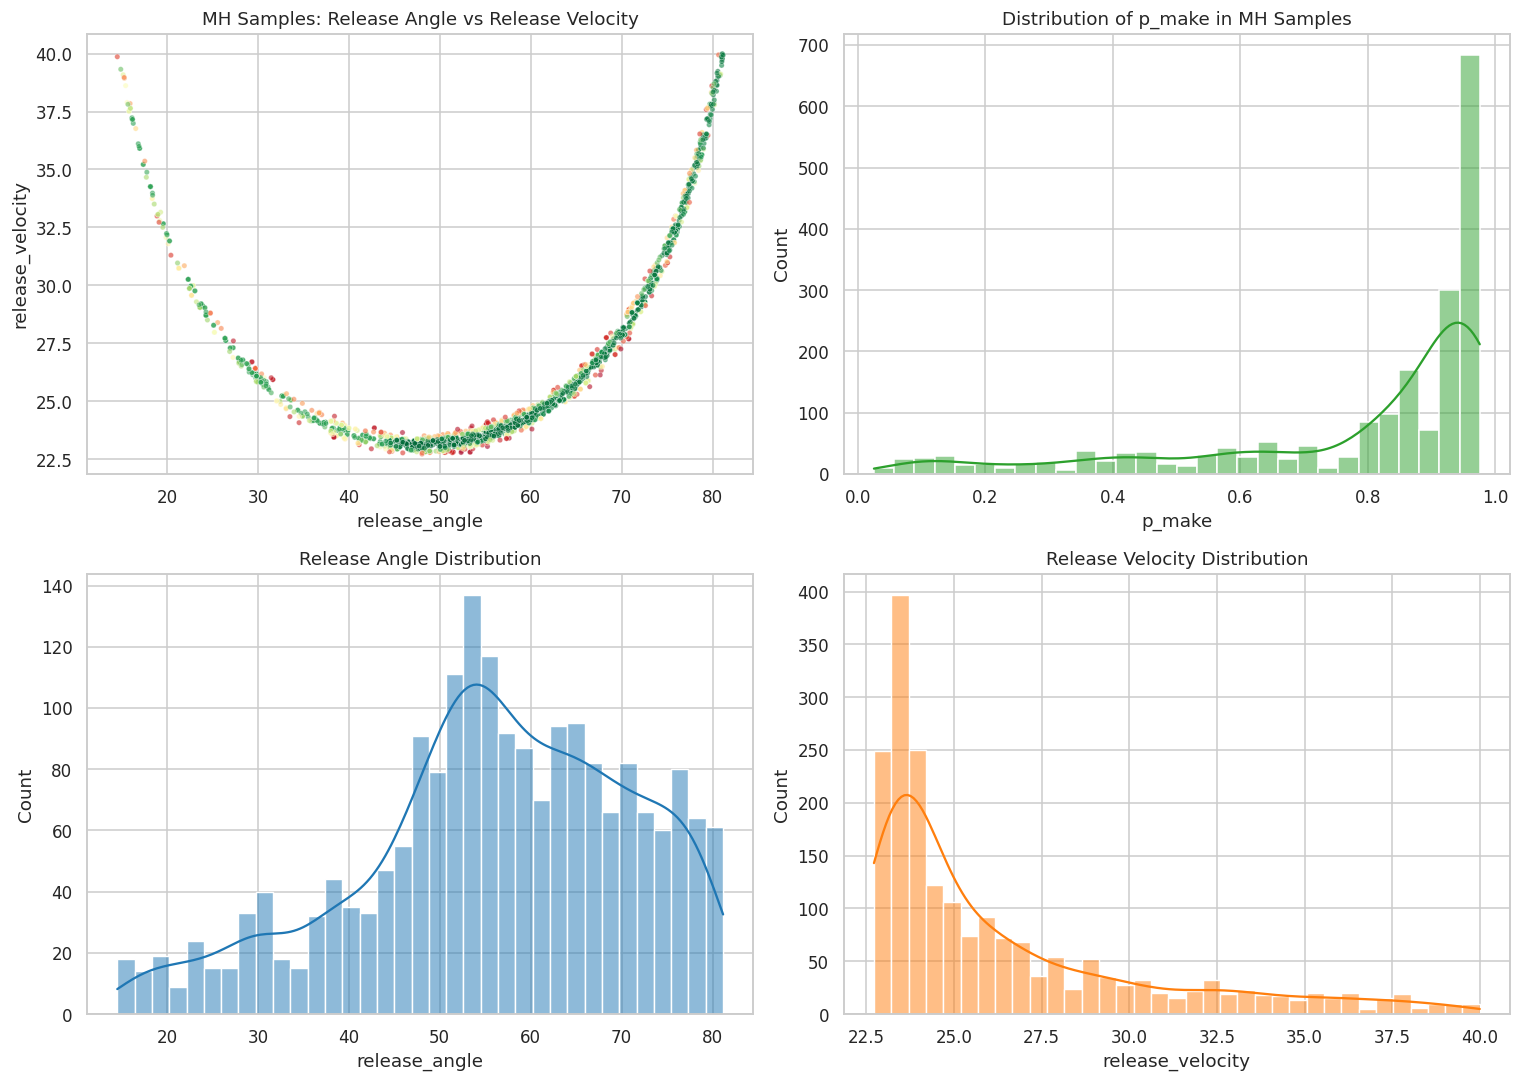

In [21]:
# -----------------------------
# Metropolis-Hastings sampling for release-angle / release-velocity
# with augmented left_right "kinetic" variable
# -----------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# User controls
MH_RELEASE_HEIGHT = 8.5
MH_RIM_HEIGHT = 10.0
MH_DIST_TO_RIM_CENTER = 15.0
MH_MIN_X_MARGIN = 0.75
MH_MIN_X_AT_RIM = MH_DIST_TO_RIM_CENTER - MH_MIN_X_MARGIN

# Augmented variable settings (HMC-like kinetic augmentation via left_right)
MH_LEFT_RIGHT_INIT = 0.0
MH_LEFT_RIGHT_RW_SD = 0.35
MH_LEFT_RIGHT_KINETIC_SD = 0.75
MH_PMAKE_ZERO_DEPTH_CUTOFF = 19.0
MH_LEFT_RIGHT_MIN = None
MH_LEFT_RIGHT_MAX = None

# Depth convention: front rim = 0, back rim = 18, center = 9
MH_RIM_DEPTH_FRONT = 0.0
MH_RIM_DEPTH_BACK = 18.0
MH_RIM_DEPTH_CENTER = 0.5 * (MH_RIM_DEPTH_FRONT + MH_RIM_DEPTH_BACK)

# Convert horizontal physics displacement into Ball_Depth units.
# If physics distance is feet and Ball_Depth is inches, use 12.0.
MH_DIST_TO_DEPTH_UNITS = 12.0

MH_G = 32.174                     # ft/s^2
MH_SPEED_TO_PHYS_UNITS = 1.0      # sampled speed units are already ft/s
MH_VEL_TO_MODEL_UNITS = 1.0       # model Ball_Velocity is also in ft/s

MH_N_STEPS = 25000
MH_BURN_IN = 5000
MH_THIN = 10
MH_SEED = 42

# Theta random-walk scale (degrees) for MH proposal centered at current theta.
MH_THETA_RW_SD = 2.5

# Kept for compatibility with downstream debug cells.
MH_PROP_SD_ANGLE = MH_THETA_RW_SD
MH_PROP_SD_SPEED = 0.8

# Optional support guard (user said not required)
MH_ENFORCE_FEATURE_SUPPORT = False
MH_MAX_ABS_DEPTH = 50.0

# Optional practical cap for sampled release speed (raw units, ft/s here)
MH_SPEED_CAP = 40.0

ANGLE_COL_CANDIDATES = ['Initial.Ball.Angle', 'Initial Ball Angle', 'Launch.Angle']
TOTAL_VEL_COL_CANDIDATES = ['Initial.Ball.Velocity', 'Initial Ball Velocity', 'Launch.Velocity']

def pick_col(candidates, columns):
    return next((c for c in candidates if c in columns), None)

# Kept for compatibility with downstream debug cells.
def reflect_to_bounds(value, low, high):
    if high <= low:
        return low
    x = value
    for _ in range(10):
        if x < low:
            x = low + (low - x)
        elif x > high:
            x = high - (x - high)
        else:
            break
    return min(max(x, low), high)

# Ensure model exists for p(make) lookups.
if 'clf' not in globals() or 'feature_cols' not in globals():
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.model_selection import train_test_split

    data_path_fallback = '../capstone2026v2.csv'
    data_path_use = DATA_PATH if 'DATA_PATH' in globals() else data_path_fallback
    df = pd.read_csv(data_path_use)

    depth_candidates = ['Ball_Depth', 'ball_depth', 'Depth', 'depth', 'Shot.Y.Pos', 'y', 'Y']
    depth_col = next((c for c in depth_candidates if c in df.columns), None)
    if depth_col is None:
        raise ValueError('Could not find depth column for model rebuild.')

    req = ['left_right', depth_col, 'Ball_to_Rim_Angle', 'Ball_Velocity', 'Made']
    missing = [c for c in req if c not in df.columns]
    if missing:
        raise ValueError('Missing required columns for model rebuild: ' + str(missing))

    df_model = df[req].copy().rename(columns={depth_col: 'Ball_Depth'})
    df_model['Made'] = df_model['Made'].astype(int)
    feature_cols = ['left_right', 'Ball_Depth', 'Ball_to_Rim_Angle', 'Ball_Velocity']
    df_model = df_model.dropna(subset=feature_cols + ['Made']).copy()

    X = df_model[feature_cols]
    y = df_model['Made']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    clf = RandomForestClassifier(n_estimators=500, max_depth=None, min_samples_leaf=10, random_state=42, n_jobs=1)
    clf.fit(X_train, y_train)

if 'df' not in globals():
    data_path_fallback = '../capstone2026v2.csv'
    data_path_use = DATA_PATH if 'DATA_PATH' in globals() else data_path_fallback
    df = pd.read_csv(data_path_use)

if 'df_model' not in globals():
    depth_candidates = ['Ball_Depth', 'ball_depth', 'Depth', 'depth', 'Shot.Y.Pos', 'y', 'Y']
    depth_col_tmp = next((c for c in depth_candidates if c in df.columns), None)
    if depth_col_tmp is None:
        raise ValueError('No depth column found to derive model-support bounds.')
    df_model = df[['left_right', depth_col_tmp, 'Ball_to_Rim_Angle', 'Ball_Velocity']].copy()
    df_model = df_model.rename(columns={depth_col_tmp: 'Ball_Depth'}).dropna()

# Avoid thread-exhaustion in long MH loops during predict_proba calls.
if hasattr(clf, 'set_params'):
    clf.set_params(n_jobs=1)

angle_col = pick_col(ANGLE_COL_CANDIDATES, df.columns)
speed_col = pick_col(TOTAL_VEL_COL_CANDIDATES, df.columns)
if angle_col is None or speed_col is None:
    raise ValueError('Missing release-angle or release-speed columns.')

obs = df[[angle_col, speed_col]].dropna().copy()
obs = obs[obs[speed_col].astype(float) > 0].copy()
if obs.empty:
    raise ValueError('No valid observed release-angle/release-speed rows.')

angle_min = float(obs[angle_col].min())
angle_max = float(obs[angle_col].max())
speed_min = float(obs[speed_col].min())
speed_max_obs = float(obs[speed_col].max())
speed_max = max(speed_max_obs, MH_SPEED_CAP)

bra_min, bra_max = float(df_model['Ball_to_Rim_Angle'].min()), float(df_model['Ball_to_Rim_Angle'].max())
vel_min, vel_max = float(df_model['Ball_Velocity'].min()), float(df_model['Ball_Velocity'].max())
depth_min, depth_max = float(df_model['Ball_Depth'].min()), float(df_model['Ball_Depth'].max())

lr_min_data = float(df_model['left_right'].min())
lr_max_data = float(df_model['left_right'].max())
MH_LEFT_RIGHT_MIN = lr_min_data if MH_LEFT_RIGHT_MIN is None else float(MH_LEFT_RIGHT_MIN)
MH_LEFT_RIGHT_MAX = lr_max_data if MH_LEFT_RIGHT_MAX is None else float(MH_LEFT_RIGHT_MAX)
if MH_LEFT_RIGHT_MIN >= MH_LEFT_RIGHT_MAX:
    raise ValueError('Invalid left_right bounds for augmented MH state.')

# --- Physical-constraint sampler requested by user ---
# Need theta such that tan(theta) > 2*z/x
z_req = MH_RIM_HEIGHT - MH_RELEASE_HEIGHT
x_req = MH_MIN_X_AT_RIM
tan_floor = (2.0 * z_req / x_req)

theta_lower_deg = np.degrees(np.arctan(tan_floor)) + 1e-6
theta_upper_deg = min(89.0, angle_max)
theta_lower_deg = max(theta_lower_deg, angle_min)

if theta_lower_deg >= theta_upper_deg:
    raise ValueError('No angle range satisfies tan(theta) > 2*z/x under current settings.')

def velocity_bounds_for_angle(angle_deg):
    th = np.deg2rad(angle_deg)
    s2 = np.sin(2.0 * th)
    c2 = np.cos(th) ** 2

    # Enforce user-specified angular feasibility condition
    if np.tan(th) <= tan_floor:
        return None

    term = x_req * np.tan(th) - z_req
    if term <= 0 or c2 <= 1e-12 or s2 <= 1e-12:
        return None

    # v_min = sqrt(g*x^2 / (2*cos^2(theta)*(x*tan(theta)-z)))
    v_min_phys = np.sqrt((MH_G * (x_req ** 2)) / (2.0 * c2 * term))
    # v_max = sqrt(2*g*x / sin(2*theta))
    v_max_phys = np.sqrt((2.0 * MH_G * x_req) / s2)

    v_min_raw = v_min_phys / MH_SPEED_TO_PHYS_UNITS
    v_max_raw = v_max_phys / MH_SPEED_TO_PHYS_UNITS

    lo = max(speed_min, v_min_raw)
    hi = min(speed_max, v_max_raw)

    if not (np.isfinite(lo) and np.isfinite(hi)):
        return None
    if lo >= hi:
        return None

    return float(lo), float(hi)

def sample_theta_speed_physical(rng, max_tries=5000):
    for _ in range(max_tries):
        ang = float(rng.uniform(theta_lower_deg, theta_upper_deg))
        bnds = velocity_bounds_for_angle(ang)
        if bnds is None:
            continue
        lo, hi = bnds
        spd = float(rng.uniform(lo, hi))
        return ang, spd, lo, hi
    return None, None, None, None

def _stdnorm_cdf(x):
    from scipy.stats import norm
    return float(norm.cdf(x))

def _log_truncnorm_pdf(x, mean, sd, low, high):
    if sd <= 0:
        return -np.inf
    if not (low <= x <= high):
        return -np.inf

    z = (x - mean) / sd
    z_low = (low - mean) / sd
    z_high = (high - mean) / sd
    norm_const = _stdnorm_cdf(z_high) - _stdnorm_cdf(z_low)
    if norm_const <= 1e-300:
        return -np.inf

    return float(-0.5 * z * z - 0.5 * np.log(2.0 * np.pi) - np.log(sd) - np.log(norm_const))

def sample_theta_speed_rw(cur_angle, rng, max_tries=5000):
    for _ in range(max_tries):
        prop_angle = float(rng.normal(cur_angle, MH_THETA_RW_SD))
        if not (theta_lower_deg <= prop_angle <= theta_upper_deg):
            continue

        bnds = velocity_bounds_for_angle(prop_angle)
        if bnds is None:
            continue

        lo, hi = bnds
        prop_speed = float(rng.uniform(lo, hi))
        return prop_angle, prop_speed, lo, hi

    return None, None, None, None

def log_q_theta_speed_rw(next_angle, next_speed, cur_angle):
    if not (theta_lower_deg <= next_angle <= theta_upper_deg):
        return -np.inf

    bnds = velocity_bounds_for_angle(next_angle)
    if bnds is None:
        return -np.inf
    lo, hi = bnds
    if not (lo <= next_speed <= hi):
        return -np.inf

    log_q_theta = _log_truncnorm_pdf(
        x=next_angle,
        mean=cur_angle,
        sd=MH_THETA_RW_SD,
        low=theta_lower_deg,
        high=theta_upper_deg,
    )
    if not np.isfinite(log_q_theta):
        return -np.inf

    v_w = hi - lo
    if v_w <= 0:
        return -np.inf

    return float(log_q_theta - np.log(v_w))

def sample_left_right_rw(cur_left_right, rng):
    prop_left_right = float(rng.normal(cur_left_right, MH_LEFT_RIGHT_RW_SD))
    if prop_left_right < MH_LEFT_RIGHT_MIN or prop_left_right > MH_LEFT_RIGHT_MAX:
        return None
    return prop_left_right

def log_q_left_right_rw(next_left_right, cur_left_right):
    return _log_truncnorm_pdf(
        x=next_left_right,
        mean=cur_left_right,
        sd=MH_LEFT_RIGHT_RW_SD,
        low=MH_LEFT_RIGHT_MIN,
        high=MH_LEFT_RIGHT_MAX,
    )

# --- Physics mapping to model features ---
def projectile_to_features(release_angle_deg, release_speed_raw):
    theta = np.deg2rad(release_angle_deg)
    speed_phys = release_speed_raw * MH_SPEED_TO_PHYS_UNITS
    vx0 = speed_phys * np.cos(theta)
    vz0 = speed_phys * np.sin(theta)

    if vx0 <= 1e-10:
        return None

    A = 0.5 * MH_G
    B = -vz0
    C = MH_RIM_HEIGHT - MH_RELEASE_HEIGHT
    disc = B * B - 4.0 * A * C
    if disc < 0:
        return None

    sqrt_disc = np.sqrt(disc)
    t1 = (-B - sqrt_disc) / (2.0 * A)
    t2 = (-B + sqrt_disc) / (2.0 * A)
    t_candidates = sorted([t for t in [t1, t2] if t > 0])
    if not t_candidates:
        return None

    # Use descending branch
    t_star = max(t_candidates)
    vz_star = vz0 - MH_G * t_star
    if vz_star >= 0:
        return None

    x_star = vx0 * t_star
    if x_star < MH_MIN_X_AT_RIM:
        return None

    depth_from_front = MH_RIM_DEPTH_CENTER + (x_star - MH_DIST_TO_RIM_CENTER) * MH_DIST_TO_DEPTH_UNITS

    t_peak = vz0 / MH_G
    x_peak = vx0 * t_peak
    if not (t_peak > 0 and x_peak > 0 and x_peak < MH_DIST_TO_RIM_CENTER):
        return None

    speed_star_raw_phys = float(np.sqrt(vx0 * vx0 + vz_star * vz_star))
    speed_star_model = speed_star_raw_phys * MH_VEL_TO_MODEL_UNITS
    rim_plane_angle = float(np.degrees(np.arctan2(abs(vz_star), abs(vx0))))

    if MH_ENFORCE_FEATURE_SUPPORT:
        if not (depth_min <= depth_from_front <= depth_max):
            return None
        if not (bra_min <= rim_plane_angle <= bra_max):
            return None
        if not (vel_min <= speed_star_model <= vel_max):
            return None
    else:
        if abs(depth_from_front) > MH_MAX_ABS_DEPTH:
            return None

    return {
        'depth': float(depth_from_front),
        'ball_to_rim_angle': rim_plane_angle,
        'ball_velocity_model': speed_star_model,
        'ball_velocity_raw': speed_star_raw_phys,
        'time_at_rim_height': float(t_star),
        'x_at_rim_height': float(x_star),
        'x_peak': float(x_peak),
        'vz_at_rim_height': float(vz_star),
    }

def log_target_from_state(release_angle_deg, release_speed, left_right):
    feats = projectile_to_features(release_angle_deg, release_speed)
    if feats is None:
        return -np.inf, None

    row = pd.DataFrame({
        'left_right': [left_right],
        'Ball_Depth': [feats['depth']],
        'Ball_to_Rim_Angle': [feats['ball_to_rim_angle']],
        'Ball_Velocity': [feats['ball_velocity_model']],
    })
    if feats['depth'] >= MH_PMAKE_ZERO_DEPTH_CUTOFF:
        p_make = 0.0
    else:
        p_make = float(clf.predict_proba(row[feature_cols])[:, 1][0])
    if p_make <= 1e-12:
        return -np.inf, None

    # HMC-like augmentation: penalize extreme sampled left_right via kinetic energy.
    kinetic_energy = 0.5 * (left_right / MH_LEFT_RIGHT_KINETIC_SD) ** 2
    log_target = float(np.log(p_make) - kinetic_energy)

    out = {
        'release_angle': float(release_angle_deg),
        'release_velocity': float(release_speed),
        'left_right': float(left_right),
        'kinetic_energy': float(kinetic_energy),
        'depth': float(feats['depth']),
        'ball_to_rim_angle': float(feats['ball_to_rim_angle']),
        'ball_velocity_model': float(feats['ball_velocity_model']),
        'ball_velocity_raw': float(feats['ball_velocity_raw']),
        'time_at_rim_height': float(feats['time_at_rim_height']),
        'x_at_rim_height': float(feats['x_at_rim_height']),
        'x_peak': float(feats['x_peak']),
        'vz_at_rim_height': float(feats['vz_at_rim_height']),
        'p_make': float(p_make),
        'log_target': log_target,
    }
    return out['log_target'], out

rng = np.random.default_rng(MH_SEED)
cur_angle, cur_speed, init_speed_lb, init_speed_ub = sample_theta_speed_physical(rng, max_tries=50000)
if cur_angle is None:
    raise ValueError('No feasible physical sample found under current constraints.')

cur_left_right = float(np.clip(MH_LEFT_RIGHT_INIT, MH_LEFT_RIGHT_MIN, MH_LEFT_RIGHT_MAX))
cur_logt, cur_rec = log_target_from_state(cur_angle, cur_speed, cur_left_right)
if cur_rec is None:
    cur_rec = {
        'release_angle': float(cur_angle),
        'release_velocity': float(cur_speed),
        'left_right': float(cur_left_right),
        'kinetic_energy': np.nan,
        'depth': np.nan,
        'ball_to_rim_angle': np.nan,
        'ball_velocity_model': np.nan,
        'ball_velocity_raw': np.nan,
        'time_at_rim_height': np.nan,
        'x_at_rim_height': np.nan,
        'x_peak': np.nan,
        'vz_at_rim_height': np.nan,
        'p_make': 0.0,
        'log_target': float(-np.inf),
    }

samples = []
n_accept = 0
n_valid_prop = 0

for step in range(MH_N_STEPS):
    prop_angle, prop_speed, _, _ = sample_theta_speed_rw(cur_angle, rng, max_tries=5000)
    prop_left_right = sample_left_right_rw(cur_left_right, rng)

    if prop_angle is None or prop_left_right is None:
        prop_logt, prop_rec = -np.inf, None
        log_q_fwd = -np.inf
    else:
        prop_logt, prop_rec = log_target_from_state(prop_angle, prop_speed, prop_left_right)
        log_q_fwd = (
            log_q_theta_speed_rw(prop_angle, prop_speed, cur_angle)
            + log_q_left_right_rw(prop_left_right, cur_left_right)
        )

    if np.isfinite(prop_logt):
        n_valid_prop += 1

    accept = False
    if np.isfinite(prop_logt) and np.isfinite(log_q_fwd):
        log_q_rev = (
            log_q_theta_speed_rw(cur_angle, cur_speed, prop_angle)
            + log_q_left_right_rw(cur_left_right, prop_left_right)
        )
        log_alpha = prop_logt - cur_logt + log_q_rev - log_q_fwd
        if np.log(rng.uniform(0.0, 1.0)) < min(0.0, log_alpha):
            accept = True

    if accept:
        cur_angle = prop_angle
        cur_speed = prop_speed
        cur_left_right = prop_left_right
        cur_logt = prop_logt
        cur_rec = prop_rec
        n_accept += 1

    if step >= MH_BURN_IN and ((step - MH_BURN_IN) % MH_THIN == 0):
        rec = cur_rec.copy()
        rec['step'] = int(step)
        samples.append(rec)

mh_samples = pd.DataFrame(samples)
accept_rate = n_accept / MH_N_STEPS
valid_prop_rate = n_valid_prop / MH_N_STEPS

print('MH sampling complete.')
print('  steps              =', MH_N_STEPS)
print('  burn-in            =', MH_BURN_IN)
print('  thin               =', MH_THIN)
print('  retained samples   =', len(mh_samples))
print('  accept rate        =', round(float(accept_rate), 4))
print('  valid proposal rate=', round(float(valid_prop_rate), 4))
print()
print('Fixed controls:')
print('  release_height =', MH_RELEASE_HEIGHT, '| rim_height =', MH_RIM_HEIGHT, '| dist_to_rim_center =', MH_DIST_TO_RIM_CENTER)
print('  x requirement =', x_req, '| z requirement =', z_req)
print('  theta condition: tan(theta) > 2*z/x =', round(float(tan_floor), 6))
print('  theta range used (deg):', (round(theta_lower_deg, 4), round(theta_upper_deg, 4)))
print('  initial velocity bounds from formula =', (round(float(init_speed_lb), 4), round(float(init_speed_ub), 4)))
print('  theta RW sd (deg) =', MH_THETA_RW_SD)
print('  left_right RW sd  =', MH_LEFT_RIGHT_RW_SD)
print('  left_right kinetic sd =', MH_LEFT_RIGHT_KINETIC_SD)
print('  left_right bounds =', (round(float(MH_LEFT_RIGHT_MIN), 4), round(float(MH_LEFT_RIGHT_MAX), 4)))
print('  feature-support gating enabled =', MH_ENFORCE_FEATURE_SUPPORT)
print('  speed cap =', MH_SPEED_CAP)
print('  initial state valid =', bool(np.isfinite(cur_logt)))

if mh_samples.empty:
    print()
    print('No retained samples. Increase steps or relax constraints/proposal scales.')
else:
    mh_high = mh_samples[(mh_samples['p_make'] >= 0.80) & (mh_samples['p_make'] <= 1.00)].copy()
    mh_samples_high_prob = mh_high.copy()

    print()
    print('Posterior-like sample summary (all retained states):')
    show_cols = ['release_angle', 'release_velocity', 'left_right', 'kinetic_energy', 'depth', 'ball_to_rim_angle', 'ball_velocity_model', 'p_make']
    print(mh_samples[show_cols].describe().loc[['mean', 'std', 'min', '25%', '50%', '75%', 'max']].round(4).to_string())

    print()
    print('Target-window samples with 0.80 <= p_make <= 1.00:', len(mh_high))
    if not mh_high.empty:
        print('Range summary in target window:')
        print(mh_high[show_cols].describe().loc[['min', '25%', '50%', '75%', 'max']].round(4).to_string())

        best_min_v = mh_high.sort_values(['release_velocity', 'p_make'], ascending=[True, False]).head(1).copy()
        mh_min_velocity_solution = best_min_v.copy()
        print()
        print('Minimum release-velocity sample in target window:')
        print(best_min_v[['release_angle', 'release_velocity', 'left_right', 'kinetic_energy', 'depth', 'ball_to_rim_angle', 'ball_velocity_model', 'p_make']].round(4).to_string(index=False))
    else:
        mh_min_velocity_solution = pd.DataFrame()

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    sns.scatterplot(data=mh_samples, x='release_angle', y='release_velocity', hue='p_make',
                    palette='RdYlGn', s=12, alpha=0.6, ax=axes[0, 0], legend=False)
    axes[0, 0].set_title('MH Samples: Release Angle vs Release Velocity')

    sns.histplot(mh_samples['p_make'], bins=30, kde=True, color='tab:green', ax=axes[0, 1])
    axes[0, 1].set_title('Distribution of p_make in MH Samples')
    axes[0, 1].set_xlabel('p_make')

    sns.histplot(mh_samples['release_angle'], bins=35, kde=True, color='tab:blue', ax=axes[1, 0])
    axes[1, 0].set_title('Release Angle Distribution')
    axes[1, 0].set_xlabel('release_angle')

    sns.histplot(mh_samples['release_velocity'], bins=35, kde=True, color='tab:orange', ax=axes[1, 1])
    axes[1, 1].set_title('Release Velocity Distribution')
    axes[1, 1].set_xlabel('release_velocity')

    plt.tight_layout()
    plt.show()

MH sampling:   0%|          | 0/25000 [00:00<?, ?step/s]

MH sampling complete.
  steps              = 25000
  burn-in            = 5000
  thin               = 10
  retained samples   = 2000
  accept rate        = 0.0949
  valid proposal rate= 0.1749

Physical sampler settings:
  x requirement = 14.25 | z requirement = 1.5
  theta condition: tan(theta) > 0.210526
  theta range used (deg): (np.float64(11.8887), 86.81)
  theta RW sd (deg) = 2.5
  left_right RW sd  = 0.35
  left_right kinetic sd = 0.75
  left_right bounds = (-88.02, 32.3)

Posterior-like sample summary (all retained states):
      release_angle  release_velocity  left_right  kinetic_energy    depth  ball_to_rim_angle  ball_velocity_model  p_make
mean        55.8526           26.4262     -0.1325          0.4890   9.9170            51.6981              24.4868  0.7804
std         15.2625            4.0776      0.7300          0.6707   3.6483            18.0885               4.3413  0.2474
min         14.5387           22.7241     -1.8368          0.0000   0.0078             2.8222

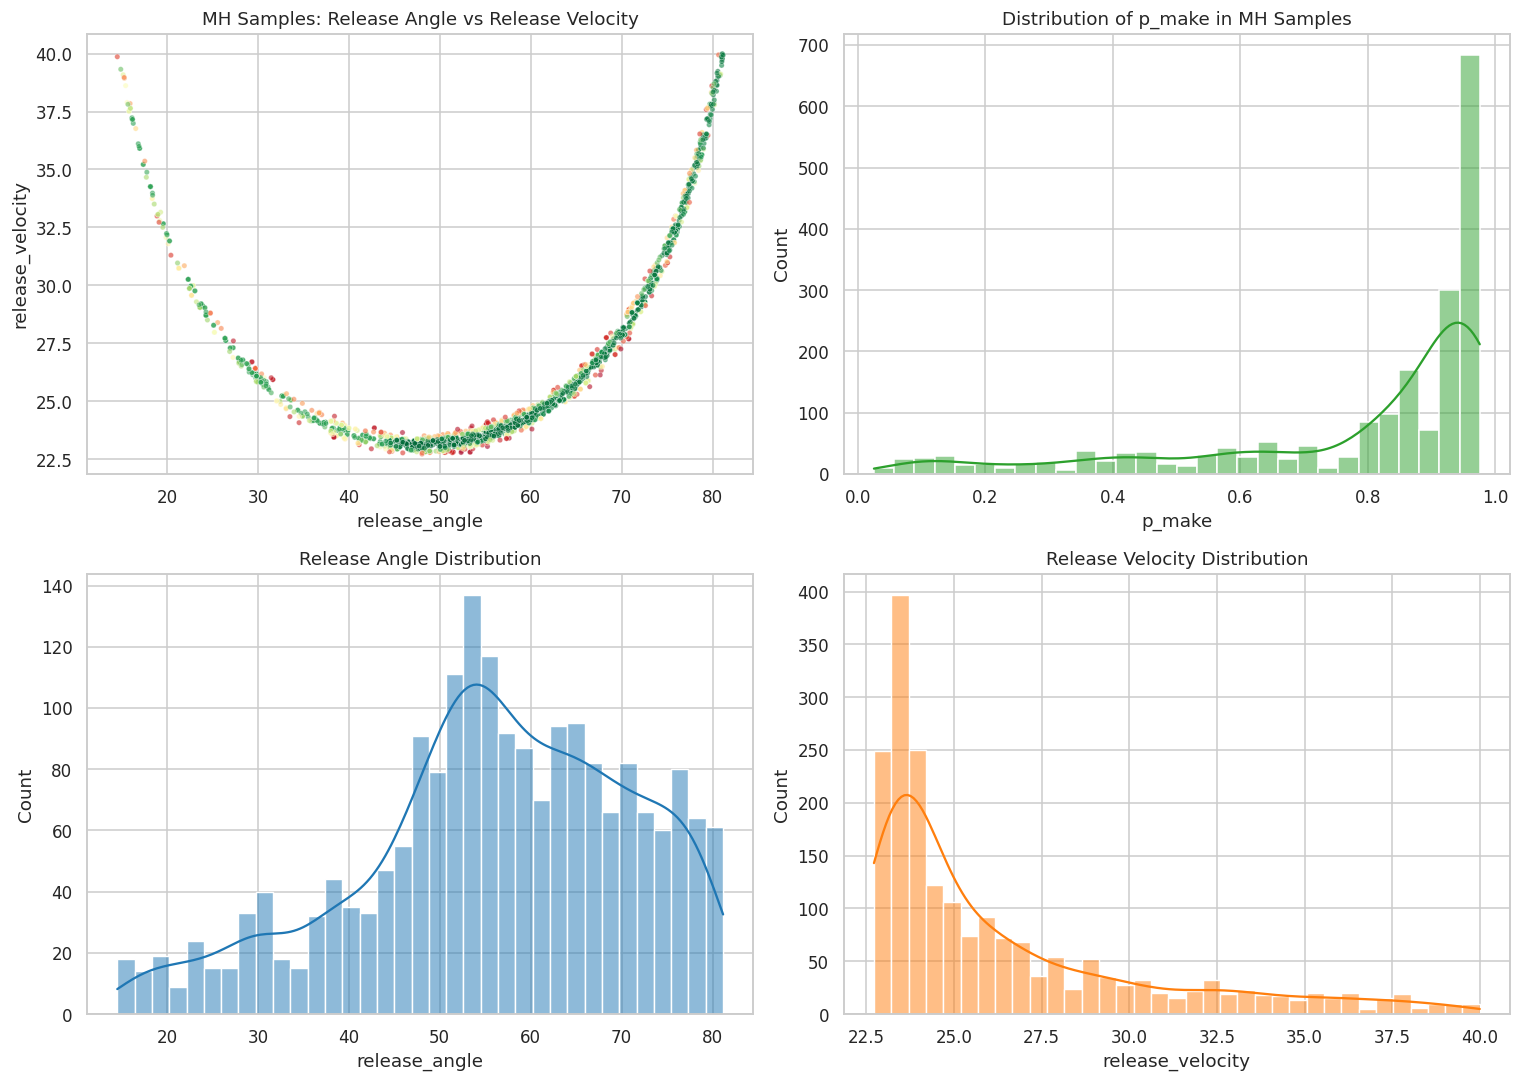

In [22]:
# -----------------------------
# Metropolis-Hastings sampling with progress logging
# (theta random-walk in constrained space + augmented left_right kinetic variable)
# -----------------------------

from tqdm.auto import tqdm

rng = np.random.default_rng(MH_SEED)

cur_angle, cur_speed, _, _ = sample_theta_speed_physical(rng, max_tries=50000)
if cur_angle is None:
    raise ValueError('No feasible physical sample found under current constraints.')

cur_left_right = float(np.clip(MH_LEFT_RIGHT_INIT, MH_LEFT_RIGHT_MIN, MH_LEFT_RIGHT_MAX))
cur_logt, cur_rec = log_target_from_state(cur_angle, cur_speed, cur_left_right)
if cur_rec is None:
    cur_rec = {
        'release_angle': float(cur_angle),
        'release_velocity': float(cur_speed),
        'left_right': float(cur_left_right),
        'kinetic_energy': np.nan,
        'depth': np.nan,
        'ball_to_rim_angle': np.nan,
        'ball_velocity_model': np.nan,
        'ball_velocity_raw': np.nan,
        'time_at_rim_height': np.nan,
        'x_at_rim_height': np.nan,
        'x_peak': np.nan,
        'vz_at_rim_height': np.nan,
        'p_make': 0.0,
        'log_target': float(-np.inf),
    }

samples = []
n_accept = 0
n_valid_prop = 0

for step in tqdm(range(MH_N_STEPS), desc='MH sampling', unit='step'):
    prop_angle, prop_speed, _, _ = sample_theta_speed_rw(cur_angle, rng, max_tries=5000)
    prop_left_right = sample_left_right_rw(cur_left_right, rng)

    if prop_angle is None or prop_left_right is None:
        prop_logt, prop_rec = -np.inf, None
        log_q_fwd = -np.inf
    else:
        prop_logt, prop_rec = log_target_from_state(prop_angle, prop_speed, prop_left_right)
        log_q_fwd = (
            log_q_theta_speed_rw(prop_angle, prop_speed, cur_angle)
            + log_q_left_right_rw(prop_left_right, cur_left_right)
        )

    if np.isfinite(prop_logt):
        n_valid_prop += 1

    accept = False
    if np.isfinite(prop_logt) and np.isfinite(log_q_fwd):
        log_q_rev = (
            log_q_theta_speed_rw(cur_angle, cur_speed, prop_angle)
            + log_q_left_right_rw(cur_left_right, prop_left_right)
        )
        log_alpha = prop_logt - cur_logt + log_q_rev - log_q_fwd
        if np.log(rng.uniform(0.0, 1.0)) < min(0.0, log_alpha):
            accept = True

    if accept:
        cur_angle = prop_angle
        cur_speed = prop_speed
        cur_left_right = prop_left_right
        cur_logt = prop_logt
        cur_rec = prop_rec
        n_accept += 1

    if step >= MH_BURN_IN and ((step - MH_BURN_IN) % MH_THIN == 0):
        rec = cur_rec.copy()
        rec['step'] = int(step)
        samples.append(rec)

mh_samples = pd.DataFrame(samples)
accept_rate = n_accept / MH_N_STEPS
valid_prop_rate = n_valid_prop / MH_N_STEPS

print('MH sampling complete.')
print('  steps              =', MH_N_STEPS)
print('  burn-in            =', MH_BURN_IN)
print('  thin               =', MH_THIN)
print('  retained samples   =', len(mh_samples))
print('  accept rate        =', round(float(accept_rate), 4))
print('  valid proposal rate=', round(float(valid_prop_rate), 4))
print()
print('Physical sampler settings:')
print('  x requirement =', x_req, '| z requirement =', z_req)
print('  theta condition: tan(theta) >', round(float(tan_floor), 6))
print('  theta range used (deg):', (round(theta_lower_deg, 4), round(theta_upper_deg, 4)))
print('  theta RW sd (deg) =', MH_THETA_RW_SD)
print('  left_right RW sd  =', MH_LEFT_RIGHT_RW_SD)
print('  left_right kinetic sd =', MH_LEFT_RIGHT_KINETIC_SD)
print('  left_right bounds =', (round(float(MH_LEFT_RIGHT_MIN), 4), round(float(MH_LEFT_RIGHT_MAX), 4)))

if mh_samples.empty:
    print()
    print('No retained samples. Increase MH_N_STEPS or relax constraints.')
else:
    mh_high = mh_samples[(mh_samples['p_make'] >= 0.80) & (mh_samples['p_make'] <= 1.00)].copy()
    mh_samples_high_prob = mh_high.copy()

    print()
    print('Posterior-like sample summary (all retained states):')
    show_cols = ['release_angle', 'release_velocity', 'left_right', 'kinetic_energy', 'depth', 'ball_to_rim_angle', 'ball_velocity_model', 'p_make']
    print(mh_samples[show_cols].describe().loc[['mean', 'std', 'min', '25%', '50%', '75%', 'max']].round(4).to_string())

    print()
    print('Target-window samples with 0.80 <= p_make <= 1.00:', len(mh_high))
    if not mh_high.empty:
        print('Range summary in target window:')
        print(mh_high[show_cols].describe().loc[['min', '25%', '50%', '75%', 'max']].round(4).to_string())

        best_min_v = mh_high.sort_values(['release_velocity', 'p_make'], ascending=[True, False]).head(1).copy()
        mh_min_velocity_solution = best_min_v.copy()
        print()
        print('Minimum release-velocity sample in target window:')
        print(best_min_v[['release_angle', 'release_velocity', 'left_right', 'kinetic_energy', 'depth', 'ball_to_rim_angle', 'ball_velocity_model', 'p_make']].round(4).to_string(index=False))
    else:
        mh_min_velocity_solution = pd.DataFrame()

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    sns.scatterplot(data=mh_samples, x='release_angle', y='release_velocity', hue='p_make',
                    palette='RdYlGn', s=12, alpha=0.6, ax=axes[0, 0], legend=False)
    axes[0, 0].set_title('MH Samples: Release Angle vs Release Velocity')

    sns.histplot(mh_samples['p_make'], bins=30, kde=True, color='tab:green', ax=axes[0, 1])
    axes[0, 1].set_title('Distribution of p_make in MH Samples')
    axes[0, 1].set_xlabel('p_make')

    sns.histplot(mh_samples['release_angle'], bins=35, kde=True, color='tab:blue', ax=axes[1, 0])
    axes[1, 0].set_title('Release Angle Distribution')
    axes[1, 0].set_xlabel('release_angle')

    sns.histplot(mh_samples['release_velocity'], bins=35, kde=True, color='tab:orange', ax=axes[1, 1])
    axes[1, 1].set_title('Release Velocity Distribution')
    axes[1, 1].set_xlabel('release_velocity')

    plt.tight_layout()
    plt.show()

Player context: Player 163 | Catch and Shoot
Valid shots available: 1,904
Selected shot index: 0
Distance source: release XY
Distance units inferred: meters -> feet
Release-height units inferred: meters -> feet
Empirical speed units inferred: m/s -> ft/s

Selected shot (raw + converted):
      Name       Shot.Type  Initial.Ball.Angle  Initial.Ball.Velocity  BallZRelease  context_distance_ft  context_release_height_ft  empirical_speed_fts
Player 163 Catch and Shoot             44.3363                 8.1185        2.7442              21.8268                     9.0032              26.6353

Single-shot view only: the selected row seeds the chain, while the sampler geometry uses the selected shot release height and distance.
  x requirement = 21.0768 | z requirement = 0.9968
  theta condition: tan(theta) > 2*z/x = 0.094583
  theta range used (deg): (38.8552, 59.9328)
  angle range from data = (38.8552, 59.9328)
  speed range from data = (16.1075, 40.0)
  empirical release_height = 9.0032 

MH sampling:   0%|          | 0/25000 [00:00<?, ?step/s]


MH sampling complete.
  steps              = 25000
  burn-in            = 5000
  thin               = 10
  retained samples   = 2000
  accept rate        = 0.052
  valid proposal rate= 0.0907

Posterior-like sample summary (all retained states):
      release_angle  release_velocity  left_right  kinetic_energy    depth  ball_to_rim_angle  ball_velocity_model  p_make
mean        50.3755           27.6212     -0.0851          0.4091   9.8302            48.1458              26.4342  0.7974
std          5.9399            0.5411      0.6732          0.5195   3.7027             6.4944               0.5650  0.2430
min         39.1125           26.6795     -1.9987          0.0000   0.1004            35.7910              25.4491  0.0366
25%         45.4389           27.2062     -0.5470          0.0359   6.8446            42.7237              26.0008  0.7025
50%         50.3496           27.4565     -0.0559          0.1903   9.8848            48.1012              26.2625  0.9194
75%         55.

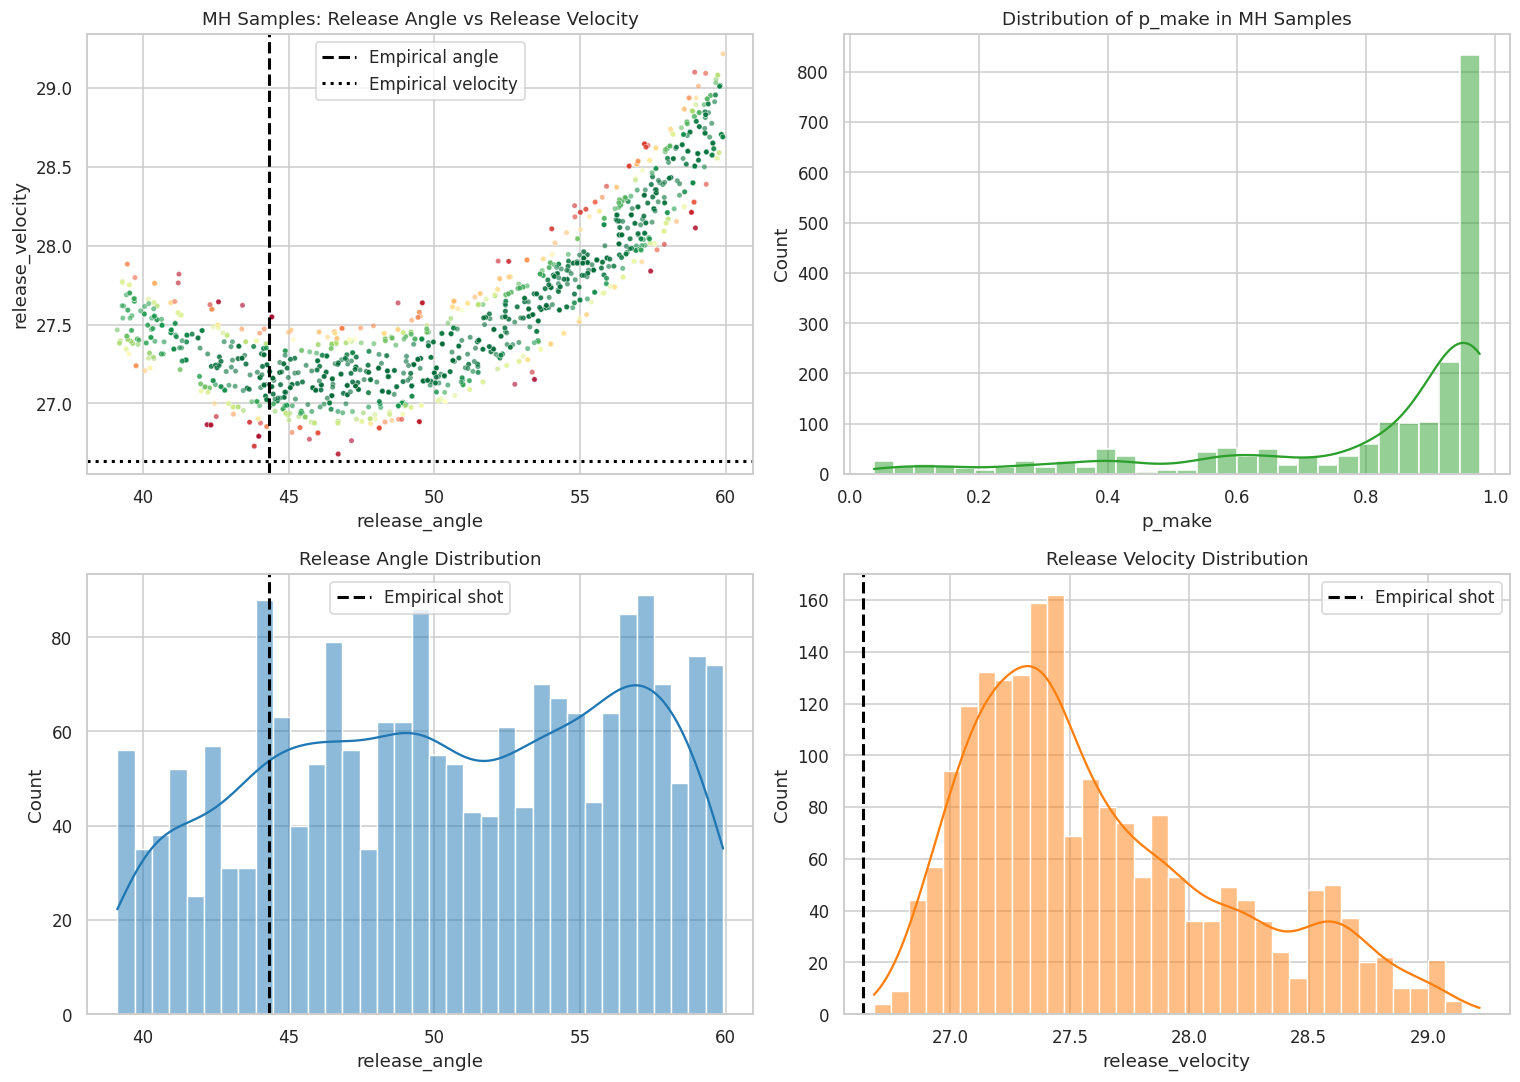

In [28]:
# Single-shot Metropolis-Hastings sampling for one player attempt
# Example target: Player 163, Catch and Shoot.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

TARGET_PLAYER = 'Player 163'
TARGET_SHOT_TYPE = 'Catch and Shoot'
SHOT_INDEX = 0
RNG_SEED_LOCAL = 163

player_candidates = ['Name', 'Player', 'player', 'PlayerName']
shot_type_candidates = ['Shot.Type', 'Shot Type', 'ShotType']
distance_candidates = ['Shot.Distance', 'Shot Distance', 'Shot_Distance']
angle_candidates = ['Initial.Ball.Angle', 'Initial Ball Angle', 'Launch.Angle']
speed_candidates = ['Initial.Ball.Velocity', 'Initial Ball Velocity', 'Launch.Velocity']
release_z_candidates = ['BallZRelease', 'Ball.Z.Release', 'Ball_Z_Release', 'BallZAtRelease']
release_x_candidates = ['BallXRelease', 'Ball.X.Release', 'Ball_X_Release']
release_y_candidates = ['BallYRelease', 'Ball.Y.Release', 'Ball_Y_Release']
left_right_candidates = ['left_right', 'LeftRight', 'Ball_Left_Right']


def pick_col_local(cands, cols):
    return next((c for c in cands if c in cols), None)



def infer_linear_unit_to_ft(series):
    s = pd.Series(series).dropna().astype(float)
    if s.empty:
        return 1.0, 'feet (default)'
    med = float(s.median())
    q95 = float(s.quantile(0.95))

    if med > 40 or q95 > 80:
        return 1.0 / 12.0, 'inches -> feet'
    if med >= 10 or q95 >= 18:
        return 1.0, 'feet'
    return 3.28084, 'meters -> feet'



def infer_speed_unit_to_fts(series):
    s = pd.Series(series).dropna().astype(float)
    if s.empty:
        return 1.0, 'ft/s (default)'
    q95 = float(s.quantile(0.95))

    if q95 <= 15:
        return 3.28084, 'm/s -> ft/s'
    if q95 > 55:
        return 1.46667, 'mph -> ft/s'
    return 1.0, 'ft/s'


player_col_local = pick_col_local(player_candidates, df.columns)
shot_type_col_local = pick_col_local(shot_type_candidates, df.columns)
dist_col_local = pick_col_local(distance_candidates, df.columns)
angle_col_local = pick_col_local(angle_candidates, df.columns)
speed_col_local = pick_col_local(speed_candidates, df.columns)
release_z_col_local = pick_col_local(release_z_candidates, df.columns)
release_x_col_local = pick_col_local(release_x_candidates, df.columns)
release_y_col_local = pick_col_local(release_y_candidates, df.columns)
left_right_col_local = pick_col_local(left_right_candidates, df.columns)

required_core = [player_col_local, shot_type_col_local, angle_col_local, speed_col_local, release_z_col_local]
if any(c is None for c in required_core):
    missing = []
    if player_col_local is None:
        missing.append('player')
    if shot_type_col_local is None:
        missing.append('shot_type')
    if angle_col_local is None:
        missing.append('release_angle')
    if speed_col_local is None:
        missing.append('release_speed')
    if release_z_col_local is None:
        missing.append('release_height (BallZRelease)')
    raise ValueError('Missing required columns: ' + ', '.join(missing))

subset = df[
    (df[player_col_local].astype(str) == TARGET_PLAYER)
    & (df[shot_type_col_local].astype(str) == TARGET_SHOT_TYPE)
].copy()

subset = subset.dropna(subset=[angle_col_local, speed_col_local, release_z_col_local])
subset = subset[subset[speed_col_local] > 0].copy()

if subset.empty:
    raise ValueError(f'No valid rows for {TARGET_PLAYER} with {TARGET_SHOT_TYPE}.')

# Prefer geometric release location distance if available; fallback to Shot.Distance.
if release_x_col_local is not None and release_y_col_local is not None:
    subset = subset.dropna(subset=[release_x_col_local, release_y_col_local]).copy()
    subset['context_distance_raw'] = np.sqrt(subset[release_x_col_local] ** 2 + subset[release_y_col_local] ** 2)
    distance_source = 'release XY'
elif dist_col_local is not None:
    subset = subset.dropna(subset=[dist_col_local]).copy()
    subset['context_distance_raw'] = subset[dist_col_local].astype(float)
    distance_source = str(dist_col_local)
else:
    raise ValueError('No distance source found (need release XY or Shot.Distance).')

subset = subset[subset['context_distance_raw'] > 0].copy()
if subset.empty:
    raise ValueError('No positive distance rows remain after filtering.')

subset['context_release_height_raw'] = subset[release_z_col_local].astype(float)
subset['empirical_speed_raw'] = subset[speed_col_local].astype(float)

if left_right_col_local is not None:
    subset['context_left_right'] = subset[left_right_col_local].astype(float)
else:
    subset['context_left_right'] = 0.0

subset = subset.dropna(subset=['context_distance_raw', 'context_release_height_raw', 'empirical_speed_raw', 'context_left_right']).copy()
if subset.empty:
    raise ValueError('No valid context rows remain after NA filtering.')

# Infer units from empirical distributions and convert to shared physics units (feet, ft/s).
dist_to_ft_factor, dist_unit_note = infer_linear_unit_to_ft(subset['context_distance_raw'])
height_to_ft_factor, height_unit_note = infer_linear_unit_to_ft(subset['context_release_height_raw'])
speed_to_fts_factor, speed_unit_note = infer_speed_unit_to_fts(subset['empirical_speed_raw'])

subset['context_distance_ft'] = subset['context_distance_raw'] * dist_to_ft_factor
subset['context_release_height_ft'] = subset['context_release_height_raw'] * height_to_ft_factor
subset['empirical_speed_fts'] = subset['empirical_speed_raw'] * speed_to_fts_factor

subset = subset[(subset['context_distance_ft'] > 0) & (subset['context_release_height_ft'] > 0)].copy()
if subset.empty:
    raise ValueError('No valid positive distance/release-height rows after unit conversion.')

if not (0 <= SHOT_INDEX < len(subset)):
    raise IndexError(f'SHOT_INDEX={SHOT_INDEX} is out of range for {len(subset)} valid shots.')

selected_shot = subset.iloc[[SHOT_INDEX]].copy()
selected_angle_deg = float(selected_shot[angle_col_local].iloc[0])
selected_speed_fts = float(selected_shot['empirical_speed_fts'].iloc[0])
selected_left_right = float(selected_shot['context_left_right'].iloc[0])
selected_distance_ft = float(selected_shot['context_distance_ft'].iloc[0])
selected_release_height_ft = float(selected_shot['context_release_height_ft'].iloc[0])

rim_height_local = float(globals().get('MH_RIM_HEIGHT', 10.0))
gravity_local = float(globals().get('MH_G', 32.174))
left_right_ke_sd_local = float(globals().get('MH_LEFT_RIGHT_KINETIC_SD', 0.75))
depth_cutoff_local = float(globals().get('MH_PMAKE_ZERO_DEPTH_CUTOFF', 19.0))
rim_depth_center_local = float(globals().get('MH_RIM_DEPTH_CENTER', 9.0))

# Restore the original notebook-wide MCMC geometry, but anchored to the selected shot.
MH_RELEASE_HEIGHT = selected_release_height_ft
MH_DIST_TO_RIM_CENTER = selected_distance_ft
MH_MIN_X_MARGIN = 0.75
MH_MIN_X_AT_RIM = MH_DIST_TO_RIM_CENTER - MH_MIN_X_MARGIN

x_req = MH_MIN_X_AT_RIM
z_req = MH_RIM_HEIGHT - MH_RELEASE_HEIGHT
tan_floor = (2.0 * z_req / x_req)

all_obs_angle = df[angle_col_local].dropna().astype(float)
angle_min = float(all_obs_angle.quantile(0.01))
angle_max = float(min(89.0, all_obs_angle.quantile(0.99)))

speed_obs_fts = df[speed_col_local].dropna().astype(float) * speed_to_fts_factor
speed_obs_fts = speed_obs_fts[speed_obs_fts > 0]
if speed_obs_fts.empty:
    raise ValueError('No positive speed observations after conversion.')
speed_min = float(speed_obs_fts.quantile(0.01))
speed_max = float(max(40.0, speed_obs_fts.quantile(0.99)))

theta_lower_deg = np.degrees(np.arctan(tan_floor)) + 1e-6
theta_upper_deg = min(89.0, angle_max)
theta_lower_deg = max(theta_lower_deg, angle_min)
if theta_lower_deg >= theta_upper_deg:
    raise ValueError(
        'No valid theta range in the current sampler state. '
        f'Lower={theta_lower_deg:.4f}, upper={theta_upper_deg:.4f}, '
        f'x_req={x_req:.4f}, z_req={z_req:.4f}'
    )

print(f'Player context: {TARGET_PLAYER} | {TARGET_SHOT_TYPE}')
print(f'Valid shots available: {len(subset):,}')
print(f'Selected shot index: {SHOT_INDEX}')
print(f'Distance source: {distance_source}')
print(f'Distance units inferred: {dist_unit_note}')
print(f'Release-height units inferred: {height_unit_note}')
print(f'Empirical speed units inferred: {speed_unit_note}')
print()
print('Selected shot (raw + converted):')
print(selected_shot[[player_col_local, shot_type_col_local, angle_col_local, speed_col_local, release_z_col_local, 'context_distance_ft', 'context_release_height_ft', 'empirical_speed_fts']].round(4).to_string(index=False))
print()
print('Single-shot view only: the selected row seeds the chain, while the sampler geometry uses the selected shot release height and distance.')
print('  x requirement =', round(float(x_req), 4), '| z requirement =', round(float(z_req), 4))
print('  theta condition: tan(theta) > 2*z/x =', round(float(tan_floor), 6))
print('  theta range used (deg):', (round(theta_lower_deg, 4), round(theta_upper_deg, 4)))
print('  angle range from data =', (round(angle_min, 4), round(angle_max, 4)))
print('  speed range from data =', (round(speed_min, 4), round(speed_max, 4)))
print('  empirical release_height =', round(float(selected_release_height_ft), 4), '| sampler release_height =', round(float(MH_RELEASE_HEIGHT), 4), '| sampler distance =', round(float(MH_DIST_TO_RIM_CENTER), 4), '| rim_height =', round(float(rim_height_local), 4))

rng = np.random.default_rng(RNG_SEED_LOCAL)
cur_angle = selected_angle_deg
cur_speed = selected_speed_fts
cur_left_right = selected_left_right
cur_logt, cur_rec = log_target_from_state(cur_angle, cur_speed, cur_left_right)
if cur_rec is None or not np.isfinite(cur_logt):
    cur_angle, cur_speed, _, _ = sample_theta_speed_physical(rng, max_tries=50000)
    if cur_angle is None:
        raise ValueError('No feasible physical sample found under current constraints for the selected shot.')
    cur_left_right = float(np.clip(cur_left_right, MH_LEFT_RIGHT_MIN, MH_LEFT_RIGHT_MAX))
    cur_logt, cur_rec = log_target_from_state(cur_angle, cur_speed, cur_left_right)

if cur_rec is None:
    cur_rec = {
        'release_angle': float(cur_angle),
        'release_velocity': float(cur_speed),
        'left_right': float(cur_left_right),
        'kinetic_energy': np.nan,
        'depth': np.nan,
        'ball_to_rim_angle': np.nan,
        'ball_velocity_model': np.nan,
        'ball_velocity_raw': np.nan,
        'time_at_rim_height': np.nan,
        'x_at_rim_height': np.nan,
        'x_peak': np.nan,
        'vz_at_rim_height': np.nan,
        'p_make': 0.0,
        'log_target': float(-np.inf),
    }

samples = []
n_accept = 0
n_valid_prop = 0

for step in tqdm(range(MH_N_STEPS), desc='MH sampling', unit='step'):
    prop_angle, prop_speed, _, _ = sample_theta_speed_rw(cur_angle, rng, max_tries=5000)
    prop_left_right = sample_left_right_rw(cur_left_right, rng)

    if prop_angle is None or prop_left_right is None:
        prop_logt, prop_rec = -np.inf, None
        log_q_fwd = -np.inf
    else:
        prop_logt, prop_rec = log_target_from_state(prop_angle, prop_speed, prop_left_right)
        log_q_fwd = (
            log_q_theta_speed_rw(prop_angle, prop_speed, cur_angle)
            + log_q_left_right_rw(prop_left_right, cur_left_right)
        )

    if np.isfinite(prop_logt):
        n_valid_prop += 1

    accept = False
    if np.isfinite(prop_logt) and np.isfinite(log_q_fwd):
        log_q_rev = (
            log_q_theta_speed_rw(cur_angle, cur_speed, prop_angle)
            + log_q_left_right_rw(cur_left_right, prop_left_right)
        )
        log_alpha = prop_logt - cur_logt + log_q_rev - log_q_fwd
        if np.log(rng.uniform(0.0, 1.0)) < min(0.0, log_alpha):
            accept = True

    if accept:
        cur_angle = prop_angle
        cur_speed = prop_speed
        cur_left_right = prop_left_right
        cur_logt = prop_logt
        cur_rec = prop_rec
        n_accept += 1

    if step >= MH_BURN_IN and ((step - MH_BURN_IN) % MH_THIN == 0):
        rec = cur_rec.copy()
        rec['step'] = int(step)
        samples.append(rec)

mh_one_shot_samples = pd.DataFrame(samples)
accept_rate = n_accept / MH_N_STEPS
valid_prop_rate = n_valid_prop / MH_N_STEPS

print()
print('MH sampling complete.')
print('  steps              =', MH_N_STEPS)
print('  burn-in            =', MH_BURN_IN)
print('  thin               =', MH_THIN)
print('  retained samples   =', len(mh_one_shot_samples))
print('  accept rate        =', round(float(accept_rate), 4))
print('  valid proposal rate=', round(float(valid_prop_rate), 4))

if mh_one_shot_samples.empty:
    print()
    print('No retained samples. Increase MH_N_STEPS or relax constraints.')
else:
    mh_one_shot_high_prob = mh_one_shot_samples[(mh_one_shot_samples['p_make'] >= 0.80) & (mh_one_shot_samples['p_make'] <= 1.00)].copy()
    mh_one_shot_min_velocity_solution = pd.DataFrame()

    print()
    print('Posterior-like sample summary (all retained states):')
    show_cols = ['release_angle', 'release_velocity', 'left_right', 'kinetic_energy', 'depth', 'ball_to_rim_angle', 'ball_velocity_model', 'p_make']
    print(mh_one_shot_samples[show_cols].describe().loc[['mean', 'std', 'min', '25%', '50%', '75%', 'max']].round(4).to_string())

    print()
    print('Target-window samples with 0.80 <= p_make <= 1.00:', len(mh_one_shot_high_prob))
    if not mh_one_shot_high_prob.empty:
        print('Range summary in target window:')
        print(mh_one_shot_high_prob[show_cols].describe().loc[['min', '25%', '50%', '75%', 'max']].round(4).to_string())

        best_min_v = mh_one_shot_high_prob.sort_values(['release_velocity', 'p_make'], ascending=[True, False]).head(1).copy()
        mh_one_shot_min_velocity_solution = best_min_v.copy()
        print()
        print('Minimum release-velocity sample in target window:')
        print(best_min_v[['release_angle', 'release_velocity', 'left_right', 'kinetic_energy', 'depth', 'ball_to_rim_angle', 'ball_velocity_model', 'p_make']].round(4).to_string(index=False))

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    sns.scatterplot(data=mh_one_shot_samples, x='release_angle', y='release_velocity', hue='p_make',
                    palette='RdYlGn', s=12, alpha=0.6, ax=axes[0, 0], legend=False)
    axes[0, 0].axvline(selected_angle_deg, color='black', linestyle='--', linewidth=2, label='Empirical angle')
    axes[0, 0].axhline(selected_speed_fts, color='black', linestyle=':', linewidth=2, label='Empirical velocity')
    axes[0, 0].set_title('MH Samples: Release Angle vs Release Velocity')
    axes[0, 0].legend()

    sns.histplot(mh_one_shot_samples['p_make'], bins=30, kde=True, color='tab:green', ax=axes[0, 1])
    axes[0, 1].set_title('Distribution of p_make in MH Samples')
    axes[0, 1].set_xlabel('p_make')

    sns.histplot(mh_one_shot_samples['release_angle'], bins=35, kde=True, color='tab:blue', ax=axes[1, 0])
    axes[1, 0].set_title('Release Angle Distribution')
    axes[1, 0].set_xlabel('release_angle')
    axes[1, 0].axvline(selected_angle_deg, color='black', linestyle='--', linewidth=2, label='Empirical shot')
    axes[1, 0].legend()

    sns.histplot(mh_one_shot_samples['release_velocity'], bins=35, kde=True, color='tab:orange', ax=axes[1, 1])
    axes[1, 1].set_title('Release Velocity Distribution')
    axes[1, 1].set_xlabel('release_velocity')
    axes[1, 1].axvline(selected_speed_fts, color='black', linestyle='--', linewidth=2, label='Empirical shot')
    axes[1, 1].legend()

    plt.tight_layout()
    plt.show()


In [ ]:
# Player-level deviation from optimal release angle using a continuous per-shot sampler
# Definitions used here:
# - Shot-level optimal release angle: posterior median of accepted release-angle samples for that shot.
# - Player-bucket reference angle: median of shot-level optimal release angles within
#   (player, shot_type_bucket, distance_bucket).
# - Velocity margin for error: accepted release-velocity CI width (q95 - q05),
#   summarized at player-bucket level.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

N_ANGLE_SAMPLES_CONT = 512
PROB_MIN_OFF = 0.0
PROB_MAX_OFF = float(globals().get('TARGET_PROB_MAX', 1.00))
CONT_SAMPLER_SEED = 20260415

player_candidates = ['Name', 'Player', 'player', 'PlayerName']
shot_type_candidates = ['Shot.Type', 'Shot Type', 'ShotType']
distance_candidates = ['Shot.Distance', 'Shot Distance', 'Shot_Distance']
angle_candidates = ['Initial.Ball.Angle', 'Initial Ball Angle', 'Launch.Angle']
speed_candidates = ['Initial.Ball.Velocity', 'Initial Ball Velocity', 'Launch.Velocity']
release_z_candidates = ['BallZRelease', 'Ball.Z.Release', 'Ball_Z_Release', 'BallZAtRelease']
release_x_candidates = ['BallXRelease', 'Ball.X.Release', 'Ball_X_Release']
release_y_candidates = ['BallYRelease', 'Ball.Y.Release', 'Ball_Y_Release']
left_right_candidates = ['left_right', 'LeftRight', 'Ball_Left_Right']


def pick_col_local(cands, cols):
    return next((c for c in cands if c in cols), None)



def infer_linear_unit_to_ft(series):
    s = pd.Series(series).dropna().astype(float)
    if s.empty:
        return 1.0, 'feet (default)'
    med = float(s.median())
    q95 = float(s.quantile(0.95))
    if med > 40 or q95 > 80:
        return 1.0 / 12.0, 'inches -> feet'
    if med >= 10 or q95 >= 18:
        return 1.0, 'feet'
    return 3.28084, 'meters -> feet'



def infer_speed_unit_to_fts(series):
    s = pd.Series(series).dropna().astype(float)
    if s.empty:
        return 1.0, 'ft/s (default)'
    q95 = float(s.quantile(0.95))
    if q95 <= 15:
        return 3.28084, 'm/s -> ft/s'
    if q95 > 55:
        return 1.46667, 'mph -> ft/s'
    return 1.0, 'ft/s'



def bucket_shot_type(v):
    s = str(v).strip().lower()
    if 'catch' in s:
        return 'Catch and Shoot'
    if 'dribble' in s or 'off' in s:
        return 'Off the Dribble'
    return 'Other'


player_col_local = pick_col_local(player_candidates, df.columns)
shot_type_col_local = pick_col_local(shot_type_candidates, df.columns)
dist_col_local = pick_col_local(distance_candidates, df.columns)
angle_col_local = pick_col_local(angle_candidates, df.columns)
speed_col_local = pick_col_local(speed_candidates, df.columns)
release_z_col_local = pick_col_local(release_z_candidates, df.columns)
release_x_col_local = pick_col_local(release_x_candidates, df.columns)
release_y_col_local = pick_col_local(release_y_candidates, df.columns)
left_right_col_local = pick_col_local(left_right_candidates, df.columns)

required_core = [player_col_local, shot_type_col_local, angle_col_local, speed_col_local, release_z_col_local]
if any(c is None for c in required_core):
    missing = []
    if player_col_local is None:
        missing.append('player')
    if shot_type_col_local is None:
        missing.append('shot_type')
    if angle_col_local is None:
        missing.append('release_angle')
    if speed_col_local is None:
        missing.append('release_speed')
    if release_z_col_local is None:
        missing.append('release_height (BallZRelease)')
    raise ValueError('Missing required columns: ' + ', '.join(missing))

work = df.copy()
work = work.dropna(subset=[player_col_local, shot_type_col_local, angle_col_local, speed_col_local, release_z_col_local]).copy()
work = work[work[speed_col_local].astype(float) > 0].copy()

if release_x_col_local is not None and release_y_col_local is not None:
    work = work.dropna(subset=[release_x_col_local, release_y_col_local]).copy()
    work['context_distance_raw'] = np.sqrt(work[release_x_col_local].astype(float) ** 2 + work[release_y_col_local].astype(float) ** 2)
    distance_source = 'release XY'
elif dist_col_local is not None:
    work = work.dropna(subset=[dist_col_local]).copy()
    work['context_distance_raw'] = work[dist_col_local].astype(float)
    distance_source = str(dist_col_local)
else:
    raise ValueError('No distance source found (need release XY or Shot.Distance).')

work = work[work['context_distance_raw'] > 0].copy()
work['context_release_height_raw'] = work[release_z_col_local].astype(float)
work['empirical_speed_raw'] = work[speed_col_local].astype(float)
work['empirical_angle_deg'] = work[angle_col_local].astype(float)

if left_right_col_local is not None:
    work['context_left_right'] = work[left_right_col_local].astype(float)
else:
    work['context_left_right'] = 0.0

work = work.dropna(subset=['context_distance_raw', 'context_release_height_raw', 'empirical_speed_raw', 'empirical_angle_deg', 'context_left_right']).copy()

if work.empty:
    raise ValueError('No valid rows remain after preprocessing.')

work['shot_type_bucket'] = work[shot_type_col_local].map(bucket_shot_type)
work = work[work['shot_type_bucket'].isin(['Catch and Shoot', 'Off the Dribble'])].copy()
if work.empty:
    raise ValueError('No Catch and Shoot / Off the Dribble rows remain after bucketing.')

# Unit inference on full working set.
dist_to_ft_factor, dist_unit_note = infer_linear_unit_to_ft(work['context_distance_raw'])
height_to_ft_factor, height_unit_note = infer_linear_unit_to_ft(work['context_release_height_raw'])
speed_to_fts_factor, speed_unit_note = infer_speed_unit_to_fts(work['empirical_speed_raw'])

work['context_distance_ft'] = work['context_distance_raw'] * dist_to_ft_factor
work['context_release_height_ft'] = work['context_release_height_raw'] * height_to_ft_factor
work['empirical_speed_fts'] = work['empirical_speed_raw'] * speed_to_fts_factor
work = work[(work['context_distance_ft'] > 0) & (work['context_release_height_ft'] > 0)].copy()

if work.empty:
    raise ValueError('No valid rows remain after unit conversion.')

# Distance buckets in feet.
dist_bins = [0, 10, 15, 20, 25, 30, 35, np.inf]
dist_labels = ['0-10', '10-15', '15-20', '20-25', '25-30', '30-35', '35+']
work['distance_bucket'] = pd.cut(
    work['context_distance_ft'], bins=dist_bins, labels=dist_labels, include_lowest=True, right=False
)

# Global support bounds.
all_obs_angle = work['empirical_angle_deg']
angle_min = float(all_obs_angle.quantile(0.01))
angle_max = float(min(89.0, all_obs_angle.quantile(0.99)))

speed_obs_fts = work['empirical_speed_fts']
speed_min = float(speed_obs_fts.quantile(0.01))
speed_max = float(max(40.0, speed_obs_fts.quantile(0.99)))

rim_height_local = float(globals().get('MH_RIM_HEIGHT', 10.0))
gravity_local = float(globals().get('MH_G', 32.174))
left_right_ke_sd_local = float(globals().get('MH_LEFT_RIGHT_KINETIC_SD', 0.75))
rim_depth_center_local = float(globals().get('MH_RIM_DEPTH_CENTER', 9.0))

rng = np.random.default_rng(CONT_SAMPLER_SEED)
shot_records = []
for _, r in tqdm(work.iterrows(), total=len(work), desc='Per-shot continuous posterior pass', unit='shot'):
    d = float(r['context_distance_ft'])
    h0 = float(r['context_release_height_ft'])
    lr = float(r['context_left_right'])
    empirical_angle = float(r['empirical_angle_deg'])
    z_req = rim_height_local - h0

    # Enforce theta > arctan(2*z/x), then sample continuously in that feasible angle support.
    theta_floor_deg = float(np.degrees(np.arctan2(2.0 * z_req, d)))
    local_angle_min = max(angle_min, theta_floor_deg + 1e-6)
    local_angle_max = angle_max
    if local_angle_min >= local_angle_max:
        continue

    ang_prop = rng.uniform(local_angle_min, local_angle_max, size=N_ANGLE_SAMPLES_CONT)
    th = np.deg2rad(ang_prop)
    cos_th = np.cos(th)
    tan_th = np.tan(th)
    term = d * tan_th - z_req

    valid = (cos_th > 1e-8) & (term > 1e-8)
    if not np.any(valid):
        continue

    # Conditional on angle, implied speed must lie within global empirical support.
    spd = np.full_like(ang_prop, np.nan, dtype=float)
    spd[valid] = np.sqrt((gravity_local * d * d) / (2.0 * (cos_th[valid] ** 2) * term[valid]))

    valid &= np.isfinite(spd)
    valid &= (spd >= speed_min) & (spd <= speed_max)
    if not np.any(valid):
        continue

    valid_idx = np.where(valid)[0]
    spd_v = spd[valid_idx]
    ang_v = ang_prop[valid_idx]

    vx0_v = spd_v * np.cos(np.deg2rad(ang_v))
    t_rim_v = d / vx0_v
    vz_rim_v = spd_v * np.sin(np.deg2rad(ang_v)) - gravity_local * t_rim_v

    bra_v = np.degrees(np.arctan2(np.abs(vz_rim_v), np.abs(vx0_v)))
    vel_model_v = np.sqrt(vx0_v * vx0_v + vz_rim_v * vz_rim_v)
    depth_v = np.full(len(ang_v), rim_depth_center_local, dtype=float)

    row_model = pd.DataFrame({
        'left_right': np.full(len(ang_v), lr, dtype=float),
        'Ball_Depth': depth_v,
        'Ball_to_Rim_Angle': bra_v,
        'Ball_Velocity': vel_model_v,
    })

    p_make_v = clf.predict_proba(row_model[feature_cols])[:, 1]
    make_mask = (p_make_v >= PROB_MIN_OFF) & (p_make_v <= PROB_MAX_OFF)
    if not np.any(make_mask):
        continue

    ang_acc = ang_v[make_mask]
    spd_acc = spd_v[make_mask]

    ang_med = float(np.median(ang_acc))
    ang_q05 = float(np.quantile(ang_acc, 0.05))
    ang_q95 = float(np.quantile(ang_acc, 0.95))
    vel_q05 = float(np.quantile(spd_acc, 0.05))
    vel_q95 = float(np.quantile(spd_acc, 0.95))
    vel_ci_width = float(vel_q95 - vel_q05)

    kinetic_energy = 0.5 * (lr / left_right_ke_sd_local) ** 2
    shot_records.append({
        'player': str(r[player_col_local]),
        'shot_type_bucket': str(r['shot_type_bucket']),
        'distance_bucket': r['distance_bucket'],
        'distance_ft': d,
        'context_release_height_ft': h0,
        'empirical_angle_deg': empirical_angle,
        'empirical_speed_fts': float(r['empirical_speed_fts']),
        'accepted_n': int(len(ang_acc)),
        'optimal_release_angle_deg': ang_med,
        'accepted_angle_q05_deg': ang_q05,
        'accepted_angle_q95_deg': ang_q95,
        'accepted_velocity_q05_fts': vel_q05,
        'accepted_velocity_q95_fts': vel_q95,
        'accepted_velocity_ci_width_90_fts': vel_ci_width,
        'theta_floor_deg': theta_floor_deg,
        'left_right': lr,
        'kinetic_energy': kinetic_energy,
    })

shot_post_df = pd.DataFrame(shot_records)
if shot_post_df.empty:
    raise ValueError('No shots produced accepted posterior samples.')

# Shot-level off (varies by shot).
shot_post_df['off_signed_deg'] = shot_post_df['empirical_angle_deg'] - shot_post_df['optimal_release_angle_deg']
shot_post_df['off_abs_deg'] = shot_post_df['off_signed_deg'].abs()

# Player-bucket reference angle and margin summaries.
player_bucket_opt = (
    shot_post_df.groupby(['player', 'shot_type_bucket', 'distance_bucket'], observed=False)
    .agg(
        n_shots=('optimal_release_angle_deg', 'size'),
        player_bucket_optimal_release_angle_deg=('optimal_release_angle_deg', 'median'),
        player_bucket_optimal_angle_q25_deg=('optimal_release_angle_deg', lambda x: x.quantile(0.25)),
        player_bucket_optimal_angle_q75_deg=('optimal_release_angle_deg', lambda x: x.quantile(0.75)),
        velocity_margin_ci90_fts=('accepted_velocity_ci_width_90_fts', 'median'),
        velocity_margin_ci90_q25_fts=('accepted_velocity_ci_width_90_fts', lambda x: x.quantile(0.25)),
        velocity_margin_ci90_q75_fts=('accepted_velocity_ci_width_90_fts', lambda x: x.quantile(0.75)),
    )
    .reset_index()
)

off_by_player_shot = shot_post_df.merge(
    player_bucket_opt[['player', 'shot_type_bucket', 'distance_bucket', 'player_bucket_optimal_release_angle_deg']],
    on=['player', 'shot_type_bucket', 'distance_bucket'],
    how='left',
)
off_by_player_shot['off_signed_from_player_bucket_deg'] = (
    off_by_player_shot['empirical_angle_deg'] - off_by_player_shot['player_bucket_optimal_release_angle_deg']
)
off_by_player_shot['off_abs_from_player_bucket_deg'] = off_by_player_shot['off_signed_from_player_bucket_deg'].abs()

player_bucket_summary = (
    off_by_player_shot.groupby(['player', 'shot_type_bucket', 'distance_bucket'], observed=False)
    .agg(
        n_shots=('off_abs_deg', 'size'),
        mean_off_abs_deg=('off_abs_deg', 'mean'),
        median_off_abs_deg=('off_abs_deg', 'median'),
        std_off_abs_deg=('off_abs_deg', 'std'),
        q25_off_abs_deg=('off_abs_deg', lambda x: x.quantile(0.25)),
        q75_off_abs_deg=('off_abs_deg', lambda x: x.quantile(0.75)),
        mean_off_signed_deg=('off_signed_deg', 'mean'),
        median_off_signed_deg=('off_signed_deg', 'median'),
        mean_off_abs_from_player_bucket_deg=('off_abs_from_player_bucket_deg', 'mean'),
        median_off_abs_from_player_bucket_deg=('off_abs_from_player_bucket_deg', 'median'),
    )
    .reset_index()
    .merge(
        player_bucket_opt,
        on=['player', 'shot_type_bucket', 'distance_bucket', 'n_shots'],
        how='left',
    )
)

overall_bucket_summary = (
    off_by_player_shot.groupby(['shot_type_bucket', 'distance_bucket'], observed=False)
    .agg(
        n_shots=('off_abs_deg', 'size'),
        mean_off_abs_deg=('off_abs_deg', 'mean'),
        median_off_abs_deg=('off_abs_deg', 'median'),
        mean_off_signed_deg=('off_signed_deg', 'mean'),
        median_off_signed_deg=('off_signed_deg', 'median'),
    )
    .reset_index()
)

print('Player-level optimal-angle deviation complete (continuous sampler).')
print('Rows evaluated:', f'{len(work):,}')
print('Rows with accepted posterior samples:', f'{len(shot_post_df):,}')
print('Unique player-buckets:', f'{len(player_bucket_opt):,}')
print('Distance source:', distance_source)
print('Distance units inferred:', dist_unit_note)
print('Release-height units inferred:', height_unit_note)
print('Empirical speed units inferred:', speed_unit_note)
print('Accepted posterior uses all accepted samples (no make-probability filtering).')
print('Continuous sampler angle proposals per shot:', N_ANGLE_SAMPLES_CONT)
print()
print('Definition note: optimal_release_angle_deg varies by shot (accepted-angle posterior median).')
print('Definition note: player_bucket_optimal_release_angle_deg is the player-bucket median reference.')
print('Definition note: velocity_margin_ci90_fts is median accepted velocity CI width (q95 - q05).')
print()

# Show player-bucket table for groups with at least 10 shots.
disp = player_bucket_summary[player_bucket_summary['n_shots'] >= 10].copy()
display(disp.sort_values(['shot_type_bucket', 'distance_bucket', 'mean_off_abs_deg']).round(4).head(200))

print('Overall bucket summary:')
display(overall_bucket_summary.round(4))

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

sns.boxplot(
    data=off_by_player_shot,
    x='distance_bucket',
    y='off_abs_deg',
    hue='shot_type_bucket',
    ax=axes[0],
)
axes[0].set_title('Shot-Level |Empirical - Optimal| Angle Deviation (Continuous Sampler)')
axes[0].set_ylabel('|empirical - shot-optimal| (deg)')
axes[0].set_xlabel('Distance bucket (ft)')
axes[0].legend(title='Shot type')

sns.boxplot(
    data=off_by_player_shot,
    x='distance_bucket',
    y='off_signed_deg',
    hue='shot_type_bucket',
    ax=axes[1],
)
axes[1].axhline(0.0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Shot-Level Signed Angle Deviation (Continuous Sampler)')
axes[1].set_ylabel('empirical - shot-optimal (deg)')
axes[1].set_xlabel('Distance bucket (ft)')
axes[1].legend(title='Shot type')

plt.tight_layout()
plt.show()

# Margin-for-error vs off-amount (player-bucket level).
plot_df = player_bucket_summary[player_bucket_summary['n_shots'] >= 10].copy()
if not plot_df.empty:
    plt.figure(figsize=(12, 7))
    sns.scatterplot(
        data=plot_df,
        x='velocity_margin_ci90_fts',
        y='mean_off_abs_deg',
        hue='shot_type_bucket',
        size='n_shots',
        alpha=0.75,
    )
    plt.title('Player-Bucket Mean |Off| vs Velocity Margin-for-Error')
    plt.xlabel('Velocity margin-for-error CI90 width (ft/s)')
    plt.ylabel('Mean |empirical - shot-optimal| angle (deg)')
    plt.tight_layout()
    plt.show()

player_optimal_angle_shot_level = off_by_player_shot
player_optimal_angle_summary = player_bucket_summary
player_optimal_angle_overall_summary = overall_bucket_summary


Per-shot continuous posterior pass:   0%|          | 0/25865 [00:00<?, ?shot/s]